# EDA Consolidado Situacion 1

Construccion, auditoria y exploracion del panel espacio-temporal GeoVision-CLIP Cali 2020-2024.

Este notebook consolida la evidencia de Situacion 1: fuentes, columnas, tiempos, nulos, distribuciones, cobertura espacial, cobertura temporal, visualizaciones y panel final integrado.

## 00. Introduccion Y Alcance

Objetivo: demostrar que el proyecto construyo un panel analitico longitudinal para Cali/Yumbo integrando Sentinel-5P, Sentinel-2, MODIS MAIAC, ERA5-Land y DAGMA/SISAIRE.

Conceptos clave:

- Datos crudos/cache: datos mas cercanos a la descarga original o almacenamiento intermedio pesado.
- Features: variables derivadas/agregadas desde las fuentes originales.
- Panel final: tabla integrada por estacion y hora.
- Panel model_safe: version del panel sin columnas directas Sentinel-5P de contaminantes para reducir leakage.

## 01. Configuracion, Rutas Y Utilidades

Aqui se importaran librerias, se definiran rutas y se crearan carpetas de salida.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path('/workspace/geovision-cali-hf')
OUT = ROOT / 'Entrega_Final' / 'Situacion1'
FIG_DIR = OUT / 'figuras'
TAB_DIR = OUT / 'tablas'
MANIFEST_DIR = OUT / 'evidencias' / 'manifests'
for path in [FIG_DIR, TAB_DIR, MANIFEST_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RUTAS = {
    'panel_final_model_safe': ROOT / 'panel_tabular/panel_geovision_cali_station_hourly_2020_2024_model_safe.parquet',
    'dagma_largo': ROOT / 'data/DAGMA/processed/panel_dagma_sisaire_largo_2020_2024.parquet',
    'dagma_ancho': ROOT / 'data/DAGMA/processed/panel_dagma_sisaire_ancho_2020_2024.parquet',
    'era5_land': ROOT / 'data/era5_modis/era5_land_cali_hourly_2020_2024.parquet',
    'modis_maiac': ROOT / 'data/era5_modis/modis_maiac_aod_cali_daily_full_2020_2024.parquet',
    'sentinel5p': ROOT / 'data/sentinel2-sentinel-5p/parquet/sentinel5p_panel_cali_2020_2024.parquet',
    'sentinel5p_coverage': ROOT / 'data/sentinel2-sentinel-5p/csv/sentinel5p_daily_coverage.csv',
    'sentinel2_coverage': ROOT / 'data/sentinel2-sentinel-5p/csv/sentinel2_daily_coverage_corregido.csv',
    'sentinel2_raw_scene_manifest': ROOT / 'data/sentinel2_pipeline_reproducibilidad/manifests_s2_12band_raw/scene_manifest.jsonl',
    'sentinel2_zarr_manifest': ROOT / 'data/sentinel2_pipeline_reproducibilidad/manifests_s2_12band_zarr/scene_zarr_manifest.jsonl',
    'sentinel2_zarr_s3_cache': ROOT / 'outputs/situacion3/rubrica/12_sentinel2_zarr_cache_cali_bbox',
    'sentinel2_pipeline_zarr': ROOT / 'panel_zarr/sentinel2',
    'manifest_panel': ROOT / 'manifest/manifest_panel_geovision_cali_2020_2024.json',
    'manifest_sentinel2': ROOT / 'manifest/sentinel2/manifest_sentinel2_panel_cali_2020_2024.json',
    'manifest_sentinel5p': ROOT / 'manifest/sentinel5p/manifest_sentinel5p_panel_cali_2020_2024.json',
    'manifest_dagma': ROOT / 'manifest/dagma/manifest_dagma_sisaire_2020_2024.json',
    'manifest_era5_modis': ROOT / 'manifest/era5/manifest_era5_modis.json',
}

RUTAS

{'panel_final_model_safe': PosixPath('/workspace/geovision-cali-hf/panel_tabular/panel_geovision_cali_station_hourly_2020_2024_model_safe.parquet'),
 'dagma_largo': PosixPath('/workspace/geovision-cali-hf/data/DAGMA/processed/panel_dagma_sisaire_largo_2020_2024.parquet'),
 'dagma_ancho': PosixPath('/workspace/geovision-cali-hf/data/DAGMA/processed/panel_dagma_sisaire_ancho_2020_2024.parquet'),
 'era5_land': PosixPath('/workspace/geovision-cali-hf/data/era5_modis/era5_land_cali_hourly_2020_2024.parquet'),
 'modis_maiac': PosixPath('/workspace/geovision-cali-hf/data/era5_modis/modis_maiac_aod_cali_daily_full_2020_2024.parquet'),
 'sentinel5p': PosixPath('/workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/parquet/sentinel5p_panel_cali_2020_2024.parquet'),
 'sentinel5p_coverage': PosixPath('/workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/csv/sentinel5p_daily_coverage.csv'),
 'sentinel2_coverage': PosixPath('/workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/csv/sentinel2_

## 02. Inventario De Archivos, Peso Y Trazabilidad

Se revisaran archivos disponibles, pesos locales, manifests, hashes MD5 y diferencia entre cache/datos pesados y panel final comprimido.

In [2]:
def size_bytes(path: Path) -> int:
    if not path.exists():
        return 0
    if path.is_file():
        return path.stat().st_size
    return sum(p.stat().st_size for p in path.rglob('*') if p.is_file())

def human_gb(n: int) -> float:
    return n / 1e9

def human_mb(n: int) -> float:
    return n / 1e6

inventario_rutas = []
for nombre, ruta in RUTAS.items():
    n = size_bytes(ruta)
    inventario_rutas.append({
        'nombre': nombre,
        'ruta': str(ruta.relative_to(ROOT)) if ruta.exists() and ruta.is_relative_to(ROOT) else str(ruta),
        'existe': ruta.exists(),
        'tipo': 'directorio' if ruta.exists() and ruta.is_dir() else 'archivo',
        'size_mb': round(human_mb(n), 3),
        'size_gb': round(human_gb(n), 3),
    })

df_inventario_rutas = pd.DataFrame(inventario_rutas).sort_values(['existe', 'size_gb'], ascending=[False, False])
df_inventario_rutas.to_csv(TAB_DIR / 'inventario_rutas_situacion1.csv', index=False)
df_inventario_rutas

,nombre,ruta,existe,tipo,size_mb,size_gb
10,sentinel2_zarr_s3_cache,outputs/situacion3/rubrica/12_sentinel2_zarr_c...,True,directorio,"26,201.4610",26.2010
11,sentinel2_pipeline_zarr,panel_zarr/sentinel2,True,directorio,"15,978.2080",15.9780
0,panel_final_model_safe,panel_tabular/panel_geovision_cali_station_hou...,True,archivo,10.0460,0.0100
5,sentinel5p,data/sentinel2-sentinel-5p/parquet/sentinel5p_...,True,archivo,5.6220,0.0060
3,era5_land,data/era5_modis/era5_land_cali_hourly_2020_202...,True,archivo,3.1000,0.0030
1,dagma_largo,data/DAGMA/processed/panel_dagma_sisaire_largo...,True,archivo,1.5070,0.0020
2,dagma_ancho,data/DAGMA/processed/panel_dagma_sisaire_ancho...,True,archivo,1.6420,0.0020
8,sentinel2_raw_scene_manifest,data/sentinel2_pipeline_reproducibilidad/manif...,True,archivo,0.7460,0.0010
4,modis_maiac,data/era5_modis/modis_maiac_aod_cali_daily_ful...,True,archivo,0.1150,0.0000
6,sentinel5p_coverage,data/sentinel2-sentinel-5p/csv/sentinel5p_dail...,True,archivo,0.1030,0.0000


### Evidencia Sentinel-2 Raw, Zarr Y Features

Sentinel-2 se documenta en tres niveles: manifest raw para volumen bruto, Zarr para almacenamiento optimizado/visualizacion, y features tabulares para integracion al panel final.

In [3]:
def leer_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    if path.exists():
        with path.open(encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
    return pd.DataFrame(rows)

s2_raw_manifest = leer_jsonl(RUTAS['sentinel2_raw_scene_manifest'])
s2_raw_ok = s2_raw_manifest[s2_raw_manifest.get('status', pd.Series(dtype=str)).eq('ok')].copy()

resumen_s2_raw = {
    'escenas_ok': int(len(s2_raw_ok)),
    'volumen_gb_decimal': round(s2_raw_ok['scene_size_bytes'].sum() / 1e9, 3) if 'scene_size_bytes' in s2_raw_ok else np.nan,
    'volumen_gib': round(s2_raw_ok['scene_size_bytes'].sum() / (1024 ** 3), 3) if 'scene_size_bytes' in s2_raw_ok else np.nan,
    'fecha_min': s2_raw_ok['datetime_utc'].min() if 'datetime_utc' in s2_raw_ok else None,
    'fecha_max': s2_raw_ok['datetime_utc'].max() if 'datetime_utc' in s2_raw_ok else None,
    'tiles_mgrs': ', '.join(sorted(s2_raw_ok['mgrs_tile'].dropna().unique())) if 'mgrs_tile' in s2_raw_ok else None,
    'anios': ', '.join(map(str, sorted(s2_raw_ok['year'].dropna().astype(int).unique()))) if 'year' in s2_raw_ok else None,
}

df_resumen_s2_raw = pd.DataFrame([resumen_s2_raw])
df_resumen_s2_raw.to_csv(TAB_DIR / 'resumen_sentinel2_raw_93gb.csv', index=False)
df_resumen_s2_raw

,escenas_ok,volumen_gb_decimal,volumen_gib,fecha_min,fecha_max,tiles_mgrs,anios
0,198,93.1000,86.7060,2020-01-02T15:36:11.024Z,2024-12-16T15:36:51.025000Z,"MGRS-18NUJ, MGRS-18NUK","2020, 2021, 2022, 2023, 2024"


In [4]:
fuentes_s2 = pd.DataFrame([
    {
        'nivel': 'Raw manifest',
        'ruta': str(RUTAS['sentinel2_raw_scene_manifest'].relative_to(ROOT)),
        'uso_en_eda': 'Evidencia de volumen bruto >= 50 GB y trazabilidad por escena/banda',
        'peso_gb_local': round(size_bytes(RUTAS['sentinel2_raw_scene_manifest']) / 1e9, 3),
        'volumen_documentado_gb': resumen_s2_raw['volumen_gb_decimal'],
    },
    {
        'nivel': 'Zarr optimizado Situacion 3',
        'ruta': str(RUTAS['sentinel2_zarr_s3_cache'].relative_to(ROOT)),
        'uso_en_eda': 'Visualizacion Sentinel-2, auditoria de escenas/bandas/SCL y lectura por chunks',
        'peso_gb_local': round(size_bytes(RUTAS['sentinel2_zarr_s3_cache']) / 1e9, 3),
        'volumen_documentado_gb': np.nan,
    },
    {
        'nivel': 'Features tabulares',
        'ruta': str(RUTAS['sentinel2_coverage'].relative_to(ROOT)),
        'uso_en_eda': 'Cobertura diaria, nubosidad, pixeles validos e indices agregados',
        'peso_gb_local': round(size_bytes(RUTAS['sentinel2_coverage']) / 1e9, 3),
        'volumen_documentado_gb': np.nan,
    },
])
fuentes_s2.to_csv(TAB_DIR / 'sentinel2_niveles_raw_zarr_features.csv', index=False)
fuentes_s2

,nivel,ruta,uso_en_eda,peso_gb_local,volumen_documentado_gb
0,Raw manifest,data/sentinel2_pipeline_reproducibilidad/manif...,Evidencia de volumen bruto >= 50 GB y trazabil...,0.0010,93.1000
1,Zarr optimizado Situacion 3,outputs/situacion3/rubrica/12_sentinel2_zarr_c...,"Visualizacion Sentinel-2, auditoria de escenas...",26.2010,NaN
2,Features tabulares,data/sentinel2-sentinel-5p/csv/sentinel2_daily...,"Cobertura diaria, nubosidad, pixeles validos e...",0.0000,NaN


<!-- interpretacion-s1:inventario -->
**Interpretacion.** Sentinel-2 crudo/cache cumple el umbral de 50 GB: 198 escenas suman 93.1 GB. El panel final es mas liviano porque ya esta procesado y comprimido.

## 03. Diccionario De Columnas Por Dataset

### 03.1 Auditoría estructural de fuentes

En esta sección se construye una auditoría estructural de las fuentes utilizadas en la Situación 1. 
El objetivo es documentar, para cada dataset, su existencia, número de filas, número de columnas, 
columnas temporales disponibles, rango temporal aproximado y variables principales. 

Esta evidencia es importante porque permite justificar la trazabilidad del panel multifuente antes de pasar 
al análisis exploratorio, evitando tratar las fuentes como “cajas negras”.

In [5]:
# ============================================================
# 03.1 Auditoría estructural de fuentes
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

try:
    import pyarrow.parquet as pq
    HAS_PYARROW = True
except Exception:
    HAS_PYARROW = False

def existe_ruta(path):
    return Path(path).exists()

def detectar_columnas_temporales(columns):
    """
    Detecta columnas que probablemente representan fechas o tiempos.
    """
    keywords = ["date", "time", "datetime", "fecha", "period", "timestamp", "hora"]
    return [c for c in columns if any(k in c.lower() for k in keywords)]

def detectar_columnas_espaciales(columns):
    """
    Detecta columnas espaciales con reglas estrictas.

    Evita falsos positivos como `relative_humidity_pct` (contiene 'lat'
    dentro de 'relative') o variables temporales como `year`/`day`.
    """
    exactas = {
        'lat', 'lon', 'lng', 'latitude', 'longitude', 'latitud', 'longitud',
        'bbox', 'geometry', 'geom', 'grid_id', 's2_grid_id', 's5p_tile_id',
        'station', 'estacion', 'site'
    }
    permitidas = []
    for col in columns:
        norm = col.lower()
        if norm in exactas:
            permitidas.append(col)
            continue
        if (
            norm.startswith('lat_') or norm.endswith('_lat') or
            norm.startswith('lon_') or norm.endswith('_lon') or
            norm.startswith('lng_') or norm.endswith('_lng') or
            norm.startswith('latitude_') or norm.endswith('_latitude') or
            norm.startswith('longitude_') or norm.endswith('_longitude') or
            norm.endswith('_lat_center') or norm.endswith('_lon_center') or
            norm.endswith('_bbox')
        ):
            permitidas.append(col)
    return permitidas

def leer_columnas_parquet(path):
    """
    Lee metadatos de un Parquet sin cargar todo el archivo.
    """
    path = Path(path)
    if not path.exists():
        return None
    
    if HAS_PYARROW:
        pf = pq.ParquetFile(path)
        columns = pf.schema.names
        n_rows = pf.metadata.num_rows
        n_cols = len(columns)
        return {
            "columns": columns,
            "n_rows": n_rows,
            "n_cols": n_cols
        }
    else:
        df_sample = pd.read_parquet(path)
        return {
            "columns": list(df_sample.columns),
            "n_rows": len(df_sample),
            "n_cols": df_sample.shape[1]
        }

def leer_columnas_csv(path, nrows=5000):
    """
    Lee una muestra de CSV para obtener columnas sin cargar todo el archivo.
    """
    path = Path(path)
    if not path.exists():
        return None
    
    df_sample = pd.read_csv(path, nrows=nrows)
    return {
        "columns": list(df_sample.columns),
        "n_rows": np.nan,
        "n_cols": df_sample.shape[1]
    }

def obtener_rango_temporal(path, columns, max_rows_full=2_000_000):
    """
    Intenta estimar rango temporal leyendo solo columnas temporales.
    Para archivos grandes, se leen únicamente las columnas candidatas.
    """
    path = Path(path)
    temporal_cols = detectar_columnas_temporales(columns)
    
    if not temporal_cols:
        return None, None, None
    
    # Se prioriza la primera columna temporal más probable.
    prioridad = ["datetime", "timestamp", "date", "fecha", "period_date", "time"]
    temporal_cols_sorted = sorted(
        temporal_cols,
        key=lambda c: min([i for i, k in enumerate(prioridad) if k in c.lower()] or [99])
    )
    
    selected_col = temporal_cols_sorted[0]
    
    try:
        if path.suffix.lower() == ".parquet":
            df_time = pd.read_parquet(path, columns=[selected_col])
        elif path.suffix.lower() == ".csv":
            df_time = pd.read_csv(path, usecols=[selected_col])
        else:
            return selected_col, None, None
        
        serie = pd.to_datetime(df_time[selected_col], errors="coerce")
        
        if serie.notna().sum() == 0:
            return selected_col, None, None
        
        return selected_col, serie.min(), serie.max()
    
    except Exception as e:
        return selected_col, None, None

def resumir_dataset(nombre, path, descripcion, uso):
    """
    Genera resumen estructural de un dataset.
    """
    path = Path(path)
    
    resumen = {
        "fuente": nombre,
        "descripcion": descripcion,
        "uso_en_proyecto": uso,
        "ruta": str(path),
        "existe": path.exists(),
        "tipo_archivo": path.suffix.lower() if path.exists() and path.is_file() else "directorio/no existe",
        "n_filas": np.nan,
        "n_columnas": np.nan,
        "columna_temporal_principal": None,
        "fecha_min": None,
        "fecha_max": None,
        "columnas_temporales_detectadas": None,
        "columnas_espaciales_detectadas": None,
        "primeras_columnas": None
    }
    
    if not path.exists() or not path.is_file():
        return resumen
    
    try:
        if path.suffix.lower() == ".parquet":
            meta = leer_columnas_parquet(path)
        elif path.suffix.lower() == ".csv":
            meta = leer_columnas_csv(path)
        else:
            return resumen
        
        if meta is None:
            return resumen
        
        columns = meta["columns"]
        resumen["n_filas"] = meta["n_rows"]
        resumen["n_columnas"] = meta["n_cols"]
        resumen["columnas_temporales_detectadas"] = ", ".join(detectar_columnas_temporales(columns)[:12])
        resumen["columnas_espaciales_detectadas"] = ", ".join(detectar_columnas_espaciales(columns)[:12])
        resumen["primeras_columnas"] = ", ".join(columns[:25])
        
        col_t, fmin, fmax = obtener_rango_temporal(path, columns)
        resumen["columna_temporal_principal"] = col_t
        resumen["fecha_min"] = fmin
        resumen["fecha_max"] = fmax
        
    except Exception as e:
        resumen["error"] = str(e)
    
    return resumen

datasets_situacion1 = [
    {
        "nombre": "DAGMA/SISAIRE largo",
        "path": RUTAS["dagma_largo"],
        "descripcion": "Mediciones terrestres oficiales de calidad del aire en formato largo.",
        "uso": "Ground truth de contaminantes observados por estación."
    },
    {
        "nombre": "DAGMA/SISAIRE ancho",
        "path": RUTAS["dagma_ancho"],
        "descripcion": "Mediciones terrestres transformadas a formato ancho.",
        "uso": "Base para integración temporal y comparación entre contaminantes."
    },
    {
        "nombre": "ERA5-Land",
        "path": RUTAS["era5_land"],
        "descripcion": "Variables meteorológicas de reanálisis para Cali/Cali-Yumbo.",
        "uso": "Contexto meteorológico: temperatura, humedad, viento y precipitación."
    },
    {
        "nombre": "MODIS MAIAC AOD",
        "path": RUTAS["modis_maiac"],
        "descripcion": "Aerosol Optical Depth diario derivado de MODIS MAIAC.",
        "uso": "Proxy satelital de carga de aerosoles."
    },
    {
        "nombre": "Sentinel-5P",
        "path": RUTAS["sentinel5p"],
        "descripcion": "Panel satelital de contaminantes atmosféricos Sentinel-5P.",
        "uso": "Información satelital complementaria de NO2, SO2 y O3."
    },
    {
        "nombre": "Cobertura Sentinel-5P",
        "path": RUTAS["sentinel5p_coverage"],
        "descripcion": "Resumen diario de cobertura Sentinel-5P.",
        "uso": "Auditoría de disponibilidad temporal y espacial de observaciones satelitales."
    },
    {
        "nombre": "Cobertura Sentinel-2",
        "path": RUTAS["sentinel2_coverage"],
        "descripcion": "Cobertura diaria Sentinel-2, nubosidad y píxeles válidos.",
        "uso": "Auditoría de disponibilidad óptica y calidad de escenas."
    },
    {
        "nombre": "Panel final model_safe",
        "path": RUTAS["panel_final_model_safe"],
        "descripcion": "Panel integrado por estación y hora sin variables directas de contaminantes Sentinel-5P.",
        "uso": "Base analítica final para modelado evitando leakage."
    }
]

resumen_datasets = []

for item in datasets_situacion1:
    resumen_datasets.append(
        resumir_dataset(
            nombre=item["nombre"],
            path=item["path"],
            descripcion=item["descripcion"],
            uso=item["uso"]
        )
    )

df_diccionario_fuentes = pd.DataFrame(resumen_datasets)

# Formato limpio de fechas
for col in ["fecha_min", "fecha_max"]:
    df_diccionario_fuentes[col] = pd.to_datetime(df_diccionario_fuentes[col], errors="coerce")

df_diccionario_fuentes["fecha_min"] = df_diccionario_fuentes["fecha_min"].dt.strftime("%Y-%m-%d %H:%M:%S")
df_diccionario_fuentes["fecha_max"] = df_diccionario_fuentes["fecha_max"].dt.strftime("%Y-%m-%d %H:%M:%S")

# Guardar tabla para informe
df_diccionario_fuentes.to_csv(TAB_DIR / "diccionario_fuentes_situacion1.csv", index=False)

df_diccionario_fuentes

,fuente,descripcion,uso_en_proyecto,ruta,existe,tipo_archivo,n_filas,n_columnas,columna_temporal_principal,fecha_min,fecha_max,columnas_temporales_detectadas,columnas_espaciales_detectadas,primeras_columnas
0,DAGMA/SISAIRE largo,Mediciones terrestres oficiales de calidad del...,Ground truth de contaminantes observados por e...,/workspace/geovision-cali-hf/data/DAGMA/proces...,True,.parquet,"803,146.0000",14,date,2020-01-01 00:00:00,2024-12-31 00:00:00,"fecha_hora, date","estacion, lat, lon","fecha_hora, municipio, estacion, contaminante,..."
1,DAGMA/SISAIRE ancho,Mediciones terrestres transformadas a formato ...,Base para integración temporal y comparación e...,/workspace/geovision-cali-hf/data/DAGMA/proces...,True,.parquet,"278,618.0000",11,date,2020-01-01 00:00:00,2024-12-31 00:00:00,"fecha_hora, date",estacion,"fecha_hora, date, year, month, day, hour, muni..."
2,ERA5-Land,Variables meteorológicas de reanálisis para Ca...,"Contexto meteorológico: temperatura, humedad, ...",/workspace/geovision-cali-hf/data/era5_modis/e...,True,.parquet,"43,848.0000",12,fecha_hora,2020-01-01 00:00:00,2024-12-31 23:00:00,fecha_hora,,"fecha_hora, temperature_2m_c, dewpoint_2m_c, r..."
3,MODIS MAIAC AOD,Aerosol Optical Depth diario derivado de MODIS...,Proxy satelital de carga de aerosoles.,/workspace/geovision-cali-hf/data/era5_modis/m...,True,.parquet,"1,827.0000",17,date,2020-01-01 00:00:00,2024-12-31 00:00:00,date,,"aod_047_mean, aod_055_mean, date, n_observatio..."
4,Sentinel-5P,Panel satelital de contaminantes atmosféricos ...,"Información satelital complementaria de NO2, S...",/workspace/geovision-cali-hf/data/sentinel2-se...,True,.parquet,"1,270,896.0000",19,date,2020-01-01 00:00:00,2024-12-31 00:00:00,date,"s5p_tile_id, s5p_lat_center, s5p_lon_center, s...","date, year, month, day, s5p_tile_id, s5p_lat_c..."
5,Cobertura Sentinel-5P,Resumen diario de cobertura Sentinel-5P.,Auditoría de disponibilidad temporal y espacia...,/workspace/geovision-cali-hf/data/sentinel2-se...,True,.csv,NaN,8,date,2020-01-01 00:00:00,2024-12-31 00:00:00,date,,"date, s5p_n_tiles_available_day, s5p_no2_mean,..."
6,Cobertura Sentinel-2,"Cobertura diaria Sentinel-2, nubosidad y píxel...",Auditoría de disponibilidad óptica y calidad d...,/workspace/geovision-cali-hf/data/sentinel2-se...,True,.csv,NaN,8,date,2020-01-02 00:00:00,2024-12-16 00:00:00,date,,"date, s2_n_grids_available_day, s2_cloud_pct_m..."
7,Panel final model_safe,Panel integrado por estación y hora sin variab...,Base analítica final para modelado evitando le...,/workspace/geovision-cali-hf/panel_tabular/pan...,True,.parquet,"278,618.0000",102,date,2020-01-01 00:00:00,2024-12-31 00:00:00,"fecha_hora, date, s2_date","estacion, lat, lon, s5p_tile_id, s5p_lat_cente...","fecha_hora, date, hour, municipio, estacion, l..."


<!-- interpretacion-s1:diccionario -->
**Interpretacion.** El diccionario ayuda a revisar que aporta cada fuente antes de integrarla al panel. DAGMA/SISAIRE aporta mediciones en estaciones, ERA5-Land variables meteorologicas, MODIS aerosoles, Sentinel-5P columnas atmosfericas y Sentinel-2 variables opticas de superficie.

## 04. Area De Estudio Y Cobertura Espacial

### 04.1 Área de estudio y cobertura espacial

En esta sección se verifica la cobertura espacial de las fuentes utilizadas en la Situación 1. 
El objetivo es confirmar que las estaciones terrestres DAGMA/SISAIRE, las celdas meteorológicas ERA5-Land 
y las observaciones satelitales disponibles se encuentran dentro del área de estudio definida para Santiago de Cali 
y su zona de influencia inmediata.

Esta verificación es importante porque el proyecto integra fuentes con resoluciones espaciales diferentes: 
mediciones puntuales de estaciones, grillas meteorológicas de reanálisis y productos satelitales. 
Por tanto, antes de analizar patrones ambientales, se debe comprobar que todas las fuentes están espacialmente alineadas.

DAGMA: /workspace/geovision-cali-hf/data/DAGMA/processed/panel_dagma_sisaire_largo_2020_2024.parquet | existe: True
ERA5: /workspace/geovision-cali-hf/data/era5_modis/era5_land_cali_hourly_2020_2024.parquet | existe: True
MODIS: /workspace/geovision-cali-hf/data/era5_modis/modis_maiac_aod_cali_daily_full_2020_2024.parquet | existe: True
Sentinel-5P: /workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/parquet/sentinel5p_panel_cali_2020_2024.parquet | existe: True


,fuente,existe,col_lat,col_lon,n_puntos,lat_min,lat_max,lon_min,lon_max,tipo_cobertura
0,DAGMA/SISAIRE,True,lat,lon,9.0000,3.3045,3.4882,-76.5496,-76.4666,Con coordenadas explícitas
1,ERA5-Land,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sin coordenadas explícitas en el archivo conso...
2,MODIS MAIAC AOD consolidado,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sin coordenadas explícitas en el archivo conso...
3,Sentinel-5P,True,s5p_lat_center,s5p_lon_center,696.0000,3.3043,3.5457,-76.5958,-76.4042,Con coordenadas explícitas


,fuente,lat,lon
0,DAGMA/SISAIRE,3.4164,-76.5496
1,DAGMA/SISAIRE,3.4283,-76.4666
2,DAGMA/SISAIRE,3.4573,-76.5065
3,DAGMA/SISAIRE,3.4555,-76.5310
4,DAGMA/SISAIRE,3.4882,-76.5181


BBOX calculado desde fuentes con coordenadas explícitas:
{'lat_min': 3.3043103218078613, 'lat_max': 3.545689582824707, 'lon_min': -76.59583282470703, 'lon_max': -76.40416717529297}


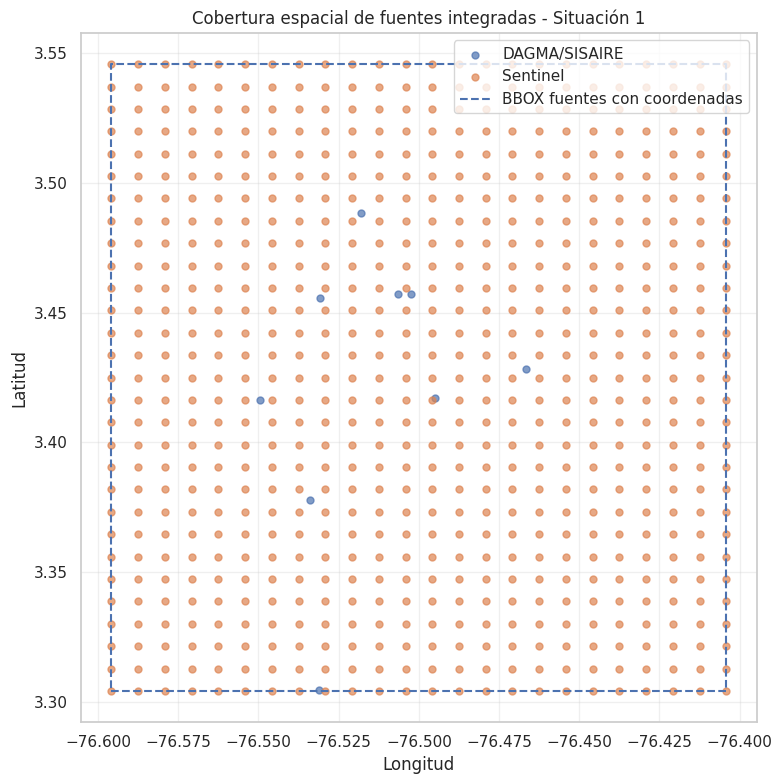

,fuente,existe,col_lat,col_lon,n_puntos,lat_min,lat_max,lon_min,lon_max,tipo_cobertura,interpretacion
0,DAGMA/SISAIRE,True,lat,lon,9.0000,3.3045,3.4882,-76.5496,-76.4666,Con coordenadas explícitas,Fuente con coordenadas explícitas y cobertura ...
1,ERA5-Land,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sin coordenadas explícitas en el archivo conso...,Fuente sin coordenadas explícitas en el archiv...
2,MODIS MAIAC AOD consolidado,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sin coordenadas explícitas en el archivo conso...,Fuente sin coordenadas explícitas en el archiv...
3,Sentinel-5P,True,s5p_lat_center,s5p_lon_center,696.0000,3.3043,3.5457,-76.5958,-76.4042,Con coordenadas explícitas,Fuente con coordenadas explícitas y cobertura ...


In [6]:
# ============================================================
# CELDA 04.1 — Área de estudio y cobertura espacial corregida
# Corrección:
# - Detección estricta de latitud/longitud.
# - Evita falsos positivos como relative_humidity_pct.
# - Reporta correctamente fuentes sin coordenadas explícitas.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. Cargar fuentes principales
# ------------------------------------------------------------

path_dagma = Path(RUTAS["dagma_largo"])
path_era5 = Path(RUTAS["era5_land"])
path_modis = Path(RUTAS["modis_maiac"])
path_s5p = Path(RUTAS["sentinel5p"])

print("DAGMA:", path_dagma, "| existe:", path_dagma.exists())
print("ERA5:", path_era5, "| existe:", path_era5.exists())
print("MODIS:", path_modis, "| existe:", path_modis.exists())
print("Sentinel-5P:", path_s5p, "| existe:", path_s5p.exists())

df_dagma_geo = pd.read_parquet(path_dagma) if path_dagma.exists() else None
df_era5_geo = pd.read_parquet(path_era5) if path_era5.exists() else None
df_modis_geo = pd.read_parquet(path_modis) if path_modis.exists() else None
df_s5p_geo = pd.read_parquet(path_s5p) if path_s5p.exists() else None

# Normalizar nombres de columnas
for df in [df_dagma_geo, df_era5_geo, df_modis_geo, df_s5p_geo]:
    if df is not None:
        df.columns = [c.strip().lower() for c in df.columns]


# ------------------------------------------------------------
# 2. Funciones auxiliares corregidas
# ------------------------------------------------------------

def buscar_columna_geo_estricta(cols, tipo="lat"):
    """
    Detecta columnas espaciales evitando falsos positivos.

    Ejemplo del problema:
    - relative_humidity_pct contiene 'lat' dentro de 'relative',
      pero NO es una columna de latitud.

    Por eso se usan coincidencias exactas o patrones seguros.
    """
    cols_norm = [c.lower().strip() for c in cols]

    if tipo == "lat":
        candidatos_exactos = [
            "lat", "latitude", "latitud", "y", "coord_y",
            "lat_deg", "latitude_deg", "s5p_lat_center", "s2_lat_center", "modis_lat_center"
        ]
    else:
        candidatos_exactos = [
            "lon", "lng", "long", "longitude", "longitud", "x", "coord_x",
            "lon_deg", "longitude_deg", "s5p_lon_center", "s2_lon_center", "modis_lon_center"
        ]

    # 1. Coincidencia exacta
    for original, norm in zip(cols, cols_norm):
        if norm in candidatos_exactos:
            return original

    # 2. Patrones seguros
    for original, norm in zip(cols, cols_norm):
        if tipo == "lat":
            if (
                norm.startswith("lat_")
                or norm.endswith("_lat")
                or norm.startswith("latitude_")
                or norm.endswith("_latitude")
            ):
                return original
        else:
            if (
                norm.startswith("lon_")
                or norm.endswith("_lon")
                or norm.startswith("lng_")
                or norm.endswith("_lng")
                or norm.startswith("longitude_")
                or norm.endswith("_longitude")
            ):
                return original

    return None


def obtener_lat_lon(df):
    """
    Devuelve columnas de latitud y longitud usando detección estricta.
    """
    if df is None:
        return None, None

    cols = list(df.columns)

    col_lat = buscar_columna_geo_estricta(cols, tipo="lat")
    col_lon = buscar_columna_geo_estricta(cols, tipo="lon")

    return col_lat, col_lon


def resumen_bbox(df, nombre):
    """
    Resume rango espacial de una fuente.
    Si la fuente no tiene coordenadas explícitas, lo reporta sin inventar bbox.
    """
    if df is None:
        return {
            "fuente": nombre,
            "existe": False,
            "col_lat": None,
            "col_lon": None,
            "n_puntos": np.nan,
            "lat_min": np.nan,
            "lat_max": np.nan,
            "lon_min": np.nan,
            "lon_max": np.nan,
            "tipo_cobertura": "Archivo no disponible"
        }

    col_lat, col_lon = obtener_lat_lon(df)

    if col_lat is None or col_lon is None:
        return {
            "fuente": nombre,
            "existe": True,
            "col_lat": col_lat,
            "col_lon": col_lon,
            "n_puntos": np.nan,
            "lat_min": np.nan,
            "lat_max": np.nan,
            "lon_min": np.nan,
            "lon_max": np.nan,
            "tipo_cobertura": "Sin coordenadas explícitas en el archivo consolidado"
        }

    tmp = df[[col_lat, col_lon]].copy()
    tmp[col_lat] = pd.to_numeric(tmp[col_lat], errors="coerce")
    tmp[col_lon] = pd.to_numeric(tmp[col_lon], errors="coerce")
    tmp = tmp.dropna()

    tmp_unique = tmp.drop_duplicates()

    return {
        "fuente": nombre,
        "existe": True,
        "col_lat": col_lat,
        "col_lon": col_lon,
        "n_puntos": len(tmp_unique),
        "lat_min": tmp_unique[col_lat].min(),
        "lat_max": tmp_unique[col_lat].max(),
        "lon_min": tmp_unique[col_lon].min(),
        "lon_max": tmp_unique[col_lon].max(),
        "tipo_cobertura": "Con coordenadas explícitas"
    }


def extraer_puntos(df, nombre, max_points=5000):
    """
    Extrae puntos espaciales para visualización.
    Si la fuente no tiene lat/lon explícitas, devuelve DataFrame vacío.
    """
    if df is None:
        return pd.DataFrame(columns=["fuente", "lat", "lon"])

    col_lat, col_lon = obtener_lat_lon(df)

    if col_lat is None or col_lon is None:
        return pd.DataFrame(columns=["fuente", "lat", "lon"])

    tmp = df[[col_lat, col_lon]].copy()
    tmp[col_lat] = pd.to_numeric(tmp[col_lat], errors="coerce")
    tmp[col_lon] = pd.to_numeric(tmp[col_lon], errors="coerce")
    tmp = tmp.dropna().drop_duplicates()

    if len(tmp) > max_points:
        tmp = tmp.sample(max_points, random_state=42)

    tmp = tmp.rename(columns={col_lat: "lat", col_lon: "lon"})
    tmp["fuente"] = nombre

    return tmp[["fuente", "lat", "lon"]]


# ------------------------------------------------------------
# 3. Resumen espacial por fuente
# ------------------------------------------------------------

resumen_espacial = pd.DataFrame([
    resumen_bbox(df_dagma_geo, "DAGMA/SISAIRE"),
    resumen_bbox(df_era5_geo, "ERA5-Land"),
    resumen_bbox(df_modis_geo, "MODIS MAIAC AOD consolidado"),
    resumen_bbox(df_s5p_geo, "Sentinel-5P")
])

display(resumen_espacial)

resumen_espacial.to_csv(
    TAB_DIR / "04_resumen_cobertura_espacial_fuentes.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Extraer puntos disponibles para mapa simple
# ------------------------------------------------------------

puntos_dagma = extraer_puntos(df_dagma_geo, "DAGMA/SISAIRE")
puntos_era5 = extraer_puntos(df_era5_geo, "ERA5-Land")
puntos_modis = extraer_puntos(df_modis_geo, "MODIS MAIAC AOD consolidado")
puntos_s5p = extraer_puntos(df_s5p_geo, "Sentinel")

puntos_fuentes = pd.concat(
    [puntos_dagma, puntos_era5, puntos_modis, puntos_s5p],
    ignore_index=True
)

display(puntos_fuentes.head())

puntos_fuentes.to_csv(
    TAB_DIR / "04_puntos_cobertura_espacial_fuentes.csv",
    index=False
)


# ------------------------------------------------------------
# 5. BBOX general calculado solo con fuentes que tienen coordenadas
# ------------------------------------------------------------

if len(puntos_fuentes) > 0:
    lat_min = puntos_fuentes["lat"].min()
    lat_max = puntos_fuentes["lat"].max()
    lon_min = puntos_fuentes["lon"].min()
    lon_max = puntos_fuentes["lon"].max()

    bbox_estudio = {
        "lat_min": lat_min,
        "lat_max": lat_max,
        "lon_min": lon_min,
        "lon_max": lon_max
    }

else:
    lat_min = np.nan
    lat_max = np.nan
    lon_min = np.nan
    lon_max = np.nan

    bbox_estudio = {
        "lat_min": np.nan,
        "lat_max": np.nan,
        "lon_min": np.nan,
        "lon_max": np.nan
    }

print("BBOX calculado desde fuentes con coordenadas explícitas:")
print(bbox_estudio)


# ------------------------------------------------------------
# 6. Mapa simple de cobertura espacial
# ------------------------------------------------------------

FIG_DIR.mkdir(parents=True, exist_ok=True)

if len(puntos_fuentes) > 0:

    fig, ax = plt.subplots(figsize=(8, 8))

    for fuente, grupo in puntos_fuentes.groupby("fuente"):
        ax.scatter(
            grupo["lon"],
            grupo["lat"],
            label=fuente,
            alpha=0.7,
            s=25
        )

    # Dibujar BBOX general solo si existe
    if pd.notna(lat_min) and pd.notna(lon_min):
        ax.plot(
            [lon_min, lon_max, lon_max, lon_min, lon_min],
            [lat_min, lat_min, lat_max, lat_max, lat_min],
            linestyle="--",
            linewidth=1.5,
            label="BBOX fuentes con coordenadas"
        )

    ax.set_title("Cobertura espacial de fuentes integradas - Situación 1")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "04_cobertura_espacial_fuentes_situacion1.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

else:
    print("No hay puntos espaciales explícitos para graficar cobertura espacial.")


# ------------------------------------------------------------
# 7. Tabla interpretativa de cobertura espacial
# ------------------------------------------------------------

tabla_cobertura_interpretativa = resumen_espacial.copy()

tabla_cobertura_interpretativa["interpretacion"] = tabla_cobertura_interpretativa.apply(
    lambda row: (
        "Fuente con coordenadas explícitas y cobertura espacial verificable."
        if row["tipo_cobertura"] == "Con coordenadas explícitas"
        else "Fuente sin coordenadas explícitas en el archivo consolidado; su cobertura espacial depende del recorte/procesamiento previo."
    ),
    axis=1
)

display(tabla_cobertura_interpretativa)

tabla_cobertura_interpretativa.to_csv(
    TAB_DIR / "04_tabla_interpretativa_cobertura_espacial.csv",
    index=False
)

In [7]:
# ============================================================
# 04.3 Coordenadas de estaciones terrestres DAGMA/SISAIRE
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

path_dagma = Path(RUTAS["dagma_largo"])

df_estaciones = pd.read_parquet(path_dagma)
df_estaciones.columns = [c.strip().lower() for c in df_estaciones.columns]

print("Columnas disponibles:")
print(df_estaciones.columns.tolist())


# ------------------------------------------------------------
# Funciones auxiliares para detectar columnas
# ------------------------------------------------------------

def buscar_columna(cols, candidatos):
    for cand in candidatos:
        for c in cols:
            if cand in c.lower():
                return c
    return None


col_estacion = buscar_columna(
    df_estaciones.columns,
    ["estacion", "station", "site", "nombre_estacion"]
)

col_lat = buscar_columna(
    df_estaciones.columns,
    ["latitude", "latitud", "lat"]
)

col_lon = buscar_columna(
    df_estaciones.columns,
    ["longitude", "longitud", "lon", "lng"]
)

print("Columna estación:", col_estacion)
print("Columna latitud:", col_lat)
print("Columna longitud:", col_lon)

if col_estacion is None:
    raise ValueError("No se encontró columna de estación.")

if col_lat is None:
    raise ValueError("No se encontró columna de latitud.")

if col_lon is None:
    raise ValueError("No se encontró columna de longitud.")


# ------------------------------------------------------------
# Limpieza básica de coordenadas
# ------------------------------------------------------------

df_estaciones[col_estacion] = df_estaciones[col_estacion].astype(str).str.strip()

df_estaciones[col_lat] = pd.to_numeric(df_estaciones[col_lat], errors="coerce")
df_estaciones[col_lon] = pd.to_numeric(df_estaciones[col_lon], errors="coerce")

df_estaciones_coord = (
    df_estaciones
    .dropna(subset=[col_estacion, col_lat, col_lon])
    .groupby(col_estacion)
    .agg(
        latitud=(col_lat, "median"),
        longitud=(col_lon, "median"),
        n_registros=(col_estacion, "size"),
        lat_min=(col_lat, "min"),
        lat_max=(col_lat, "max"),
        lon_min=(col_lon, "min"),
        lon_max=(col_lon, "max")
    )
    .reset_index()
    .rename(columns={col_estacion: "estacion"})
    .sort_values("estacion")
)

# Redondear para tabla limpia
cols_coord = ["latitud", "longitud", "lat_min", "lat_max", "lon_min", "lon_max"]
df_estaciones_coord[cols_coord] = df_estaciones_coord[cols_coord].round(6)

display(df_estaciones_coord)

df_estaciones_coord.to_csv(
    TAB_DIR / "04_coordenadas_estaciones_dagma.csv",
    index=False
)

print("Tabla guardada en:", TAB_DIR / "04_coordenadas_estaciones_dagma.csv")

Columnas disponibles:
['fecha_hora', 'municipio', 'estacion', 'contaminante', 'unidad', 'valor', 'source_dataset', 'lat', 'lon', 'date', 'year', 'month', 'day', 'hour']
Columna estación: estacion
Columna latitud: lat
Columna longitud: lon


,estacion,latitud,longitud,n_registros,lat_min,lat_max,lon_min,lon_max
0,Base Aerea,3.4571,-76.5023,13423,3.4571,3.4571,-76.5023,-76.5023
1,Canaveralejo,3.4164,-76.5496,24401,3.4164,3.4164,-76.5496,-76.5496
2,Compartir,3.4283,-76.4666,29577,3.4283,3.4283,-76.4666,-76.4666
3,ERA - Obrero,3.4573,-76.5065,28921,3.4573,3.4573,-76.5065,-76.5065
4,Ermita,3.4555,-76.5310,27057,3.4555,3.4555,-76.5310,-76.5310
5,Flora,3.4882,-76.5181,3,3.4882,3.4882,-76.5181,-76.5181
6,Pance,3.3045,-76.5313,30169,3.3045,3.3045,-76.5313,-76.5313
7,TRANSITORIA-NAVARRO,3.4172,-76.4950,21486,3.4172,3.4172,-76.4950,-76.4950
8,Univalle,3.3779,-76.5338,13905,3.3779,3.3779,-76.5338,-76.5338


Tabla guardada en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas/04_coordenadas_estaciones_dagma.csv


<!-- interpretacion-s1:cobertura-espacial -->
**Interpretacion.** La cobertura espacial confirma que las fuentes estan alineadas sobre Cali y que las estaciones DAGMA/SISAIRE caen dentro del area de trabajo. Esto permite unir mediciones terrestres con grillas satelitales sin cambiar el territorio de analisis.

## 05. EDA DAGMA/SISAIRE Ground Truth

### 05.1 Disponibilidad del ground truth terrestre

En esta sección se analiza la disponibilidad de las mediciones terrestres provenientes de DAGMA/SISAIRE. 
Estas mediciones representan la fuente oficial de observación directa de contaminantes atmosféricos en estaciones fijas.

El objetivo del análisis no es modelar todavía, sino responder tres preguntas operativas:

1. ¿Qué contaminantes están disponibles?
2. ¿Qué estaciones aportan mediciones para cada contaminante?
3. ¿Qué tan uniforme es la cobertura temporal y espacial de la red terrestre?

Esta evidencia permite justificar por qué la Situación 1 requiere consolidar fuentes complementarias como Sentinel-5P, MODIS/MAIAC, Sentinel-2 y ERA5-Land.

In [8]:
# ============================================================
# 05.1 EDA DAGMA/SISAIRE Ground Truth
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

path_dagma = Path(RUTAS["dagma_largo"])

print("Ruta DAGMA largo:", path_dagma)
print("Existe:", path_dagma.exists())

df_dagma = pd.read_parquet(path_dagma)
df_dagma.columns = [c.strip().lower() for c in df_dagma.columns]

print("Shape DAGMA:", df_dagma.shape)
display(df_dagma.head())
print(df_dagma.columns.tolist())


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def buscar_columna(cols, candidatos):
    for cand in candidatos:
        for c in cols:
            if cand in c.lower():
                return c
    return None


col_fecha = buscar_columna(
    df_dagma.columns,
    ["datetime", "fecha", "date", "timestamp", "period", "time"]
)

col_estacion = buscar_columna(
    df_dagma.columns,
    ["estacion", "station", "site", "nombre_estacion"]
)

col_contaminante = buscar_columna(
    df_dagma.columns,
    ["contaminante", "pollutant", "variable", "parametro", "parámetro"]
)

col_valor = buscar_columna(
    df_dagma.columns,
    ["valor", "medicion", "medición", "value", "concentracion", "concentración", "measurement"]
)

print("Columna fecha:", col_fecha)
print("Columna estación:", col_estacion)
print("Columna contaminante:", col_contaminante)
print("Columna valor:", col_valor)

if col_fecha is None:
    raise ValueError("No se encontró columna temporal en DAGMA.")

if col_estacion is None:
    raise ValueError("No se encontró columna de estación en DAGMA.")

if col_contaminante is None:
    raise ValueError("No se encontró columna de contaminante en DAGMA.")

if col_valor is None:
    raise ValueError("No se encontró columna de medición/valor en DAGMA.")


# ------------------------------------------------------------
# Preparación mínima
# ------------------------------------------------------------

df_dagma[col_fecha] = pd.to_datetime(df_dagma[col_fecha], errors="coerce")
df_dagma[col_valor] = pd.to_numeric(df_dagma[col_valor], errors="coerce")

df_dagma[col_estacion] = df_dagma[col_estacion].astype(str).str.strip()
df_dagma[col_contaminante] = (
    df_dagma[col_contaminante]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_dagma["anio"] = df_dagma[col_fecha].dt.year
df_dagma["mes"] = df_dagma[col_fecha].dt.to_period("M").astype(str)


# ------------------------------------------------------------
# Resumen general
# ------------------------------------------------------------

resumen_ground_truth = pd.DataFrame({
    "metrica": [
        "filas_totales",
        "registros_validos",
        "estaciones_unicas",
        "contaminantes_unicos",
        "fecha_min",
        "fecha_max",
        "porcentaje_medicion_nula",
        "porcentaje_fecha_nula"
    ],
    "valor": [
        len(df_dagma),
        df_dagma[col_valor].notna().sum(),
        df_dagma[col_estacion].nunique(),
        df_dagma[col_contaminante].nunique(),
        df_dagma[col_fecha].min(),
        df_dagma[col_fecha].max(),
        round(df_dagma[col_valor].isna().mean() * 100, 3),
        round(df_dagma[col_fecha].isna().mean() * 100, 3)
    ]
})

display(resumen_ground_truth)

resumen_ground_truth.to_csv(
    TAB_DIR / "05_dagma_resumen_ground_truth.csv",
    index=False
)


# ------------------------------------------------------------
# Registros por contaminante
# ------------------------------------------------------------

dagma_por_contaminante = (
    df_dagma
    .groupby(col_contaminante, dropna=False)
    .agg(
        n_registros=(col_valor, "size"),
        n_validos=(col_valor, lambda x: x.notna().sum()),
        pct_nulos=(col_valor, lambda x: round(x.isna().mean() * 100, 3)),
        estaciones=(col_estacion, "nunique"),
        fecha_min=(col_fecha, "min"),
        fecha_max=(col_fecha, "max")
    )
    .reset_index()
    .sort_values("n_validos", ascending=False)
)

display(dagma_por_contaminante)

dagma_por_contaminante.to_csv(
    TAB_DIR / "05_dagma_por_contaminante.csv",
    index=False
)


# ------------------------------------------------------------
# Registros por estación
# ------------------------------------------------------------

dagma_por_estacion = (
    df_dagma
    .groupby(col_estacion, dropna=False)
    .agg(
        n_registros=(col_valor, "size"),
        n_validos=(col_valor, lambda x: x.notna().sum()),
        pct_nulos=(col_valor, lambda x: round(x.isna().mean() * 100, 3)),
        contaminantes=(col_contaminante, "nunique"),
        fecha_min=(col_fecha, "min"),
        fecha_max=(col_fecha, "max")
    )
    .reset_index()
    .sort_values("n_validos", ascending=False)
)

display(dagma_por_estacion)

dagma_por_estacion.to_csv(
    TAB_DIR / "05_dagma_por_estacion.csv",
    index=False
)


# ------------------------------------------------------------
# Matriz estación x contaminante
# ------------------------------------------------------------

dagma_matriz_estacion_contaminante = pd.pivot_table(
    df_dagma,
    index=col_estacion,
    columns=col_contaminante,
    values=col_valor,
    aggfunc=lambda x: x.notna().sum(),
    fill_value=0
)

display(dagma_matriz_estacion_contaminante)

dagma_matriz_estacion_contaminante.to_csv(
    TAB_DIR / "05_dagma_matriz_estacion_contaminante.csv"
)


# ------------------------------------------------------------
# Disponibilidad por año y contaminante
# ------------------------------------------------------------

dagma_anio_contaminante = (
    df_dagma
    .dropna(subset=["anio"])
    .groupby(["anio", col_contaminante])
    .agg(
        n_registros=(col_valor, "size"),
        n_validos=(col_valor, lambda x: x.notna().sum()),
        estaciones=(col_estacion, "nunique")
    )
    .reset_index()
    .sort_values(["anio", col_contaminante])
)

display(dagma_anio_contaminante)

dagma_anio_contaminante.to_csv(
    TAB_DIR / "05_dagma_anio_contaminante.csv",
    index=False
)


# ------------------------------------------------------------
# Guardar columnas detectadas para reproducibilidad
# ------------------------------------------------------------

cols_dagma_detectadas = {
    "col_fecha": col_fecha,
    "col_estacion": col_estacion,
    "col_contaminante": col_contaminante,
    "col_valor": col_valor
}

with open(TAB_DIR / "05_dagma_columnas_detectadas.json", "w", encoding="utf-8") as f:
    json.dump(cols_dagma_detectadas, f, indent=4, ensure_ascii=False)

print("Tablas DAGMA guardadas en:", TAB_DIR)

Ruta DAGMA largo: /workspace/geovision-cali-hf/data/DAGMA/processed/panel_dagma_sisaire_largo_2020_2024.parquet
Existe: True


Shape DAGMA: (803146, 14)


,fecha_hora,municipio,estacion,contaminante,unidad,valor,source_dataset,lat,lon,date,year,month,day,hour
0,2020-01-01,Santiago de Cali,Canaveralejo,NO2,ug/m3,NaN,api_panel,3.4164,-76.5496,2020-01-01,2020,1,1,0
1,2020-01-01,Santiago de Cali,Canaveralejo,O3,ug/m3,NaN,api_panel,3.4164,-76.5496,2020-01-01,2020,1,1,0
2,2020-01-01,Santiago de Cali,Canaveralejo,SO2,ug/m3,0.0500,api_panel,3.4164,-76.5496,2020-01-01,2020,1,1,0
3,2020-01-01,Santiago de Cali,Compartir,NO2,ug/m3,NaN,api_panel,3.4283,-76.4666,2020-01-01,2020,1,1,0
4,2020-01-01,Santiago de Cali,Compartir,O3,ug/m3,10.0600,api_panel,3.4283,-76.4666,2020-01-01,2020,1,1,0


['fecha_hora', 'municipio', 'estacion', 'contaminante', 'unidad', 'valor', 'source_dataset', 'lat', 'lon', 'date', 'year', 'month', 'day', 'hour']
Columna fecha: fecha_hora
Columna estación: estacion
Columna contaminante: contaminante
Columna valor: valor


,metrica,valor
0,filas_totales,803146
1,registros_validos,349931
2,estaciones_unicas,10
3,contaminantes_unicos,3
4,fecha_min,2020-01-01 00:00:00
5,fecha_max,2024-12-31 23:00:00
6,porcentaje_medicion_nula,56.4300
7,porcentaje_fecha_nula,0.0000


,contaminante,n_registros,n_validos,pct_nulos,estaciones,fecha_min,fecha_max
1,O3,340070,191257,43.7600,10,2020-01-01,2024-12-31 23:00:00
2,SO2,284736,132415,53.4960,10,2020-01-01,2024-12-31 23:00:00
0,NO2,178340,26259,85.2760,9,2020-01-01,2024-12-31 23:00:00


,estacion,n_registros,n_validos,pct_nulos,contaminantes,fecha_min,fecha_max
9,Univalle,101600,60225,40.7230,3,2020-01-01 00:00:00,2024-12-31 23:00:00
0,Base Aerea,101117,52160,48.4160,3,2020-01-01 01:00:00,2024-12-31 23:00:00
5,Flora,131544,48718,62.9640,3,2020-01-01 00:00:00,2024-12-31 23:00:00
4,Ermita,70904,36920,47.9300,3,2020-01-01 00:00:00,2024-12-31 23:00:00
6,Pance,74016,36340,50.9030,3,2020-01-01 00:00:00,2024-12-31 23:00:00
2,Compartir,73424,35056,52.2550,3,2020-01-01 00:00:00,2024-12-31 23:00:00
1,Canaveralejo,68248,32923,51.7600,3,2020-01-01 00:00:00,2024-12-31 23:00:00
3,ERA - Obrero,72768,26535,63.5350,3,2020-01-01 00:00:00,2024-12-31 23:00:00
8,Transitoria - Navarro,87694,13274,84.8630,2,2020-01-01 01:00:00,2024-12-31 23:00:00
7,TRANSITORIA-NAVARRO,21831,7780,64.3630,3,2020-01-02 00:00:00,2022-12-10 23:00:00


contaminante,NO2,O3,SO2
estacion,,,
Base Aerea,0,29093,23067
Canaveralejo,0,0,32923
Compartir,0,35056,0
ERA - Obrero,0,26535,0
Ermita,0,0,36920
Flora,0,24327,24391
Pance,0,36340,0
TRANSITORIA-NAVARRO,0,4384,3396
Transitoria - Navarro,0,1556,11718


,anio,contaminante,n_registros,n_validos,estaciones
0,2020,NO2,64916,6992,9
1,2020,O3,81573,27149,10
2,2020,SO2,77808,20561,10
3,2021,NO2,34907,3564,8
4,2021,O3,66957,29752,9
5,2021,SO2,54513,19676,9
6,2022,NO2,42701,7449,9
7,2022,O3,68732,43540,10
8,2022,SO2,64168,25145,10
9,2023,NO2,18248,6276,3


Tablas DAGMA guardadas en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas


### 05.2 Visualizaciones de disponibilidad terrestre

A continuación se presentan visualizaciones compactas de la disponibilidad del ground truth terrestre. 
Estas figuras permiten identificar rápidamente qué contaminantes y estaciones tienen mayor cobertura, 
y evidenciar posibles vacíos espaciales o temporales en las mediciones oficiales.

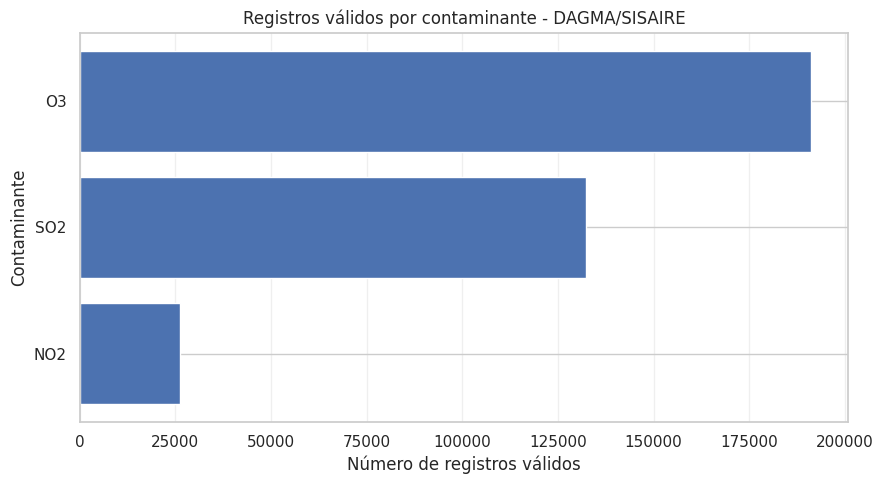

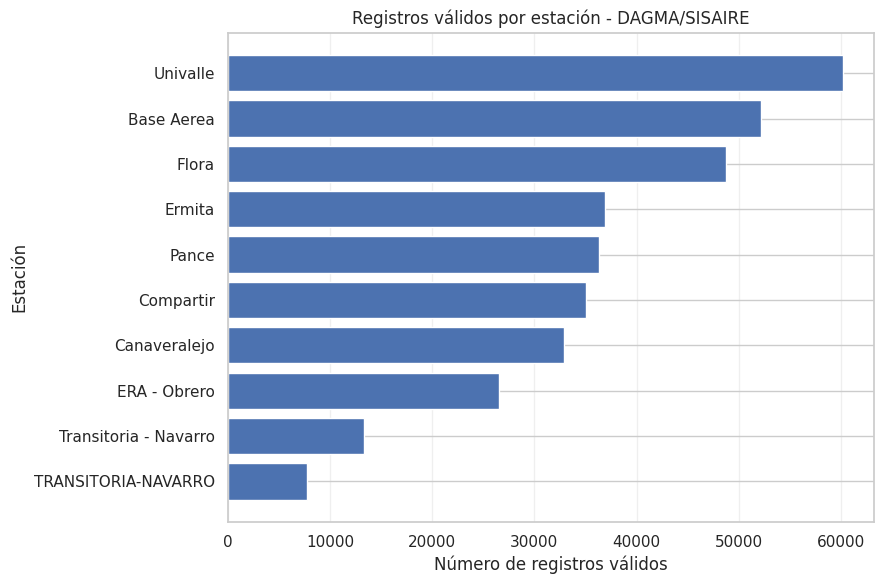

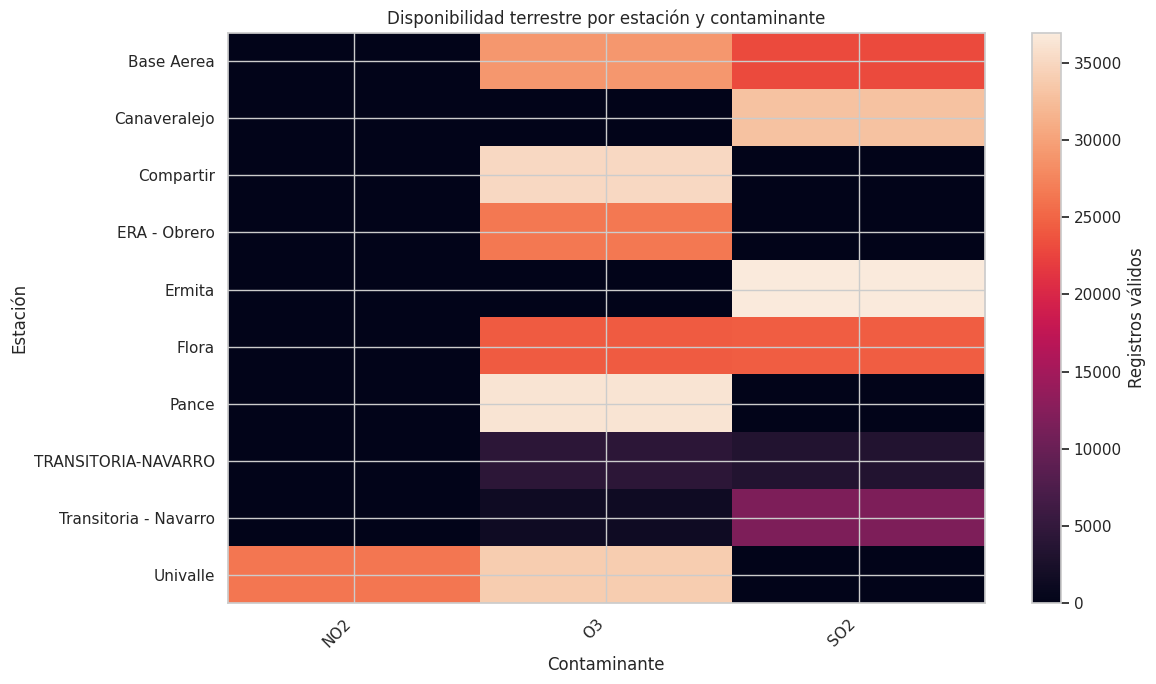

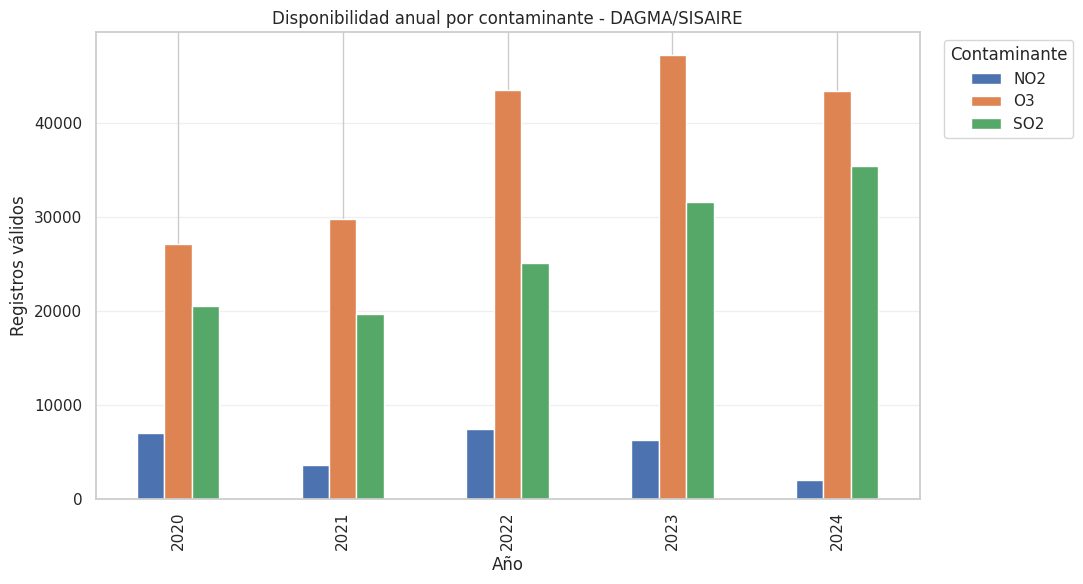

In [9]:
# ============================================================
# 05.2 Visualizaciones DAGMA/SISAIRE
# ============================================================

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Registros válidos por contaminante
# ------------------------------------------------------------

plot_df = dagma_por_contaminante.sort_values("n_validos", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df[col_contaminante], plot_df["n_validos"])
ax.set_title("Registros válidos por contaminante - DAGMA/SISAIRE")
ax.set_xlabel("Número de registros válidos")
ax.set_ylabel("Contaminante")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_dagma_registros_validos_por_contaminante.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 2. Registros válidos por estación
# ------------------------------------------------------------

plot_df = dagma_por_estacion.sort_values("n_validos", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df[col_estacion], plot_df["n_validos"])
ax.set_title("Registros válidos por estación - DAGMA/SISAIRE")
ax.set_xlabel("Número de registros válidos")
ax.set_ylabel("Estación")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_dagma_registros_validos_por_estacion.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 3. Heatmap estación x contaminante
# ------------------------------------------------------------

matriz_plot = dagma_matriz_estacion_contaminante.copy()

fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(matriz_plot.values, aspect="auto")

ax.set_xticks(np.arange(matriz_plot.shape[1]))
ax.set_yticks(np.arange(matriz_plot.shape[0]))

ax.set_xticklabels(matriz_plot.columns, rotation=45, ha="right")
ax.set_yticklabels(matriz_plot.index)

ax.set_title("Disponibilidad terrestre por estación y contaminante")
ax.set_xlabel("Contaminante")
ax.set_ylabel("Estación")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Registros válidos")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_dagma_heatmap_estacion_contaminante.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 4. Disponibilidad anual por contaminante
# ------------------------------------------------------------

pivot_anual = dagma_anio_contaminante.pivot_table(
    index="anio",
    columns=col_contaminante,
    values="n_validos",
    aggfunc="sum",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(11, 6))

pivot_anual.plot(kind="bar", ax=ax)

ax.set_title("Disponibilidad anual por contaminante - DAGMA/SISAIRE")
ax.set_xlabel("Año")
ax.set_ylabel("Registros válidos")
ax.legend(title="Contaminante", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_dagma_disponibilidad_anual_contaminante.png", dpi=300, bbox_inches="tight")
plt.show()

### 05.3 Tabla resumen para documentación

Se construye una tabla compacta con el resumen de disponibilidad por contaminante. 
Esta tabla será utilizada directamente en la documentación de la Situación 1.

In [10]:
# ============================================================
# 05.3 Tabla resumen compacta para informe
# ============================================================

tabla_dagma_informe = dagma_por_contaminante.copy()

tabla_dagma_informe["fecha_min"] = pd.to_datetime(tabla_dagma_informe["fecha_min"]).dt.strftime("%Y-%m-%d")
tabla_dagma_informe["fecha_max"] = pd.to_datetime(tabla_dagma_informe["fecha_max"]).dt.strftime("%Y-%m-%d")

tabla_dagma_informe = tabla_dagma_informe.rename(columns={
    col_contaminante: "contaminante",
    "n_registros": "registros_totales",
    "n_validos": "registros_validos",
    "pct_nulos": "porcentaje_nulos",
    "estaciones": "n_estaciones"
})

tabla_dagma_informe = tabla_dagma_informe[
    [
        "contaminante",
        "registros_totales",
        "registros_validos",
        "porcentaje_nulos",
        "n_estaciones",
        "fecha_min",
        "fecha_max"
    ]
]

display(tabla_dagma_informe)

tabla_dagma_informe.to_csv(
    TAB_DIR / "05_tabla_dagma_informe.csv",
    index=False
)

,contaminante,registros_totales,registros_validos,porcentaje_nulos,n_estaciones,fecha_min,fecha_max
1,O3,340070,191257,43.7600,10,2020-01-01,2024-12-31
2,SO2,284736,132415,53.4960,10,2020-01-01,2024-12-31
0,NO2,178340,26259,85.2760,9,2020-01-01,2024-12-31


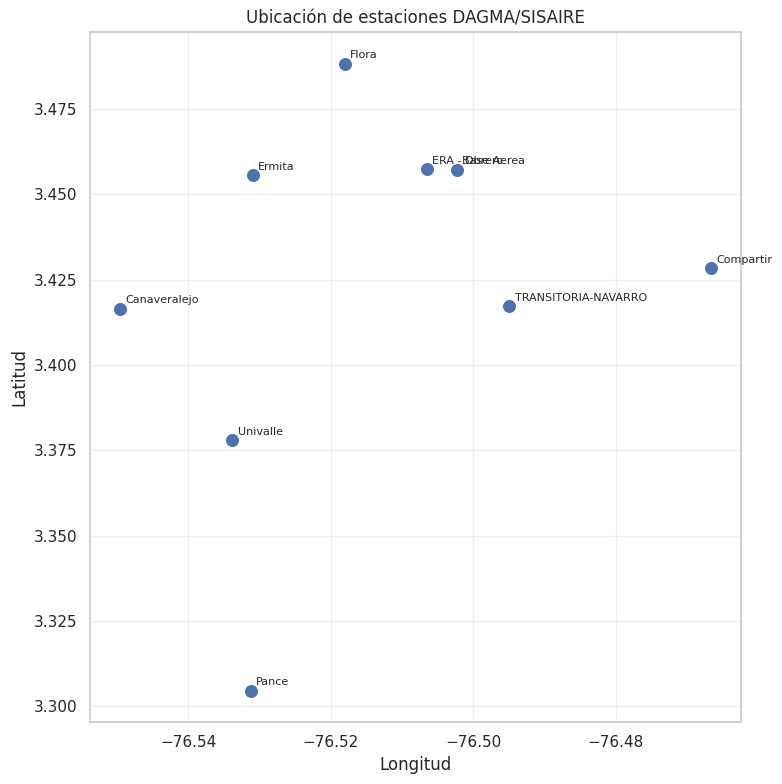

In [11]:
# ============================================================
# 05.4 Mapa simple de estaciones DAGMA/SISAIRE
# ============================================================

import matplotlib.pyplot as plt

FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    df_estaciones_coord["longitud"],
    df_estaciones_coord["latitud"],
    s=70
)

for _, row in df_estaciones_coord.iterrows():
    ax.annotate(
        row["estacion"],
        (row["longitud"], row["latitud"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Ubicación de estaciones DAGMA/SISAIRE")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "04_mapa_estaciones_dagma.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<!-- interpretacion-s1:dagma -->
**Interpretacion.** DAGMA/SISAIRE es la referencia terrestre del proyecto. Las tablas muestran que estaciones y contaminantes tienen datos utiles, y tambien evidencian que la red mide puntos especificos, no toda la ciudad de forma continua.

## 06. EDA ERA5-Land

Se analizaran variables meteorologicas horarias, distribuciones, nulos y series temporales.

### 06.1 Disponibilidad meteorológica ERA5-Land

En esta sección se analiza la fuente ERA5-Land, utilizada como contexto meteorológico del proyecto. 
A diferencia de DAGMA/SISAIRE, que entrega mediciones puntuales de contaminantes por estación, ERA5-Land aporta variables atmosféricas continuas en el tiempo y en grilla.

El objetivo de este bloque es verificar:

1. El rango temporal disponible.
2. Las variables meteorológicas existentes.
3. La presencia de valores nulos.
4. La utilidad de estas variables para contextualizar la dispersión o acumulación de contaminantes.

Las variables meteorológicas no reemplazan las mediciones de calidad del aire, pero permiten explicar condiciones ambientales asociadas a la concentración de contaminantes, como temperatura, humedad, viento y precipitación.

In [12]:
# ============================================================
# CELDA 06.1 — EDA ERA5-Land Meteorología corregida
# Corrección incluida:
# - No confunde relative_humidity_pct con latitud.
# - Detecta coordenadas espaciales solo con coincidencias estrictas.
# - Si ERA5 no tiene lat/lon explícitos, lo reporta como serie horaria agregada.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path_era5 = Path(RUTAS["era5_land"])

print("Ruta ERA5-Land:", path_era5)
print("Existe:", path_era5.exists())

df_era5 = pd.read_parquet(path_era5)
df_era5.columns = [c.strip().lower() for c in df_era5.columns]

print("Shape ERA5-Land:", df_era5.shape)
display(df_era5.head())
print(df_era5.columns.tolist())


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def buscar_columna(cols, candidatos):
    """
    Busca columnas por coincidencia parcial.
    Se usa para columnas temporales u otras columnas no espaciales.
    """
    for cand in candidatos:
        for c in cols:
            if cand in c.lower():
                return c
    return None


def buscar_columna_geo_estricta(cols, tipo="lat"):
    """
    Detecta columnas espaciales evitando falsos positivos.
    
    Ejemplo del problema:
    - relative_humidity_pct contiene 'lat' dentro de 'relative',
      pero NO es una columna de latitud.
    
    Por eso aquí usamos coincidencias exactas o patrones seguros.
    """
    cols_norm = [c.lower().strip() for c in cols]

    if tipo == "lat":
        candidatos_exactos = [
            "lat", "latitude", "latitud", "y", "coord_y", "lat_deg", "latitude_deg"
        ]
    else:
        candidatos_exactos = [
            "lon", "lng", "long", "longitude", "longitud", "x", "coord_x", "lon_deg", "longitude_deg"
        ]

    # 1. Coincidencia exacta
    for original, norm in zip(cols, cols_norm):
        if norm in candidatos_exactos:
            return original

    # 2. Patrones seguros
    for original, norm in zip(cols, cols_norm):
        if tipo == "lat":
            if (
                norm.startswith("lat_")
                or norm.endswith("_lat")
                or norm.startswith("latitude_")
                or norm.endswith("_latitude")
            ):
                return original
        else:
            if (
                norm.startswith("lon_")
                or norm.endswith("_lon")
                or norm.startswith("lng_")
                or norm.endswith("_lng")
                or norm.startswith("longitude_")
                or norm.endswith("_longitude")
            ):
                return original

    return None


# ------------------------------------------------------------
# Detección de columnas principales
# ------------------------------------------------------------

col_fecha_era5 = buscar_columna(
    df_era5.columns,
    ["datetime", "fecha", "date", "timestamp", "time", "period", "hora"]
)

# IMPORTANTE:
# Para coordenadas usamos búsqueda estricta, no búsqueda parcial.
col_lat_era5 = buscar_columna_geo_estricta(df_era5.columns, tipo="lat")
col_lon_era5 = buscar_columna_geo_estricta(df_era5.columns, tipo="lon")

print("Columna fecha ERA5:", col_fecha_era5)
print("Columna latitud ERA5 corregida:", col_lat_era5)
print("Columna longitud ERA5 corregida:", col_lon_era5)

if col_fecha_era5 is None:
    raise ValueError("No se encontró columna temporal en ERA5-Land.")

df_era5[col_fecha_era5] = pd.to_datetime(df_era5[col_fecha_era5], errors="coerce")
df_era5["anio"] = df_era5[col_fecha_era5].dt.year
df_era5["mes"] = df_era5[col_fecha_era5].dt.to_period("M").astype(str)


# ------------------------------------------------------------
# Detectar variables numéricas
# ------------------------------------------------------------

cols_excluir = {
    col_fecha_era5,
    col_lat_era5,
    col_lon_era5,
    "anio",
    "mes"
}

# Quitar None del set
cols_excluir = {c for c in cols_excluir if c is not None}

cols_numericas_era5 = [
    c for c in df_era5.columns
    if c not in cols_excluir and pd.api.types.is_numeric_dtype(df_era5[c])
]

print("Variables numéricas ERA5 detectadas:")
print(cols_numericas_era5)


# ------------------------------------------------------------
# Coordenadas espaciales explícitas
# ------------------------------------------------------------

if col_lat_era5 is not None and col_lon_era5 is not None:
    lat_min_era5 = df_era5[col_lat_era5].min()
    lat_max_era5 = df_era5[col_lat_era5].max()
    lon_min_era5 = df_era5[col_lon_era5].min()
    lon_max_era5 = df_era5[col_lon_era5].max()
    tipo_cobertura_era5 = "Con coordenadas explícitas en el archivo consolidado"
else:
    lat_min_era5 = np.nan
    lat_max_era5 = np.nan
    lon_min_era5 = np.nan
    lon_max_era5 = np.nan
    tipo_cobertura_era5 = (
        "Serie horaria agregada/recortada para el área de estudio; "
        "sin columnas explícitas de latitud y longitud en este archivo"
    )

print("Tipo de cobertura ERA5:", tipo_cobertura_era5)


# ------------------------------------------------------------
# Resumen general ERA5
# ------------------------------------------------------------

resumen_era5_general = pd.DataFrame({
    "metrica": [
        "filas_totales",
        "columnas_totales",
        "variables_numericas",
        "fecha_min",
        "fecha_max",
        "anios_disponibles",
        "lat_min",
        "lat_max",
        "lon_min",
        "lon_max",
        "tipo_cobertura"
    ],
    "valor": [
        len(df_era5),
        df_era5.shape[1],
        len(cols_numericas_era5),
        df_era5[col_fecha_era5].min(),
        df_era5[col_fecha_era5].max(),
        ", ".join(map(str, sorted(df_era5["anio"].dropna().unique().astype(int)))),
        lat_min_era5,
        lat_max_era5,
        lon_min_era5,
        lon_max_era5,
        tipo_cobertura_era5
    ]
})

display(resumen_era5_general)

resumen_era5_general.to_csv(
    TAB_DIR / "06_era5_resumen_general.csv",
    index=False
)


# ------------------------------------------------------------
# Calidad por variable meteorológica
# ------------------------------------------------------------

calidad_era5 = []

for col in cols_numericas_era5:
    serie = pd.to_numeric(df_era5[col], errors="coerce")

    calidad_era5.append({
        "variable": col,
        "n_registros": len(serie),
        "n_validos": serie.notna().sum(),
        "porcentaje_nulos": round(serie.isna().mean() * 100, 4),
        "media": serie.mean(),
        "desviacion": serie.std(),
        "min": serie.min(),
        "p25": serie.quantile(0.25),
        "mediana": serie.median(),
        "p75": serie.quantile(0.75),
        "max": serie.max()
    })

df_calidad_era5 = pd.DataFrame(calidad_era5)

display(df_calidad_era5)

df_calidad_era5.to_csv(
    TAB_DIR / "06_era5_calidad_variables.csv",
    index=False
)


# ------------------------------------------------------------
# Disponibilidad temporal mensual
# ------------------------------------------------------------

era5_disponibilidad_mensual = (
    df_era5
    .groupby("mes")
    .agg(
        n_registros=(col_fecha_era5, "size")
    )
    .reset_index()
)

display(era5_disponibilidad_mensual.head())

era5_disponibilidad_mensual.to_csv(
    TAB_DIR / "06_era5_disponibilidad_mensual.csv",
    index=False
)


# ------------------------------------------------------------
# Resumen rápido para interpretar en el informe
# ------------------------------------------------------------

print("\nResumen interpretativo ERA5-Land:")
print(f"- Registros horarios: {len(df_era5):,}")
print(f"- Periodo: {df_era5[col_fecha_era5].min()} a {df_era5[col_fecha_era5].max()}")
print(f"- Años disponibles: {', '.join(map(str, sorted(df_era5['anio'].dropna().unique().astype(int))))}")
print(f"- Variables numéricas meteorológicas: {len(cols_numericas_era5)}")
print(f"- Cobertura espacial en este archivo: {tipo_cobertura_era5}")

Ruta ERA5-Land: /workspace/geovision-cali-hf/data/era5_modis/era5_land_cali_hourly_2020_2024.parquet
Existe: True
Shape ERA5-Land: (43848, 12)


,fecha_hora,temperature_2m_c,dewpoint_2m_c,relative_humidity_pct,u10_m_s,v10_m_s,wind_speed_10m,wind_direction_10m_deg,surface_pressure_hpa,total_precipitation_mm_raw,total_precipitation_mm_hourly,surface_solar_radiation_downwards_j_m2
0,2020-01-01 00:00:00,18.8133,17.7039,93.2766,-0.2727,-0.2106,0.3446,52.3291,868.4973,73.1302,NaN,"10,811,376.0000"
1,2020-01-01 01:00:00,18.8326,17.4128,91.4694,-0.0770,-0.2812,0.2916,15.3189,867.6541,0.9428,0.9428,0.0000
2,2020-01-01 02:00:00,18.5536,17.1890,91.7712,-0.2652,-0.6148,0.6695,23.3353,868.5192,2.1757,1.2328,0.0000
3,2020-01-01 03:00:00,18.4573,17.0234,91.3638,-0.3151,-0.6187,0.6943,26.9856,868.9822,3.5174,1.3417,0.0000
4,2020-01-01 04:00:00,18.6060,16.9590,90.1491,-0.1048,-0.5286,0.5389,11.2126,868.7464,4.8454,1.3280,0.0000


['fecha_hora', 'temperature_2m_c', 'dewpoint_2m_c', 'relative_humidity_pct', 'u10_m_s', 'v10_m_s', 'wind_speed_10m', 'wind_direction_10m_deg', 'surface_pressure_hpa', 'total_precipitation_mm_raw', 'total_precipitation_mm_hourly', 'surface_solar_radiation_downwards_j_m2']
Columna fecha ERA5: fecha_hora
Columna latitud ERA5 corregida: None
Columna longitud ERA5 corregida: None
Variables numéricas ERA5 detectadas:
['temperature_2m_c', 'dewpoint_2m_c', 'relative_humidity_pct', 'u10_m_s', 'v10_m_s', 'wind_speed_10m', 'wind_direction_10m_deg', 'surface_pressure_hpa', 'total_precipitation_mm_raw', 'total_precipitation_mm_hourly', 'surface_solar_radiation_downwards_j_m2']
Tipo de cobertura ERA5: Serie horaria agregada/recortada para el área de estudio; sin columnas explícitas de latitud y longitud en este archivo


,metrica,valor
0,filas_totales,43848
1,columnas_totales,14
2,variables_numericas,11
3,fecha_min,2020-01-01 00:00:00
4,fecha_max,2024-12-31 23:00:00
5,anios_disponibles,"2020, 2021, 2022, 2023, 2024"
6,lat_min,NaN
7,lat_max,NaN
8,lon_min,NaN
9,lon_max,NaN


,variable,n_registros,n_validos,porcentaje_nulos,media,desviacion,min,p25,mediana,p75,max
0,temperature_2m_c,43848,43848,0.0000,19.9627,2.2161,12.9141,18.3418,19.4921,21.5400,27.7313
1,dewpoint_2m_c,43848,43848,0.0000,16.9658,1.1075,10.3228,16.2577,17.0369,17.7283,21.2310
2,relative_humidity_pct,43848,43848,0.0000,83.3626,7.9487,46.8029,78.8419,85.6191,89.0610,98.8317
3,u10_m_s,43848,43848,0.0000,-0.0460,0.5447,-1.6613,-0.4769,-0.1110,0.3549,1.6605
4,v10_m_s,43848,43848,0.0000,-0.5153,0.5107,-2.5023,-0.8538,-0.4968,-0.1820,1.7137
5,wind_speed_10m,43848,43848,0.0000,0.8351,0.3576,0.0062,0.5884,0.8141,1.0525,2.5024
6,wind_direction_10m_deg,43848,43848,0.0000,161.7979,134.4707,0.0007,32.8303,104.2732,302.9792,359.9958
7,surface_pressure_hpa,43848,43848,0.0000,867.9533,2.0658,860.2222,866.4882,867.9473,869.4468,874.2499
8,total_precipitation_mm_raw,43848,43848,0.0000,5.5865,7.9580,0.0003,1.0309,2.8097,6.7712,109.0657
9,total_precipitation_mm_hourly,43848,43847,0.0023,0.4363,0.6858,0.0000,0.0614,0.2092,0.5353,12.0751


,mes,n_registros
0,2020-01,744
1,2020-02,696
2,2020-03,744
3,2020-04,720
4,2020-05,744



Resumen interpretativo ERA5-Land:
- Registros horarios: 43,848
- Periodo: 2020-01-01 00:00:00 a 2024-12-31 23:00:00
- Años disponibles: 2020, 2021, 2022, 2023, 2024
- Variables numéricas meteorológicas: 11
- Cobertura espacial en este archivo: Serie horaria agregada/recortada para el área de estudio; sin columnas explícitas de latitud y longitud en este archivo


### 06.2 Visualizaciones de variables meteorológicas

Las siguientes visualizaciones resumen la cobertura temporal y el comportamiento general de las variables meteorológicas de ERA5-Land. 
Estas figuras permiten verificar continuidad temporal y observar tendencias o variaciones relevantes para el análisis ambiental.

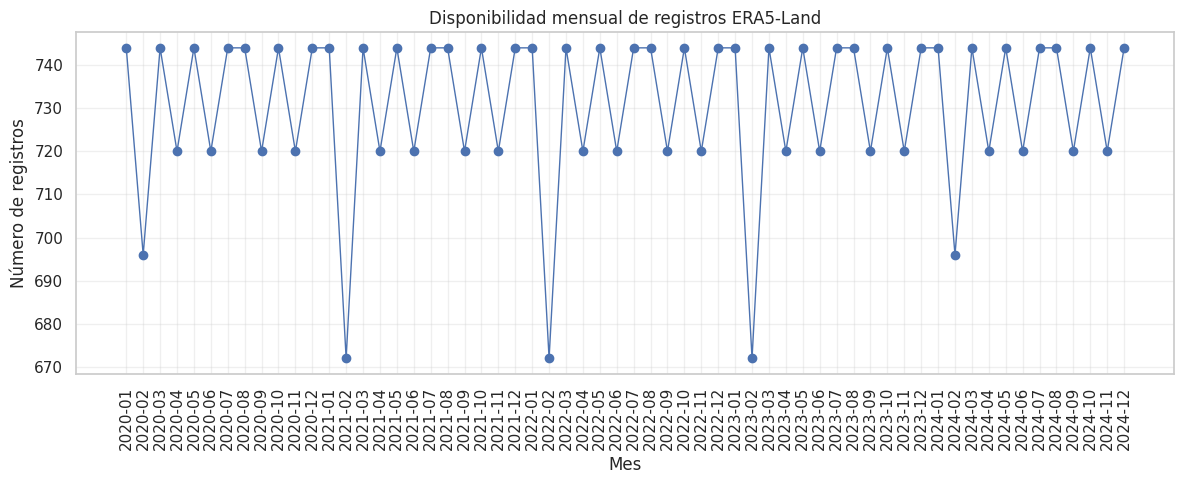

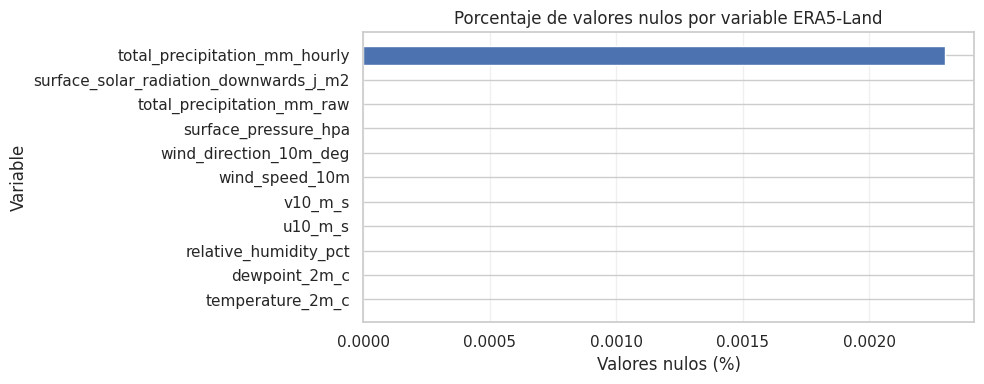

Variables para series temporales: ['temperature_2m_c', 'dewpoint_2m_c', 'relative_humidity_pct', 'wind_speed_10m']


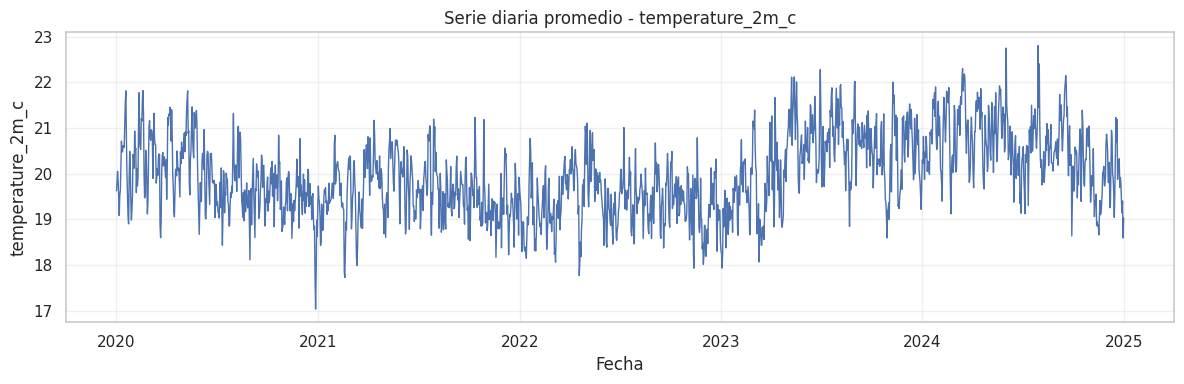

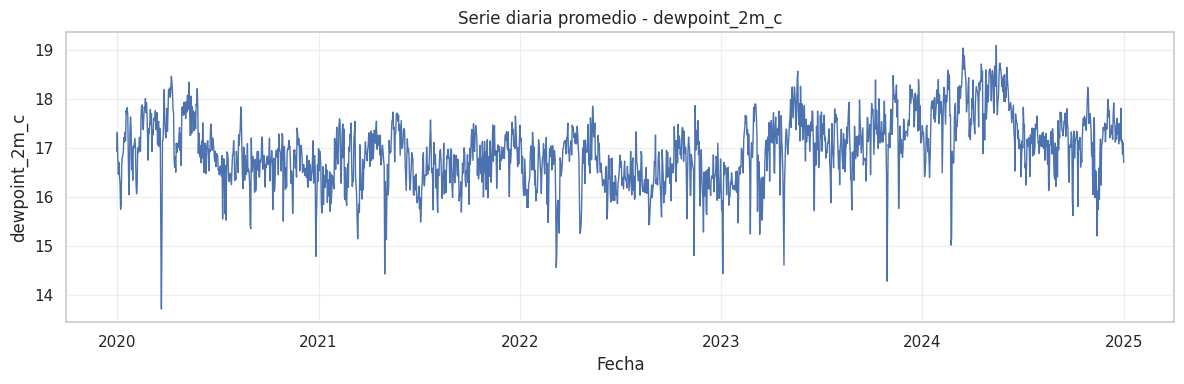

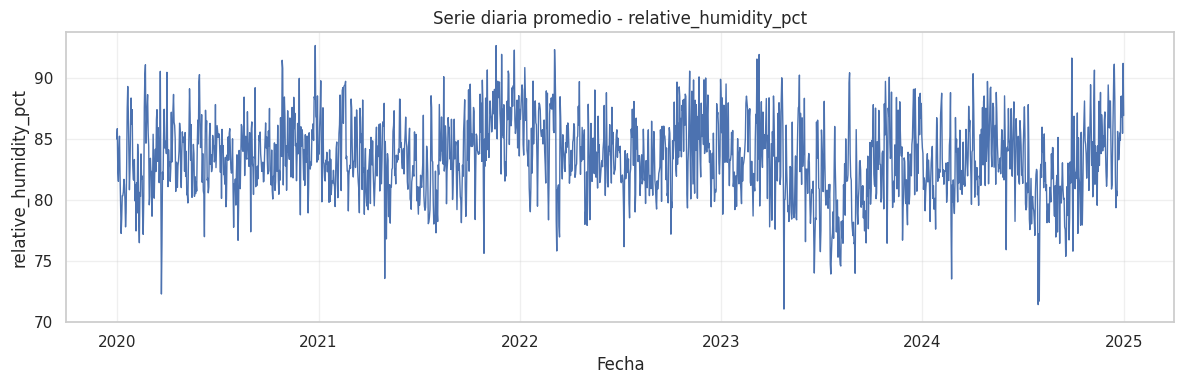

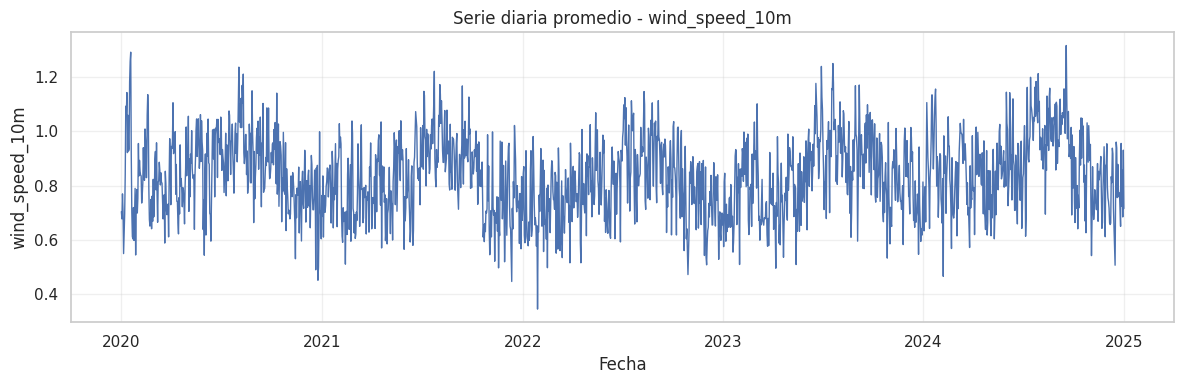

In [13]:
# ============================================================
# 06.2 Visualizaciones ERA5-Land
# ============================================================

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Disponibilidad mensual ERA5
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    era5_disponibilidad_mensual["mes"],
    era5_disponibilidad_mensual["n_registros"],
    marker="o",
    linewidth=1
)

ax.set_title("Disponibilidad mensual de registros ERA5-Land")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_era5_disponibilidad_mensual.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 2. Porcentaje de nulos por variable
# ------------------------------------------------------------

plot_df = df_calidad_era5.sort_values("porcentaje_nulos", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))

ax.barh(plot_df["variable"], plot_df["porcentaje_nulos"])

ax.set_title("Porcentaje de valores nulos por variable ERA5-Land")
ax.set_xlabel("Valores nulos (%)")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_era5_nulos_por_variable.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 3. Series temporales de variables meteorológicas principales
# ------------------------------------------------------------

variables_preferidas = [
    "temperature_2m_c",
    "dewpoint_2m_c",
    "relative_humidity_pct",
    "wind_speed_10m",
    "total_precipitation_mm",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m"
]

variables_plot = [v for v in variables_preferidas if v in df_era5.columns]

if len(variables_plot) == 0:
    variables_plot = cols_numericas_era5[:5]

print("Variables para series temporales:", variables_plot)

df_era5_daily = (
    df_era5
    .set_index(col_fecha_era5)[variables_plot]
    .resample("D")
    .mean()
    .reset_index()
)

for variable in variables_plot:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    ax.plot(
        df_era5_daily[col_fecha_era5],
        df_era5_daily[variable],
        linewidth=1
    )
    
    ax.set_title(f"Serie diaria promedio - {variable}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(variable)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"06_era5_serie_diaria_{variable}.png", dpi=300, bbox_inches="tight")
    plt.show()

### 06.3 Tabla resumen ERA5-Land para documentación

Se construye una tabla compacta con las variables meteorológicas principales, su disponibilidad y estadísticos descriptivos. Esta tabla resume la calidad y utilidad de ERA5-Land como fuente complementaria para la Situación 1.

In [14]:
# ============================================================
# 06.3 Tabla compacta ERA5-Land para informe
# ============================================================

variables_clave_era5 = [
    "temperature_2m_c",
    "dewpoint_2m_c",
    "relative_humidity_pct",
    "wind_speed_10m",
    "total_precipitation_mm"
]

variables_clave_era5 = [v for v in variables_clave_era5 if v in df_calidad_era5["variable"].values]

if len(variables_clave_era5) == 0:
    variables_clave_era5 = df_calidad_era5["variable"].head(6).tolist()

tabla_era5_informe = (
    df_calidad_era5
    .loc[df_calidad_era5["variable"].isin(variables_clave_era5)]
    .copy()
)

tabla_era5_informe = tabla_era5_informe[
    [
        "variable",
        "n_validos",
        "porcentaje_nulos",
        "media",
        "desviacion",
        "min",
        "mediana",
        "max"
    ]
]

for col in ["media", "desviacion", "min", "mediana", "max"]:
    tabla_era5_informe[col] = tabla_era5_informe[col].round(3)

display(tabla_era5_informe)

tabla_era5_informe.to_csv(
    TAB_DIR / "06_tabla_era5_informe.csv",
    index=False
)

,variable,n_validos,porcentaje_nulos,media,desviacion,min,mediana,max
0,temperature_2m_c,43848,0.0000,19.9630,2.2160,12.9140,19.4920,27.7310
1,dewpoint_2m_c,43848,0.0000,16.9660,1.1070,10.3230,17.0370,21.2310
2,relative_humidity_pct,43848,0.0000,83.3630,7.9490,46.8030,85.6190,98.8320
5,wind_speed_10m,43848,0.0000,0.8350,0.3580,0.0060,0.8140,2.5020


<!-- interpretacion-s1:era5 -->
**Interpretacion.** ERA5-Land aporta el contexto meteorologico horario. Temperatura, humedad, viento, presion y radiacion ayudan a explicar condiciones de dispersion o acumulacion de contaminantes, aunque no son mediciones directas de calidad del aire.

## 07. EDA MODIS MAIAC

### 07.1 Disponibilidad satelital MODIS/MAIAC AOD

En esta sección se analiza la disponibilidad del producto MODIS/MAIAC AOD utilizado como fuente satelital complementaria. 
A diferencia de DAGMA/SISAIRE, que corresponde a mediciones puntuales de contaminantes en estaciones terrestres, MODIS/MAIAC aporta observaciones satelitales asociadas a la carga de aerosoles en la atmósfera.

El objetivo de este análisis es verificar:

1. El rango temporal disponible.
2. La cantidad de observaciones válidas.
3. La presencia de columnas espaciales.
4. La calidad general de las variables numéricas.
5. La utilidad del AOD como fuente complementaria en el panel ambiental.

El AOD no representa directamente concentraciones de NO₂, SO₂ u O₃, pero permite incorporar una señal satelital relacionada con aerosoles atmosféricos y condiciones de material particulado, por lo que fortalece la consolidación multifuente de la Situación 1.

In [15]:
# ============================================================
# CELDA 07.1 — EDA MODIS/MAIAC AOD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

path_modis = Path(RUTAS["modis_maiac"])

print("Ruta MODIS/MAIAC:", path_modis)
print("Existe:", path_modis.exists())

df_modis = pd.read_parquet(path_modis)
df_modis.columns = [c.strip().lower() for c in df_modis.columns]

print("Shape MODIS/MAIAC:", df_modis.shape)
display(df_modis.head())
print("Columnas MODIS/MAIAC:")
print(df_modis.columns.tolist())


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def buscar_columna(cols, candidatos):
    """
    Busca columnas por coincidencia parcial.
    Útil para columnas temporales o variables generales.
    """
    for cand in candidatos:
        for c in cols:
            if cand in c.lower():
                return c
    return None


def buscar_columna_geo_estricta(cols, tipo="lat"):
    """
    Detección estricta de columnas espaciales para evitar falsos positivos.
    """
    cols_norm = [c.lower().strip() for c in cols]

    if tipo == "lat":
        candidatos_exactos = [
            "lat", "latitude", "latitud", "y", "coord_y", "lat_deg", "latitude_deg"
        ]
    else:
        candidatos_exactos = [
            "lon", "lng", "long", "longitude", "longitud", "x", "coord_x", "lon_deg", "longitude_deg"
        ]

    for original, norm in zip(cols, cols_norm):
        if norm in candidatos_exactos:
            return original

    for original, norm in zip(cols, cols_norm):
        if tipo == "lat":
            if (
                norm.startswith("lat_")
                or norm.endswith("_lat")
                or norm.startswith("latitude_")
                or norm.endswith("_latitude")
            ):
                return original
        else:
            if (
                norm.startswith("lon_")
                or norm.endswith("_lon")
                or norm.startswith("lng_")
                or norm.endswith("_lng")
                or norm.startswith("longitude_")
                or norm.endswith("_longitude")
            ):
                return original

    return None


# ------------------------------------------------------------
# Detección de columnas principales
# ------------------------------------------------------------

col_fecha_modis = buscar_columna(
    df_modis.columns,
    ["datetime", "fecha", "date", "timestamp", "time", "period", "dia", "day"]
)

col_lat_modis = buscar_columna_geo_estricta(df_modis.columns, tipo="lat")
col_lon_modis = buscar_columna_geo_estricta(df_modis.columns, tipo="lon")

# Posibles nombres para AOD
col_aod_modis = buscar_columna(
    df_modis.columns,
    ["aod", "aerosol", "optical_depth", "aerosol_optical_depth"]
)

print("Columna fecha MODIS:", col_fecha_modis)
print("Columna latitud MODIS:", col_lat_modis)
print("Columna longitud MODIS:", col_lon_modis)
print("Columna AOD MODIS:", col_aod_modis)

if col_fecha_modis is None:
    raise ValueError("No se encontró columna temporal en MODIS/MAIAC.")

df_modis[col_fecha_modis] = pd.to_datetime(df_modis[col_fecha_modis], errors="coerce")
df_modis["anio"] = df_modis[col_fecha_modis].dt.year
df_modis["mes"] = df_modis[col_fecha_modis].dt.to_period("M").astype(str)


# ------------------------------------------------------------
# Detectar variables numéricas
# ------------------------------------------------------------

cols_excluir = {
    col_fecha_modis,
    col_lat_modis,
    col_lon_modis,
    "anio",
    "mes"
}

cols_excluir = {c for c in cols_excluir if c is not None}

cols_numericas_modis = [
    c for c in df_modis.columns
    if c not in cols_excluir and pd.api.types.is_numeric_dtype(df_modis[c])
]

print("Variables numéricas MODIS detectadas:")
print(cols_numericas_modis)


# ------------------------------------------------------------
# Tipo de cobertura espacial
# ------------------------------------------------------------

if col_lat_modis is not None and col_lon_modis is not None:
    lat_min_modis = pd.to_numeric(df_modis[col_lat_modis], errors="coerce").min()
    lat_max_modis = pd.to_numeric(df_modis[col_lat_modis], errors="coerce").max()
    lon_min_modis = pd.to_numeric(df_modis[col_lon_modis], errors="coerce").min()
    lon_max_modis = pd.to_numeric(df_modis[col_lon_modis], errors="coerce").max()
    n_puntos_espaciales_modis = (
        df_modis[[col_lat_modis, col_lon_modis]]
        .dropna()
        .drop_duplicates()
        .shape[0]
    )
    tipo_cobertura_modis = "Observaciones con coordenadas explícitas en el archivo"
else:
    lat_min_modis = np.nan
    lat_max_modis = np.nan
    lon_min_modis = np.nan
    lon_max_modis = np.nan
    n_puntos_espaciales_modis = np.nan
    tipo_cobertura_modis = (
        "Archivo sin columnas explícitas de latitud/longitud; "
        "posiblemente agregado o preprocesado para el área de estudio"
    )

print("Tipo de cobertura MODIS:", tipo_cobertura_modis)


# ------------------------------------------------------------
# Resumen general MODIS/MAIAC
# ------------------------------------------------------------

resumen_modis_general = pd.DataFrame({
    "metrica": [
        "filas_totales",
        "columnas_totales",
        "variables_numericas",
        "fecha_min",
        "fecha_max",
        "anios_disponibles",
        "columna_aod_detectada",
        "lat_min",
        "lat_max",
        "lon_min",
        "lon_max",
        "puntos_espaciales_unicos",
        "tipo_cobertura"
    ],
    "valor": [
        len(df_modis),
        df_modis.shape[1],
        len(cols_numericas_modis),
        df_modis[col_fecha_modis].min(),
        df_modis[col_fecha_modis].max(),
        ", ".join(map(str, sorted(df_modis["anio"].dropna().unique().astype(int)))),
        col_aod_modis,
        lat_min_modis,
        lat_max_modis,
        lon_min_modis,
        lon_max_modis,
        n_puntos_espaciales_modis,
        tipo_cobertura_modis
    ]
})

display(resumen_modis_general)

resumen_modis_general.to_csv(
    TAB_DIR / "07_modis_resumen_general.csv",
    index=False
)


# ------------------------------------------------------------
# Calidad de variables numéricas MODIS
# ------------------------------------------------------------

calidad_modis = []

for col in cols_numericas_modis:
    serie = pd.to_numeric(df_modis[col], errors="coerce")

    calidad_modis.append({
        "variable": col,
        "n_registros": len(serie),
        "n_validos": serie.notna().sum(),
        "porcentaje_nulos": round(serie.isna().mean() * 100, 4),
        "media": serie.mean(),
        "desviacion": serie.std(),
        "min": serie.min(),
        "p25": serie.quantile(0.25),
        "mediana": serie.median(),
        "p75": serie.quantile(0.75),
        "max": serie.max()
    })

df_calidad_modis = pd.DataFrame(calidad_modis)

display(df_calidad_modis)

df_calidad_modis.to_csv(
    TAB_DIR / "07_modis_calidad_variables.csv",
    index=False
)


# ------------------------------------------------------------
# Disponibilidad temporal mensual MODIS
# ------------------------------------------------------------

modis_disponibilidad_mensual = (
    df_modis
    .groupby("mes")
    .agg(
        n_registros=(col_fecha_modis, "size")
    )
    .reset_index()
)

display(modis_disponibilidad_mensual.head())

modis_disponibilidad_mensual.to_csv(
    TAB_DIR / "07_modis_disponibilidad_mensual.csv",
    index=False
)


# ------------------------------------------------------------
# Guardar columnas detectadas
# ------------------------------------------------------------

cols_modis_detectadas = {
    "col_fecha": col_fecha_modis,
    "col_lat": col_lat_modis,
    "col_lon": col_lon_modis,
    "col_aod": col_aod_modis,
    "cols_numericas": cols_numericas_modis
}

with open(TAB_DIR / "07_modis_columnas_detectadas.json", "w", encoding="utf-8") as f:
    json.dump(cols_modis_detectadas, f, indent=4, ensure_ascii=False)


# ------------------------------------------------------------
# Resumen interpretativo rápido
# ------------------------------------------------------------

print("\nResumen interpretativo MODIS/MAIAC:")
print(f"- Registros: {len(df_modis):,}")
print(f"- Periodo: {df_modis[col_fecha_modis].min()} a {df_modis[col_fecha_modis].max()}")
print(f"- Años disponibles: {', '.join(map(str, sorted(df_modis['anio'].dropna().unique().astype(int))))}")
print(f"- Variables numéricas: {len(cols_numericas_modis)}")
print(f"- Columna AOD detectada: {col_aod_modis}")
print(f"- Cobertura espacial: {tipo_cobertura_modis}")

Ruta MODIS/MAIAC: /workspace/geovision-cali-hf/data/era5_modis/modis_maiac_aod_cali_daily_full_2020_2024.parquet
Existe: True
Shape MODIS/MAIAC: (1827, 17)


,aod_047_mean,aod_055_mean,date,n_observations,aod_disponible,year,month,dayofyear,month_sin,month_cos,doy_sin,doy_cos,aod_047_observado,aod_055_observado,aod_047_interp,aod_055_interp,aod_origen
0,0.3949,0.2861,2020-01-01,99,1,2020,1,1,0.5000,0.8660,0.0172,0.9999,0.3949,0.2861,0.3949,0.2861,observado_modis
1,0.4835,0.3514,2020-01-02,100,1,2020,1,2,0.5000,0.8660,0.0344,0.9994,0.4835,0.3514,0.4835,0.3514,observado_modis
2,0.2655,0.1916,2020-01-03,98,1,2020,1,3,0.5000,0.8660,0.0516,0.9987,0.2655,0.1916,0.2655,0.1916,observado_modis
3,0.3619,0.2620,2020-01-04,100,1,2020,1,4,0.5000,0.8660,0.0688,0.9976,0.3619,0.2620,0.3619,0.2620,observado_modis
4,0.3609,0.2613,2020-01-05,99,1,2020,1,5,0.5000,0.8660,0.0860,0.9963,0.3609,0.2613,0.3609,0.2613,observado_modis


Columnas MODIS/MAIAC:
['aod_047_mean', 'aod_055_mean', 'date', 'n_observations', 'aod_disponible', 'year', 'month', 'dayofyear', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'aod_047_observado', 'aod_055_observado', 'aod_047_interp', 'aod_055_interp', 'aod_origen']
Columna fecha MODIS: date
Columna latitud MODIS: None
Columna longitud MODIS: None
Columna AOD MODIS: aod_047_mean
Variables numéricas MODIS detectadas:
['aod_047_mean', 'aod_055_mean', 'n_observations', 'aod_disponible', 'year', 'month', 'dayofyear', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'aod_047_observado', 'aod_055_observado', 'aod_047_interp', 'aod_055_interp']
Tipo de cobertura MODIS: Archivo sin columnas explícitas de latitud/longitud; posiblemente agregado o preprocesado para el área de estudio


,metrica,valor
0,filas_totales,1827
1,columnas_totales,19
2,variables_numericas,15
3,fecha_min,2020-01-01 00:00:00
4,fecha_max,2024-12-31 00:00:00
5,anios_disponibles,"2020, 2021, 2022, 2023, 2024"
6,columna_aod_detectada,aod_047_mean
7,lat_min,NaN
8,lat_max,NaN
9,lon_min,NaN


,variable,n_registros,n_validos,porcentaje_nulos,media,desviacion,min,p25,mediana,p75,max
0,aod_047_mean,1827,1060,41.9814,0.3816,0.1297,0.0000,0.2924,0.3978,0.4794,0.8069
1,aod_055_mean,1827,1060,41.9814,0.2770,0.0949,0.0000,0.2112,0.2885,0.3484,0.5926
2,n_observations,1827,1827,0.0000,83.3443,29.7033,3.0000,67.0000,69.0000,99.0000,202.0000
3,aod_disponible,1827,1827,0.0000,0.5802,0.4937,0.0000,0.0000,1.0000,1.0000,1.0000
4,year,1827,1827,0.0000,"2,022.0000",1.4154,"2,020.0000","2,021.0000","2,022.0000","2,023.0000","2,024.0000"
5,month,1827,1827,0.0000,6.5211,3.4502,1.0000,4.0000,7.0000,10.0000,12.0000
6,dayofyear,1827,1827,0.0000,183.2003,105.5109,1.0000,92.0000,183.0000,274.5000,366.0000
7,month_sin,1827,1827,0.0000,-0.0044,0.7060,-1.0000,-0.8660,-0.0000,0.5000,1.0000
8,month_cos,1827,1827,0.0000,-0.0018,0.7086,-1.0000,-0.8660,-0.0000,0.8660,1.0000
9,doy_sin,1827,1827,0.0000,0.0000,0.7069,-1.0000,-0.7056,0.0000,0.7056,1.0000


,mes,n_registros
0,2020-01,31
1,2020-02,29
2,2020-03,31
3,2020-04,30
4,2020-05,31



Resumen interpretativo MODIS/MAIAC:
- Registros: 1,827
- Periodo: 2020-01-01 00:00:00 a 2024-12-31 00:00:00
- Años disponibles: 2020, 2021, 2022, 2023, 2024
- Variables numéricas: 15
- Columna AOD detectada: aod_047_mean
- Cobertura espacial: Archivo sin columnas explícitas de latitud/longitud; posiblemente agregado o preprocesado para el área de estudio


### 07.2 Visualizaciones MODIS/MAIAC AOD

Las siguientes visualizaciones resumen la disponibilidad temporal, calidad de variables y comportamiento general del AOD. 
Estas figuras permiten evaluar si MODIS/MAIAC aporta una señal satelital útil y suficientemente continua para complementar las mediciones terrestres de DAGMA/SISAIRE.

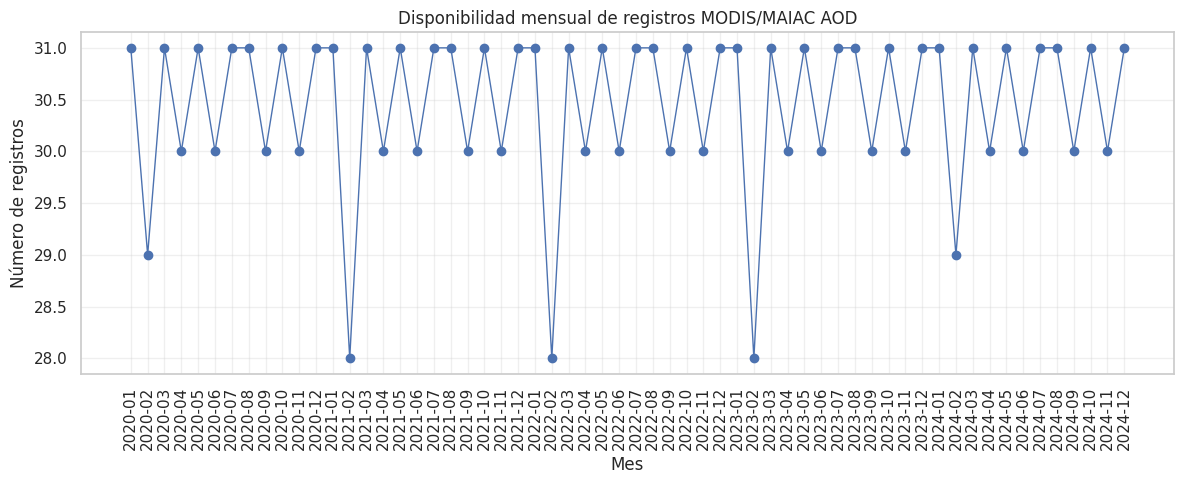

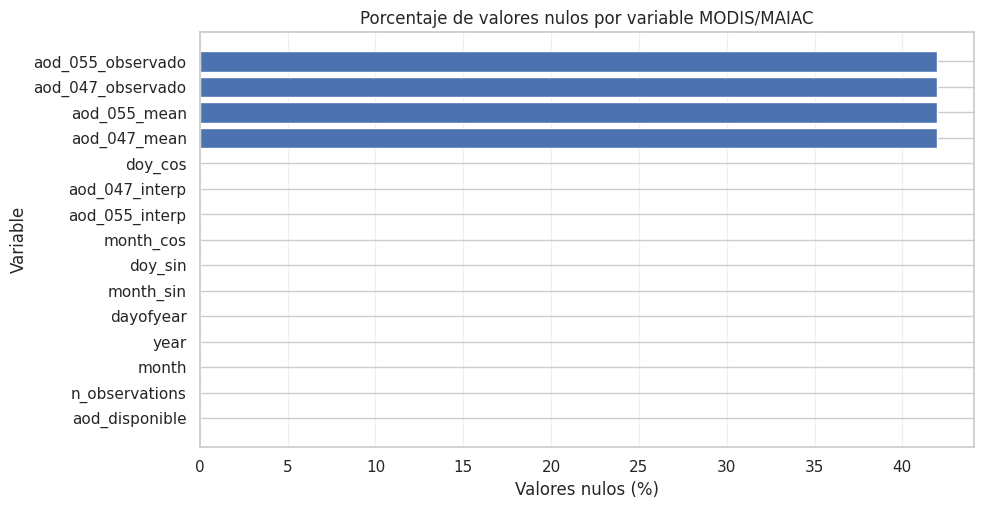

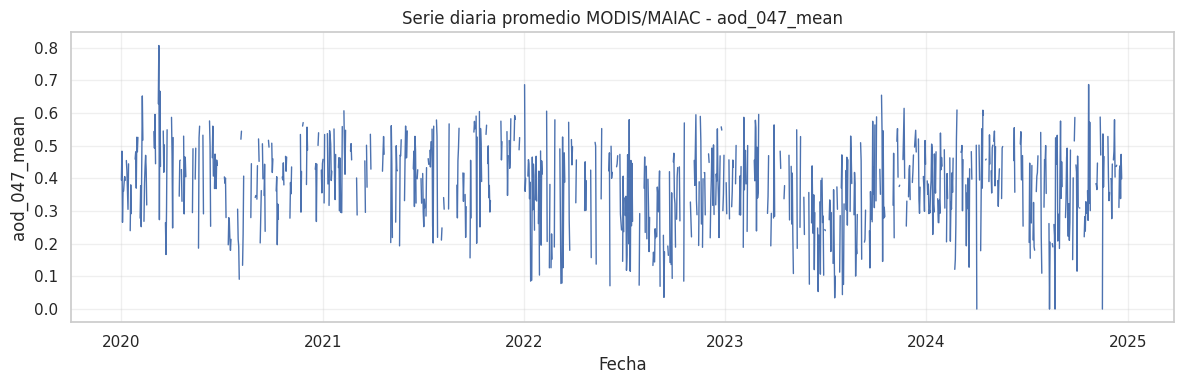

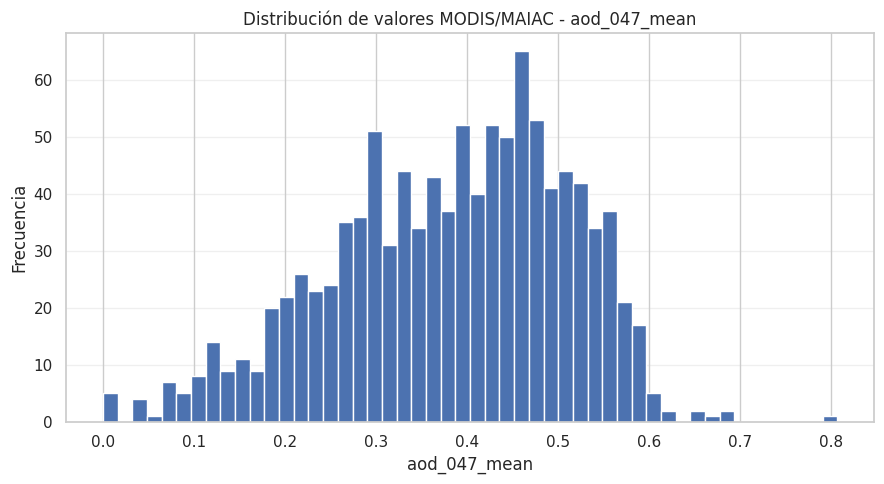

,origen,dias,porcentaje
0,observado_modis,1060,58.0200
1,interpolado_temporal,767,41.9800


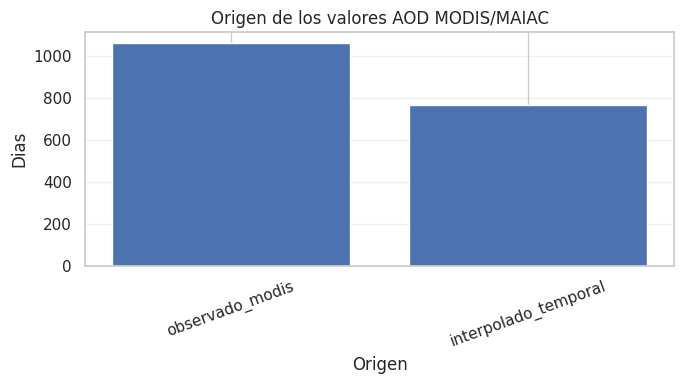

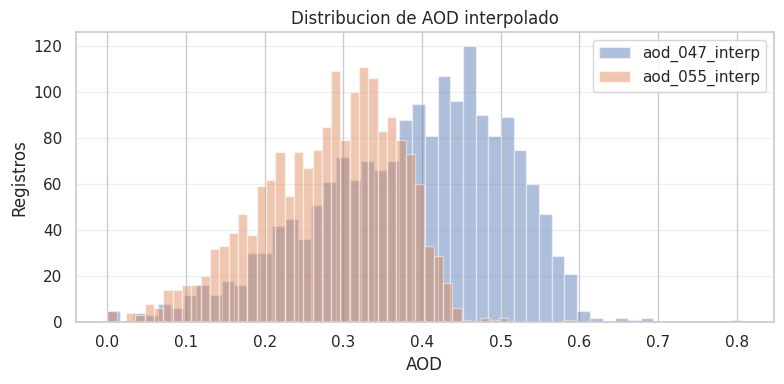

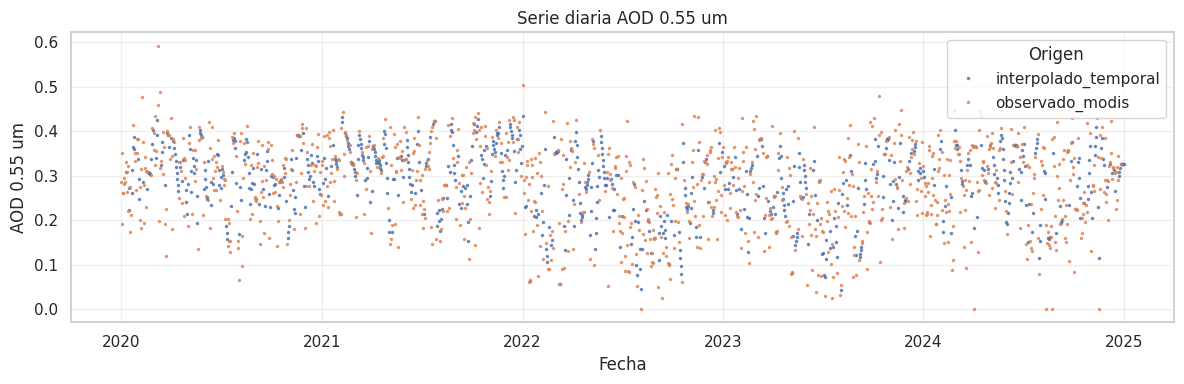

In [16]:
# ============================================================
# CELDA 07.2 — Visualizaciones MODIS/MAIAC AOD
# ============================================================

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Disponibilidad mensual MODIS
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    modis_disponibilidad_mensual["mes"],
    modis_disponibilidad_mensual["n_registros"],
    marker="o",
    linewidth=1
)

ax.set_title("Disponibilidad mensual de registros MODIS/MAIAC AOD")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07_modis_disponibilidad_mensual.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 2. Porcentaje de nulos por variable MODIS
# ------------------------------------------------------------

if len(df_calidad_modis) > 0:
    plot_df = df_calidad_modis.sort_values("porcentaje_nulos", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))

    ax.barh(plot_df["variable"], plot_df["porcentaje_nulos"])

    ax.set_title("Porcentaje de valores nulos por variable MODIS/MAIAC")
    ax.set_xlabel("Valores nulos (%)")
    ax.set_ylabel("Variable")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_modis_nulos_por_variable.png", dpi=300, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# 3. Serie temporal AOD
# ------------------------------------------------------------

if col_aod_modis is not None:
    df_modis_daily = (
        df_modis
        .set_index(col_fecha_modis)[[col_aod_modis]]
        .resample("D")
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        df_modis_daily[col_fecha_modis],
        df_modis_daily[col_aod_modis],
        linewidth=1
    )

    ax.set_title(f"Serie diaria promedio MODIS/MAIAC - {col_aod_modis}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(col_aod_modis)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_modis_serie_diaria_aod.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("No se detectó una columna AOD. Revisa columnas disponibles en df_modis.columns.")


# ------------------------------------------------------------
# 4. Histograma de AOD
# ------------------------------------------------------------

if col_aod_modis is not None:
    serie_aod = pd.to_numeric(df_modis[col_aod_modis], errors="coerce").dropna()

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.hist(serie_aod, bins=50)

    ax.set_title(f"Distribución de valores MODIS/MAIAC - {col_aod_modis}")
    ax.set_xlabel(col_aod_modis)
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_modis_histograma_aod.png", dpi=300, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# 5. Origen de valores AOD: observado vs interpolado
# ------------------------------------------------------------

if "aod_origen" in df_modis.columns:
    conteo_origen_aod = (
        df_modis["aod_origen"]
        .value_counts(dropna=False)
        .rename_axis("origen")
        .reset_index(name="dias")
    )
    conteo_origen_aod["porcentaje"] = (
        100 * conteo_origen_aod["dias"] / conteo_origen_aod["dias"].sum()
    ).round(2)

    display(conteo_origen_aod)
    conteo_origen_aod.to_csv(TAB_DIR / "07_modis_origen_valores_aod.csv", index=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(conteo_origen_aod["origen"], conteo_origen_aod["dias"])
    ax.set_title("Origen de los valores AOD MODIS/MAIAC")
    ax.set_xlabel("Origen")
    ax.set_ylabel("Dias")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_modis_origen_valores_aod.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No se encontro la columna aod_origen para separar valores observados e interpolados.")


# ------------------------------------------------------------
# 6. Distribucion de AOD interpolado
# ------------------------------------------------------------

columnas_aod_interp = [c for c in ["aod_047_interp", "aod_055_interp"] if c in df_modis.columns]

if len(columnas_aod_interp) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))

    for col in columnas_aod_interp:
        serie = pd.to_numeric(df_modis[col], errors="coerce").dropna()
        ax.hist(serie, bins=50, alpha=0.45, label=col)

    ax.set_title("Distribucion de AOD interpolado")
    ax.set_xlabel("AOD")
    ax.set_ylabel("Registros")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_modis_distribucion_aod_interpolado.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No se encontraron columnas aod_047_interp o aod_055_interp para graficar la distribucion interpolada.")


# ------------------------------------------------------------
# 7. Serie diaria AOD 0.55 um por origen
# ------------------------------------------------------------

if {"aod_055_interp", "aod_origen"}.issubset(df_modis.columns):
    df_serie_aod_055 = df_modis[[col_fecha_modis, "aod_055_interp", "aod_origen"]].copy()
    df_serie_aod_055["aod_055_interp"] = pd.to_numeric(df_serie_aod_055["aod_055_interp"], errors="coerce")
    df_serie_aod_055 = df_serie_aod_055.dropna(subset=[col_fecha_modis, "aod_055_interp"])

    fig, ax = plt.subplots(figsize=(12, 4))

    for origen, grupo in df_serie_aod_055.groupby("aod_origen"):
        ax.plot(
            grupo[col_fecha_modis],
            grupo["aod_055_interp"],
            linestyle="none",
            marker=".",
            markersize=3,
            alpha=0.75,
            label=origen
        )

    ax.set_title("Serie diaria AOD 0.55 um")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("AOD 0.55 um")
    ax.legend(title="Origen")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_modis_serie_diaria_aod_055_origen.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No se encontraron aod_055_interp y aod_origen para graficar la serie diaria AOD 0.55 um.")

### 07.3 Tabla resumen MODIS/MAIAC para documentación

Se construye una tabla compacta para documentar la disponibilidad y calidad del AOD satelital. Esta tabla será utilizada en la Situación 1 para justificar el papel de MODIS/MAIAC como fuente complementaria de aerosoles.

In [17]:
# ============================================================
# CELDA 07.3 — Tabla compacta MODIS/MAIAC para informe
# ============================================================

if col_aod_modis is not None and col_aod_modis in df_calidad_modis["variable"].values:
    tabla_modis_informe = (
        df_calidad_modis
        .loc[df_calidad_modis["variable"] == col_aod_modis]
        .copy()
    )
else:
    # Si no detecta AOD, deja las primeras variables numéricas como tabla diagnóstica
    tabla_modis_informe = df_calidad_modis.head(5).copy()

tabla_modis_informe = tabla_modis_informe[
    [
        "variable",
        "n_validos",
        "porcentaje_nulos",
        "media",
        "desviacion",
        "min",
        "mediana",
        "max"
    ]
]

for col in ["media", "desviacion", "min", "mediana", "max"]:
    tabla_modis_informe[col] = tabla_modis_informe[col].round(4)

display(tabla_modis_informe)

tabla_modis_informe.to_csv(
    TAB_DIR / "07_tabla_modis_informe.csv",
    index=False
)

,variable,n_validos,porcentaje_nulos,media,desviacion,min,mediana,max
0,aod_047_mean,1060,41.9814,0.3816,0.1297,0.0000,0.3978,0.8069


### 07.4 Verificación de imágenes MODIS/MAIAC utilizadas

Además del archivo tabular consolidado de MODIS/MAIAC, se verifica la existencia de las imágenes o rasters satelitales utilizados durante el procesamiento. 
Esta auditoría permite documentar cuántos archivos fuente fueron considerados, qué formatos tienen, qué rango temporal cubren y si presentan inconsistencias básicas de disponibilidad.

Esta verificación es importante para la Situación 1 porque aporta trazabilidad entre las imágenes satelitales originales y la tabla final utilizada en el EDA consolidado.

In [18]:
# ============================================================
# CELDA 07.4 — Verificación de imágenes MODIS/MAIAC usadas
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import os

# ------------------------------------------------------------
# 1. Posibles carpetas donde pueden estar las imágenes MODIS
# ------------------------------------------------------------

posibles_dirs_modis = []

# Si tienes una ruta explícita en RUTAS, la usamos
for key in [
    "modis_raw",
    "modis_tif",
    "modis_images",
    "modis_maiac_raw",
    "modis_maiac_tif",
    "modis_maiac_images"
]:
    if key in RUTAS:
        posibles_dirs_modis.append(Path(RUTAS[key]))

# También buscamos carpetas probables cerca del archivo consolidado
path_modis_parent = Path(RUTAS["modis_maiac"]).parent

posibles_dirs_modis.extend([
    path_modis_parent,
    path_modis_parent / "raw",
    path_modis_parent / "tif",
    path_modis_parent / "tiffs",
    path_modis_parent / "geotiff",
    path_modis_parent / "geotiffs",
    path_modis_parent / "images",
    path_modis_parent / "modis",
    path_modis_parent / "modis_raw",
    path_modis_parent / "modis_tif",
    path_modis_parent / "modis_maiac",
    Path("/workspace/geovision-cali-hf/data"),
    Path("/workspace/geovision-cali-hf/data/era5_modis"),
])

# Quitar duplicados preservando orden
posibles_dirs_modis = list(dict.fromkeys([p for p in posibles_dirs_modis]))

print("Carpetas candidatas para imágenes MODIS/MAIAC:")
for p in posibles_dirs_modis:
    print("-", p, "| existe:", p.exists())


# ------------------------------------------------------------
# 2. Buscar archivos tipo imagen/raster
# ------------------------------------------------------------

extensiones_raster = [
    "*.tif", "*.tiff", "*.TIF", "*.TIFF",
    "*.hdf", "*.HDF",
    "*.nc", "*.NC",
    "*.jp2", "*.JP2",
    "*.png", "*.PNG",
    "*.jpg", "*.jpeg", "*.JPG", "*.JPEG"
]

archivos_modis = []

for carpeta in posibles_dirs_modis:
    if carpeta.exists() and carpeta.is_dir():
        for patron in extensiones_raster:
            archivos_modis.extend(list(carpeta.rglob(patron)))

# Filtrar por nombres que parezcan MODIS/MAIAC/AOD, pero sin eliminar todo si no coincide
keywords_modis = ["modis", "maiac", "aod", "aerosol", "mcd19", "mcd19a2", "terra", "aqua"]

archivos_filtrados = [
    p for p in archivos_modis
    if any(k in p.name.lower() or k in str(p.parent).lower() for k in keywords_modis)
]

if len(archivos_filtrados) > 0:
    archivos_modis = archivos_filtrados

# Quitar duplicados
archivos_modis = sorted(list(set(archivos_modis)))

print(f"\nArchivos raster/imagen MODIS encontrados: {len(archivos_modis)}")


# ------------------------------------------------------------
# 3. Función para inferir fecha desde nombre de archivo
# ------------------------------------------------------------

def inferir_fecha_modis(nombre):
    """
    Intenta inferir fecha desde patrones frecuentes:
    - YYYY-MM-DD
    - YYYY_MM_DD
    - YYYYMMDD
    - AYYYYDDD, típico MODIS día juliano
    """
    nombre = str(nombre)

    # YYYY-MM-DD o YYYY_MM_DD
    m = re.search(r"(20\d{2})[-_](\d{2})[-_](\d{2})", nombre)
    if m:
        return pd.to_datetime(f"{m.group(1)}-{m.group(2)}-{m.group(3)}", errors="coerce")

    # YYYYMMDD
    m = re.search(r"(20\d{2})(\d{2})(\d{2})", nombre)
    if m:
        return pd.to_datetime(f"{m.group(1)}-{m.group(2)}-{m.group(3)}", errors="coerce")

    # AYYYYDDD, día juliano MODIS
    m = re.search(r"A(20\d{2})(\d{3})", nombre, flags=re.IGNORECASE)
    if m:
        year = int(m.group(1))
        doy = int(m.group(2))
        return pd.to_datetime(f"{year}-01-01") + pd.to_timedelta(doy - 1, unit="D")

    return pd.NaT


# ------------------------------------------------------------
# 4. Inventario de imágenes
# ------------------------------------------------------------

inventario_imagenes_modis = []

for p in archivos_modis:
    try:
        stat = p.stat()
        size_mb = stat.st_size / (1024**2)
        fecha_inferida = inferir_fecha_modis(p.name)

        inventario_imagenes_modis.append({
            "archivo": p.name,
            "ruta": str(p),
            "extension": p.suffix.lower(),
            "size_mb": round(size_mb, 3),
            "fecha_inferida": fecha_inferida,
            "carpeta_padre": str(p.parent),
            "modificado": pd.to_datetime(stat.st_mtime, unit="s")
        })
    except Exception as e:
        inventario_imagenes_modis.append({
            "archivo": p.name,
            "ruta": str(p),
            "extension": p.suffix.lower(),
            "size_mb": np.nan,
            "fecha_inferida": pd.NaT,
            "carpeta_padre": str(p.parent),
            "modificado": pd.NaT,
            "error": str(e)
        })

df_inventario_imagenes_modis = pd.DataFrame(inventario_imagenes_modis)

if len(df_inventario_imagenes_modis) > 0:
    df_inventario_imagenes_modis["fecha_inferida"] = pd.to_datetime(
        df_inventario_imagenes_modis["fecha_inferida"],
        errors="coerce"
    )
    
    df_inventario_imagenes_modis["anio"] = df_inventario_imagenes_modis["fecha_inferida"].dt.year
    df_inventario_imagenes_modis["mes"] = df_inventario_imagenes_modis["fecha_inferida"].dt.to_period("M").astype(str)

display(df_inventario_imagenes_modis.head(20))


# ------------------------------------------------------------
# 5. Resumen de imágenes usadas
# ------------------------------------------------------------

if len(df_inventario_imagenes_modis) > 0:
    resumen_imagenes_modis = pd.DataFrame({
        "metrica": [
            "n_archivos_imagen_raster",
            "formatos_detectados",
            "tamano_total_mb",
            "tamano_promedio_mb",
            "fecha_min_inferida",
            "fecha_max_inferida",
            "archivos_con_fecha_inferida",
            "archivos_sin_fecha_inferida",
            "carpetas_unicas"
        ],
        "valor": [
            len(df_inventario_imagenes_modis),
            ", ".join(sorted(df_inventario_imagenes_modis["extension"].dropna().unique())),
            round(df_inventario_imagenes_modis["size_mb"].sum(), 3),
            round(df_inventario_imagenes_modis["size_mb"].mean(), 3),
            df_inventario_imagenes_modis["fecha_inferida"].min(),
            df_inventario_imagenes_modis["fecha_inferida"].max(),
            df_inventario_imagenes_modis["fecha_inferida"].notna().sum(),
            df_inventario_imagenes_modis["fecha_inferida"].isna().sum(),
            df_inventario_imagenes_modis["carpeta_padre"].nunique()
        ]
    })
else:
    resumen_imagenes_modis = pd.DataFrame({
        "metrica": [
            "n_archivos_imagen_raster",
            "observacion"
        ],
        "valor": [
            0,
            "No se encontraron imágenes/raster MODIS en las carpetas candidatas. Verificar ruta raw/tif."
        ]
    })

display(resumen_imagenes_modis)

# Guardar salidas
df_inventario_imagenes_modis.to_csv(
    TAB_DIR / "07B_inventario_imagenes_modis.csv",
    index=False
)

resumen_imagenes_modis.to_csv(
    TAB_DIR / "07B_resumen_imagenes_modis.csv",
    index=False
)

print("Inventario guardado en:", TAB_DIR / "07B_inventario_imagenes_modis.csv")
print("Resumen guardado en:", TAB_DIR / "07B_resumen_imagenes_modis.csv")

Carpetas candidatas para imágenes MODIS/MAIAC:
- /workspace/geovision-cali-hf/data/era5_modis | existe: True
- /workspace/geovision-cali-hf/data/era5_modis/raw | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/tif | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/tiffs | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/geotiff | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/geotiffs | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/images | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/modis | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/modis_raw | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/modis_tif | existe: False
- /workspace/geovision-cali-hf/data/era5_modis/modis_maiac | existe: False
- /workspace/geovision-cali-hf/data | existe: True



Archivos raster/imagen MODIS encontrados: 1120


,archivo,ruta,extension,size_mb,fecha_inferida,carpeta_padre,modificado,anio,mes
0,era5_land_cali_2020_01.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2240,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:54,NaN,NaN
1,era5_land_cali_2020_02.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2180,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:54,NaN,NaN
2,era5_land_cali_2020_03.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2250,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:53,NaN,NaN
3,era5_land_cali_2020_04.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2210,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:53,NaN,NaN
4,era5_land_cali_2020_05.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2250,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:53,NaN,NaN
5,era5_land_cali_2020_06.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2210,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:53,NaN,NaN
6,era5_land_cali_2020_07.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2260,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:53,NaN,NaN
7,era5_land_cali_2020_08.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2250,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:54,NaN,NaN
8,era5_land_cali_2020_09.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2210,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:54,NaN,NaN
9,era5_land_cali_2020_10.nc,/workspace/geovision-cali-hf/data/era5_modis/e...,.nc,0.2260,NaT,/workspace/geovision-cali-hf/data/era5_modis/e...,2026-05-22 03:42:54,NaN,NaN


,metrica,valor
0,n_archivos_imagen_raster,1120
1,formatos_detectados,".nc, .tif"
2,tamano_total_mb,16.4010
3,tamano_promedio_mb,0.0150
4,fecha_min_inferida,2020-01-01 00:00:00
5,fecha_max_inferida,2024-12-25 00:00:00
6,archivos_con_fecha_inferida,1060
7,archivos_sin_fecha_inferida,60
8,carpetas_unicas,2


Inventario guardado en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas/07B_inventario_imagenes_modis.csv
Resumen guardado en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas/07B_resumen_imagenes_modis.csv


### 07.5 Cobertura temporal de imágenes MODIS/MAIAC

Con base en las fechas inferidas desde los nombres de archivo, se resume la disponibilidad mensual de imágenes MODIS/MAIAC. 
Esta verificación permite identificar si la fuente satelital tiene continuidad temporal o si existen meses con baja disponibilidad de imágenes.

,mes,n_imagenes,tamano_total_mb
0,2020-01,23,0.0790
1,2020-02,16,0.0610
2,2020-03,20,0.0630
3,2020-04,15,0.0430
4,2020-05,15,0.0370


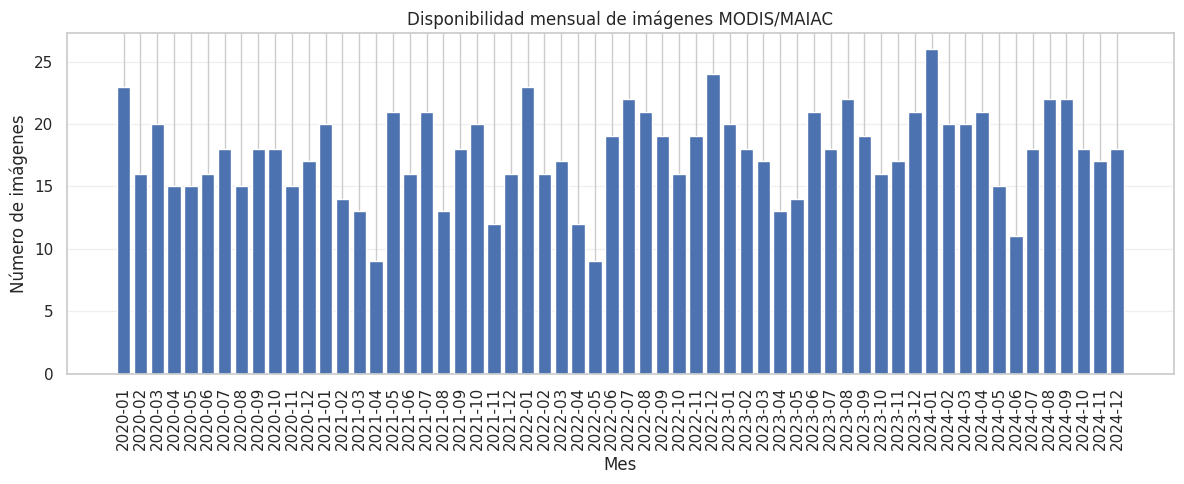

In [19]:
# ============================================================
# CELDA 07.5 — Cobertura temporal de imágenes MODIS/MAIAC
# ============================================================

import matplotlib.pyplot as plt

if len(df_inventario_imagenes_modis) > 0 and df_inventario_imagenes_modis["fecha_inferida"].notna().any():

    disponibilidad_imagenes_modis_mensual = (
        df_inventario_imagenes_modis
        .dropna(subset=["fecha_inferida"])
        .groupby("mes")
        .agg(
            n_imagenes=("archivo", "count"),
            tamano_total_mb=("size_mb", "sum")
        )
        .reset_index()
    )

    display(disponibilidad_imagenes_modis_mensual.head())

    disponibilidad_imagenes_modis_mensual.to_csv(
        TAB_DIR / "07B_disponibilidad_mensual_imagenes_modis.csv",
        index=False
    )

    FIG_DIR.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(
        disponibilidad_imagenes_modis_mensual["mes"],
        disponibilidad_imagenes_modis_mensual["n_imagenes"]
    )

    ax.set_title("Disponibilidad mensual de imágenes MODIS/MAIAC")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Número de imágenes")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "07B_disponibilidad_mensual_imagenes_modis.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

else:
    print("No hay fechas inferidas suficientes para construir disponibilidad mensual de imágenes.")

### 07.6 Validación técnica de rasters MODIS/MAIAC

Cuando existen archivos GeoTIFF, se realiza una validación técnica básica de los rasters: dimensiones, CRS, bounds, número de bandas y presencia de nodata. 
Esta revisión permite verificar que las imágenes fuente son legibles y contienen información espacial útil.

In [20]:
# ============================================================
# CELDA 07.6 — Validación técnica de rasters MODIS/MAIAC
# ============================================================

try:
    import rasterio
    HAS_RASTERIO = True
except Exception as e:
    HAS_RASTERIO = False
    print("rasterio no está instalado o no se pudo importar:", e)

resumen_rasters_modis = []

if HAS_RASTERIO and len(df_inventario_imagenes_modis) > 0:
    
    archivos_tif = df_inventario_imagenes_modis[
        df_inventario_imagenes_modis["extension"].isin([".tif", ".tiff"])
    ]["ruta"].tolist()

    print("GeoTIFF encontrados:", len(archivos_tif))

    # Para no demorar, validamos máximo 50. Puedes subirlo si quieres.
    archivos_tif_sample = archivos_tif[:50]

    for ruta in archivos_tif_sample:
        try:
            with rasterio.open(ruta) as src:
                bounds = src.bounds

                resumen_rasters_modis.append({
                    "archivo": Path(ruta).name,
                    "ruta": ruta,
                    "crs": str(src.crs),
                    "width": src.width,
                    "height": src.height,
                    "count_bands": src.count,
                    "nodata": src.nodata,
                    "bounds_left": bounds.left,
                    "bounds_bottom": bounds.bottom,
                    "bounds_right": bounds.right,
                    "bounds_top": bounds.top,
                    "res_x": src.res[0],
                    "res_y": src.res[1],
                    "legible": True
                })

        except Exception as e:
            resumen_rasters_modis.append({
                "archivo": Path(ruta).name,
                "ruta": ruta,
                "crs": None,
                "width": np.nan,
                "height": np.nan,
                "count_bands": np.nan,
                "nodata": np.nan,
                "bounds_left": np.nan,
                "bounds_bottom": np.nan,
                "bounds_right": np.nan,
                "bounds_top": np.nan,
                "res_x": np.nan,
                "res_y": np.nan,
                "legible": False,
                "error": str(e)
            })

df_resumen_rasters_modis = pd.DataFrame(resumen_rasters_modis)

if len(df_resumen_rasters_modis) > 0:
    display(df_resumen_rasters_modis.head())

    df_resumen_rasters_modis.to_csv(
        TAB_DIR / "07B_validacion_tecnica_rasters_modis.csv",
        index=False
    )

    resumen_tecnico_rasters_modis = pd.DataFrame({
        "metrica": [
            "rasters_validados",
            "rasters_legibles",
            "crs_detectados",
            "anchos_unicos",
            "altos_unicos",
            "bandas_unicas"
        ],
        "valor": [
            len(df_resumen_rasters_modis),
            int(df_resumen_rasters_modis["legible"].sum()),
            ", ".join(df_resumen_rasters_modis["crs"].dropna().astype(str).unique()),
            ", ".join(map(str, sorted(df_resumen_rasters_modis["width"].dropna().unique()))),
            ", ".join(map(str, sorted(df_resumen_rasters_modis["height"].dropna().unique()))),
            ", ".join(map(str, sorted(df_resumen_rasters_modis["count_bands"].dropna().unique())))
        ]
    })

    display(resumen_tecnico_rasters_modis)

    resumen_tecnico_rasters_modis.to_csv(
        TAB_DIR / "07B_resumen_tecnico_rasters_modis.csv",
        index=False
    )

else:
    print("No se validaron rasters. Puede que no existan GeoTIFF o que rasterio no esté disponible.")

rasterio no está instalado o no se pudo importar: No module named 'rasterio'
No se validaron rasters. Puede que no existan GeoTIFF o que rasterio no esté disponible.


### 07.7 Previsualización de una imagen MODIS/MAIAC

Para complementar la validación técnica, se visualiza una imagen MODIS/MAIAC AOD representativa. 
Esta previsualización permite verificar visualmente la estructura espacial del raster, sus bandas, valores válidos y extensión geográfica aproximada sobre el área de estudio.

In [21]:
# ============================================================
# CELDA 07.7 — Previsualización de una imagen MODIS/MAIAC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import rasterio
    HAS_RASTERIO = True
except Exception as e:
    HAS_RASTERIO = False
    print("rasterio no está disponible:", e)

if not HAS_RASTERIO:
    diagnostico_modis_preview = pd.DataFrame([{
        "componente": "preview_modis_maiac_geotiff",
        "estado": "omitido",
        "motivo": "rasterio no esta instalado en el entorno de ejecucion",
        "impacto": "No afecta KPIs ni trazabilidad; solo omite la previsualizacion GeoTIFF opcional."
    }])
    diagnostico_modis_preview.to_csv(
        TAB_DIR / "07E_preview_modis_geotiff_omitido.csv",
        index=False
    )
    display(diagnostico_modis_preview)
else:
    # ------------------------------------------------------------
    # 1. Seleccionar una imagen MODIS/MAIAC
    # ------------------------------------------------------------

    if "df_inventario_imagenes_modis" not in globals():
        raise ValueError("Primero debes correr la celda 07.1B para crear df_inventario_imagenes_modis.")

    archivos_tif = df_inventario_imagenes_modis[
        df_inventario_imagenes_modis["extension"].isin([".tif", ".tiff"])
    ].copy()

    if len(archivos_tif) == 0:
        raise ValueError("No se encontraron archivos .tif/.tiff para previsualizar.")

    # Elegimos una imagen cercana al centro del inventario para evitar escoger siempre la primera
    archivo_preview = archivos_tif.sort_values("fecha_inferida").iloc[len(archivos_tif) // 2]["ruta"]

    print("Raster seleccionado para previsualización:")
    print(archivo_preview)

    # ------------------------------------------------------------
    # 2. Leer raster
    # ------------------------------------------------------------

    with rasterio.open(archivo_preview) as src:
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Resolución:", src.res)
        print("Dimensiones:", src.width, "x", src.height)
        print("Bandas:", src.count)
        print("Nodata:", src.nodata)
    
        # Leer primera banda
        band1 = src.read(1).astype(float)
    
        # Leer segunda banda si existe
        band2 = src.read(2).astype(float) if src.count >= 2 else None
    
        nodata = src.nodata
        bounds = src.bounds

    # ------------------------------------------------------------
    # 3. Manejo de nodata
    # ------------------------------------------------------------

    if nodata is not None:
        band1[band1 == nodata] = np.nan
        if band2 is not None:
            band2[band2 == nodata] = np.nan

    # También remover valores no plausibles si existen
    band1 = np.where(np.isfinite(band1), band1, np.nan)

    if band2 is not None:
        band2 = np.where(np.isfinite(band2), band2, np.nan)

    print("Banda 1 - min:", np.nanmin(band1), "max:", np.nanmax(band1), "media:", np.nanmean(band1))

    if band2 is not None:
        print("Banda 2 - min:", np.nanmin(band2), "max:", np.nanmax(band2), "media:", np.nanmean(band2))

    # ------------------------------------------------------------
    # 4. Visualización banda 1
    # ------------------------------------------------------------

    FIG_DIR.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 7))

    im = ax.imshow(
        band1,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin="upper"
    )

    ax.set_title("Previsualización MODIS/MAIAC AOD - Banda 1")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Valor raster")

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "07E_preview_modis_maiac_banda1.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # ------------------------------------------------------------
    # 5. Visualización banda 2, si existe
    # ------------------------------------------------------------

    if band2 is not None:
        fig, ax = plt.subplots(figsize=(7, 7))

        im = ax.imshow(
            band2,
            extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
            origin="upper"
        )

        ax.set_title("Previsualización MODIS/MAIAC AOD - Banda 2")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Valor raster")

        plt.tight_layout()
        plt.savefig(
            FIG_DIR / "07E_preview_modis_maiac_banda2.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

    # ------------------------------------------------------------
    # 6. Guardar metadatos del raster visualizado
    # ------------------------------------------------------------

    preview_modis_metadata = pd.DataFrame({
        "metrica": [
            "archivo",
            "crs",
            "bounds_left",
            "bounds_bottom",
            "bounds_right",
            "bounds_top",
            "width",
            "height",
            "bandas",
            "nodata",
            "band1_min",
            "band1_max",
            "band1_mean",
            "band2_min",
            "band2_max",
            "band2_mean"
        ],
        "valor": [
            Path(archivo_preview).name,
            str(src.crs),
            bounds.left,
            bounds.bottom,
            bounds.right,
            bounds.top,
            src.width,
            src.height,
            src.count,
            nodata,
            np.nanmin(band1),
            np.nanmax(band1),
            np.nanmean(band1),
            np.nanmin(band2) if band2 is not None else np.nan,
            np.nanmax(band2) if band2 is not None else np.nan,
            np.nanmean(band2) if band2 is not None else np.nan
        ]
    })

    display(preview_modis_metadata)

    preview_modis_metadata.to_csv(
        TAB_DIR / "07E_preview_modis_metadata.csv",
        index=False
    )

    print("Figura guardada en:", FIG_DIR / "07E_preview_modis_maiac_banda1.png")
    if band2 is not None:
        print("Figura guardada en:", FIG_DIR / "07E_preview_modis_maiac_banda2.png")
    print("Metadatos guardados en:", TAB_DIR / "07E_preview_modis_metadata.csv")

rasterio no está disponible: No module named 'rasterio'


,componente,estado,motivo,impacto
0,preview_modis_maiac_geotiff,omitido,rasterio no esta instalado en el entorno de ej...,No afecta KPIs ni trazabilidad; solo omite la ...


<!-- interpretacion-s1:modis -->
**Interpretacion.** MODIS MAIAC aporta informacion de aerosoles mediante AOD. Esta variable complementa las mediciones de gases porque describe carga de particulas en la atmosfera, aunque su disponibilidad puede verse afectada por nubosidad y cobertura del sensor. El panel conserva dos lecturas: AOD observado y AOD interpolado. La version observada muestra la disponibilidad real del sensor; la interpolada completa la serie diaria para integrarla al panel horario. En el archivo MODIS hay 1.060 dias observados (58,02%) y 767 dias completados por interpolacion temporal (41,98%).

## 08. EDA Sentinel-5P

### 08.1 Auditoría del panel Sentinel-5P

En esta sección se analiza la disponibilidad del panel Sentinel-5P utilizado como fuente satelital complementaria. Sentinel-5P permite incorporar información atmosférica relacionada con contaminantes como NO₂, SO₂ y O₃, con una lógica distinta a las mediciones puntuales de DAGMA/SISAIRE.

El objetivo de esta auditoría es verificar el rango temporal, variables disponibles, porcentaje de valores faltantes y cobertura general del archivo consolidado. Esta revisión también permite distinguir entre variables útiles para caracterización ambiental y variables que podrían generar fuga de información si se usan directamente como predictores del mismo contaminante observado en tierra.

In [22]:
# ============================================================
# CELDA 08.1 — Auditoría Sentinel-5P corregida
# Correcciones:
# - Detecta s5p_lat_center y s5p_lon_center como coordenadas.
# - Excluye columnas booleanas del cálculo de cuantiles.
# - Separa variables contaminantes, QA y disponibilidad.
# - Evita incluir year/month/day como variables ambientales.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

path_s5p = Path(RUTAS["sentinel5p"])

print("Ruta Sentinel-5P:", path_s5p)
print("Existe:", path_s5p.exists())

df_s5p = pd.read_parquet(path_s5p)
df_s5p.columns = [c.strip().lower() for c in df_s5p.columns]

print("Shape Sentinel-5P:", df_s5p.shape)
display(df_s5p.head())
print("Columnas Sentinel-5P:")
print(df_s5p.columns.tolist())


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def buscar_columna(cols, candidatos):
    for cand in candidatos:
        for c in cols:
            if cand in c.lower():
                return c
    return None


def buscar_columna_geo_s5p(cols, tipo="lat"):
    """
    Detecta coordenadas de forma estricta pero compatible con nombres como:
    - s5p_lat_center
    - s5p_lon_center
    - latitude
    - longitude
    """
    cols_norm = [c.lower().strip() for c in cols]

    if tipo == "lat":
        candidatos_exactos = [
            "lat", "latitude", "latitud", "y", "coord_y",
            "lat_deg", "latitude_deg", "s5p_lat_center"
        ]
        tokens_validos = ["lat", "latitude", "latitud"]
    else:
        candidatos_exactos = [
            "lon", "lng", "long", "longitude", "longitud", "x", "coord_x",
            "lon_deg", "longitude_deg", "s5p_lon_center"
        ]
        tokens_validos = ["lon", "lng", "longitude", "longitud"]

    # 1. Coincidencia exacta
    for original, norm in zip(cols, cols_norm):
        if norm in candidatos_exactos:
            return original

    # 2. Patrones seguros con separadores
    for original, norm in zip(cols, cols_norm):
        partes = norm.replace("-", "_").split("_")
        if any(tok in partes for tok in tokens_validos):
            return original

    return None


# ------------------------------------------------------------
# Detección de columnas principales
# ------------------------------------------------------------

col_fecha_s5p = buscar_columna(
    df_s5p.columns,
    ["datetime", "fecha", "date", "timestamp", "time", "period", "dia", "day"]
)

col_lat_s5p = buscar_columna_geo_s5p(df_s5p.columns, tipo="lat")
col_lon_s5p = buscar_columna_geo_s5p(df_s5p.columns, tipo="lon")

print("Columna fecha Sentinel-5P:", col_fecha_s5p)
print("Columna latitud Sentinel-5P:", col_lat_s5p)
print("Columna longitud Sentinel-5P:", col_lon_s5p)

if col_fecha_s5p is None:
    raise ValueError("No se encontró columna temporal en Sentinel-5P.")

df_s5p[col_fecha_s5p] = pd.to_datetime(df_s5p[col_fecha_s5p], errors="coerce")
df_s5p["anio"] = df_s5p[col_fecha_s5p].dt.year
df_s5p["mes"] = df_s5p[col_fecha_s5p].dt.to_period("M").astype(str)


# ------------------------------------------------------------
# Definir grupos de variables
# ------------------------------------------------------------

cols_contaminantes_s5p = [
    c for c in [
        "s5p_no2_column",
        "s5p_so2_column",
        "s5p_o3_column"
    ]
    if c in df_s5p.columns
]

cols_qa_s5p = [
    c for c in [
        "s5p_qa_no2",
        "s5p_qa_so2",
        "s5p_qa_o3"
    ]
    if c in df_s5p.columns
]

cols_disponibilidad_s5p = [
    c for c in [
        "s5p_available_no2",
        "s5p_available_so2",
        "s5p_available_o3",
        "s5p_qa_available"
    ]
    if c in df_s5p.columns
]

cols_temporales_excluir = [
    "year", "month", "day", "anio", "mes"
]

cols_espaciales_s5p = [
    c for c in [col_lat_s5p, col_lon_s5p] if c is not None
]

# Variables numéricas ambientales/relevantes para estadísticos continuos
cols_numericas_s5p = [
    c for c in (cols_contaminantes_s5p + cols_qa_s5p)
    if c in df_s5p.columns and pd.api.types.is_numeric_dtype(df_s5p[c])
]

print("Variables contaminantes Sentinel-5P:")
print(cols_contaminantes_s5p)

print("Variables QA Sentinel-5P:")
print(cols_qa_s5p)

print("Variables disponibilidad Sentinel-5P:")
print(cols_disponibilidad_s5p)

print("Variables numéricas continuas para estadísticos:")
print(cols_numericas_s5p)


# ------------------------------------------------------------
# Cobertura espacial explícita
# ------------------------------------------------------------

if col_lat_s5p is not None and col_lon_s5p is not None:
    tmp_geo = df_s5p[[col_lat_s5p, col_lon_s5p]].copy()
    tmp_geo[col_lat_s5p] = pd.to_numeric(tmp_geo[col_lat_s5p], errors="coerce")
    tmp_geo[col_lon_s5p] = pd.to_numeric(tmp_geo[col_lon_s5p], errors="coerce")
    tmp_geo = tmp_geo.dropna()

    lat_min_s5p = tmp_geo[col_lat_s5p].min()
    lat_max_s5p = tmp_geo[col_lat_s5p].max()
    lon_min_s5p = tmp_geo[col_lon_s5p].min()
    lon_max_s5p = tmp_geo[col_lon_s5p].max()
    puntos_espaciales_s5p = tmp_geo.drop_duplicates().shape[0]

    tipo_cobertura_s5p = "Tabla con coordenadas explícitas"
else:
    lat_min_s5p = np.nan
    lat_max_s5p = np.nan
    lon_min_s5p = np.nan
    lon_max_s5p = np.nan
    puntos_espaciales_s5p = np.nan
    tipo_cobertura_s5p = "Tabla sin coordenadas explícitas"

print("Tipo de cobertura Sentinel-5P:", tipo_cobertura_s5p)


# ------------------------------------------------------------
# Resumen general Sentinel-5P
# ------------------------------------------------------------

resumen_s5p_general = pd.DataFrame({
    "metrica": [
        "filas_totales",
        "columnas_totales",
        "variables_contaminantes",
        "variables_qa",
        "variables_disponibilidad",
        "fecha_min",
        "fecha_max",
        "anios_disponibles",
        "lat_min",
        "lat_max",
        "lon_min",
        "lon_max",
        "puntos_espaciales_unicos",
        "tipo_cobertura"
    ],
    "valor": [
        len(df_s5p),
        df_s5p.shape[1],
        ", ".join(cols_contaminantes_s5p),
        ", ".join(cols_qa_s5p),
        ", ".join(cols_disponibilidad_s5p),
        df_s5p[col_fecha_s5p].min(),
        df_s5p[col_fecha_s5p].max(),
        ", ".join(map(str, sorted(df_s5p["anio"].dropna().unique().astype(int)))),
        lat_min_s5p,
        lat_max_s5p,
        lon_min_s5p,
        lon_max_s5p,
        puntos_espaciales_s5p,
        tipo_cobertura_s5p
    ]
})

display(resumen_s5p_general)

resumen_s5p_general.to_csv(
    TAB_DIR / "08_sentinel5p_resumen_general.csv",
    index=False
)


# ------------------------------------------------------------
# Calidad de variables continuas Sentinel-5P
# ------------------------------------------------------------

calidad_s5p = []

for col in cols_numericas_s5p:
    serie = pd.to_numeric(df_s5p[col], errors="coerce").astype("float64")

    calidad_s5p.append({
        "variable": col,
        "n_registros": len(serie),
        "n_validos": int(serie.notna().sum()),
        "porcentaje_nulos": round(float(serie.isna().mean() * 100), 4),
        "media": serie.mean(),
        "desviacion": serie.std(),
        "min": serie.min(),
        "p25": serie.quantile(0.25),
        "mediana": serie.median(),
        "p75": serie.quantile(0.75),
        "max": serie.max()
    })

df_calidad_s5p = pd.DataFrame(calidad_s5p)

display(df_calidad_s5p)

df_calidad_s5p.to_csv(
    TAB_DIR / "08_sentinel5p_calidad_variables.csv",
    index=False
)


# ------------------------------------------------------------
# Resumen de disponibilidad booleana Sentinel-5P
# ------------------------------------------------------------

disponibilidad_s5p = []

for col in cols_disponibilidad_s5p:
    serie = df_s5p[col]

    disponibilidad_s5p.append({
        "variable": col,
        "n_registros": len(serie),
        "n_true": int(serie.fillna(False).astype(bool).sum()),
        "n_false": int((~serie.fillna(False).astype(bool)).sum()),
        "porcentaje_true": round(float(serie.fillna(False).astype(bool).mean() * 100), 4),
        "porcentaje_nulos": round(float(serie.isna().mean() * 100), 4)
    })

df_disponibilidad_s5p = pd.DataFrame(disponibilidad_s5p)

display(df_disponibilidad_s5p)

df_disponibilidad_s5p.to_csv(
    TAB_DIR / "08_sentinel5p_disponibilidad_flags.csv",
    index=False
)


# ------------------------------------------------------------
# Disponibilidad mensual Sentinel-5P
# ------------------------------------------------------------

s5p_disponibilidad_mensual = (
    df_s5p
    .groupby("mes")
    .agg(
        n_registros=(col_fecha_s5p, "size")
    )
    .reset_index()
)

display(s5p_disponibilidad_mensual.head())

s5p_disponibilidad_mensual.to_csv(
    TAB_DIR / "08_sentinel5p_disponibilidad_mensual.csv",
    index=False
)


# ------------------------------------------------------------
# Guardar columnas detectadas
# ------------------------------------------------------------

cols_s5p_detectadas = {
    "col_fecha": col_fecha_s5p,
    "col_lat": col_lat_s5p,
    "col_lon": col_lon_s5p,
    "cols_contaminantes": cols_contaminantes_s5p,
    "cols_qa": cols_qa_s5p,
    "cols_disponibilidad": cols_disponibilidad_s5p,
    "cols_numericas_continuas": cols_numericas_s5p
}

with open(TAB_DIR / "08_sentinel5p_columnas_detectadas.json", "w", encoding="utf-8") as f:
    json.dump(cols_s5p_detectadas, f, indent=4, ensure_ascii=False)


# ------------------------------------------------------------
# Resumen rápido
# ------------------------------------------------------------

print("\nResumen interpretativo Sentinel-5P:")
print(f"- Registros: {len(df_s5p):,}")
print(f"- Periodo: {df_s5p[col_fecha_s5p].min()} a {df_s5p[col_fecha_s5p].max()}")
print(f"- Años disponibles: {', '.join(map(str, sorted(df_s5p['anio'].dropna().unique().astype(int))))}")
print(f"- Variables contaminantes: {cols_contaminantes_s5p}")
print(f"- Variables QA: {cols_qa_s5p}")
print(f"- Variables disponibilidad: {cols_disponibilidad_s5p}")
print(f"- Cobertura espacial: {tipo_cobertura_s5p}")
print(f"- Puntos espaciales únicos: {puntos_espaciales_s5p}")

Ruta Sentinel-5P: /workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/parquet/sentinel5p_panel_cali_2020_2024.parquet
Existe: True
Shape Sentinel-5P: (1270896, 19)


,date,year,month,day,s5p_tile_id,s5p_lat_center,s5p_lon_center,s5p_bbox,s5p_no2_column,s5p_so2_column,s5p_o3_column,s5p_qa_no2,s5p_qa_so2,s5p_qa_o3,s5p_available_no2,s5p_available_so2,s5p_available_o3,s5p_qa_available,s5p_source
0,2020-01-01,2020,1,1,CALI_29x24,3.5457,-76.5958,"[-76.60000,3.54138,-76.59167,3.55000]",0.0000,0.0000,0.1042,0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p
1,2020-01-01,2020,1,1,CALI_29x24,3.5457,-76.5875,"[-76.59167,3.54138,-76.58334,3.55000]",0.0000,0.0000,0.1038,0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p
2,2020-01-01,2020,1,1,CALI_29x24,3.5457,-76.5792,"[-76.58334,3.54138,-76.57500,3.55000]",0.0000,0.0000,0.1035,0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p
3,2020-01-01,2020,1,1,CALI_29x24,3.5457,-76.5708,"[-76.57500,3.54138,-76.56667,3.55000]",0.0000,0.0000,0.1035,0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p
4,2020-01-01,2020,1,1,CALI_29x24,3.5457,-76.5625,"[-76.56667,3.54138,-76.55833,3.55000]",0.0000,0.0000,0.1035,0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p


Columnas Sentinel-5P:
['date', 'year', 'month', 'day', 's5p_tile_id', 's5p_lat_center', 's5p_lon_center', 's5p_bbox', 's5p_no2_column', 's5p_so2_column', 's5p_o3_column', 's5p_qa_no2', 's5p_qa_so2', 's5p_qa_o3', 's5p_available_no2', 's5p_available_so2', 's5p_available_o3', 's5p_qa_available', 's5p_source']
Columna fecha Sentinel-5P: date
Columna latitud Sentinel-5P: s5p_lat_center
Columna longitud Sentinel-5P: s5p_lon_center


Variables contaminantes Sentinel-5P:
['s5p_no2_column', 's5p_so2_column', 's5p_o3_column']
Variables QA Sentinel-5P:
['s5p_qa_no2', 's5p_qa_so2', 's5p_qa_o3']
Variables disponibilidad Sentinel-5P:
['s5p_available_no2', 's5p_available_so2', 's5p_available_o3', 's5p_qa_available']
Variables numéricas continuas para estadísticos:
['s5p_no2_column', 's5p_so2_column', 's5p_o3_column', 's5p_qa_no2', 's5p_qa_so2', 's5p_qa_o3']
Tipo de cobertura Sentinel-5P: Tabla con coordenadas explícitas


,metrica,valor
0,filas_totales,1270896
1,columnas_totales,21
2,variables_contaminantes,"s5p_no2_column, s5p_so2_column, s5p_o3_column"
3,variables_qa,"s5p_qa_no2, s5p_qa_so2, s5p_qa_o3"
4,variables_disponibilidad,"s5p_available_no2, s5p_available_so2, s5p_avai..."
5,fecha_min,2020-01-01 00:00:00
6,fecha_max,2024-12-31 00:00:00
7,anios_disponibles,"2020, 2021, 2022, 2023, 2024"
8,lat_min,3.3043
9,lat_max,3.5457


,variable,n_registros,n_validos,porcentaje_nulos,media,desviacion,min,p25,mediana,p75,max
0,s5p_no2_column,1270896,1270896,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0002
1,s5p_so2_column,1270896,1270896,0.0000,0.0000,0.0002,-0.0010,0.0000,0.0000,0.0000,0.0111
2,s5p_o3_column,1270896,1270896,0.0000,0.1108,0.0248,0.0000,0.1113,0.1154,0.1198,0.1473
3,s5p_qa_no2,1270896,1270896,0.0000,0.7500,0.0000,0.7500,0.7500,0.7500,0.7500,0.7500
4,s5p_qa_so2,1270896,1270896,0.0000,0.7500,0.0000,0.7500,0.7500,0.7500,0.7500,0.7500
5,s5p_qa_o3,1270896,1270896,0.0000,0.7500,0.0000,0.7500,0.7500,0.7500,0.7500,0.7500


,variable,n_registros,n_true,n_false,porcentaje_true,porcentaje_nulos
0,s5p_available_no2,1270896,1270896,0,100.0000,0.0000
1,s5p_available_so2,1270896,1270896,0,100.0000,0.0000
2,s5p_available_o3,1270896,1270896,0,100.0000,0.0000
3,s5p_qa_available,1270896,1270896,0,100.0000,0.0000


,mes,n_registros
0,2020-01,21576
1,2020-02,20184
2,2020-03,21576
3,2020-04,20880
4,2020-05,21576



Resumen interpretativo Sentinel-5P:
- Registros: 1,270,896
- Periodo: 2020-01-01 00:00:00 a 2024-12-31 00:00:00
- Años disponibles: 2020, 2021, 2022, 2023, 2024
- Variables contaminantes: ['s5p_no2_column', 's5p_so2_column', 's5p_o3_column']
- Variables QA: ['s5p_qa_no2', 's5p_qa_so2', 's5p_qa_o3']
- Variables disponibilidad: ['s5p_available_no2', 's5p_available_so2', 's5p_available_o3', 's5p_qa_available']
- Cobertura espacial: Tabla con coordenadas explícitas
- Puntos espaciales únicos: 696


### 08.2 Visualizaciones de disponibilidad Sentinel-5P

Las siguientes visualizaciones resumen la disponibilidad temporal y la calidad de las variables Sentinel-5P. Estas figuras permiten evaluar qué tan estable es la fuente satelital durante el periodo de análisis y qué variables presentan mayor o menor completitud.

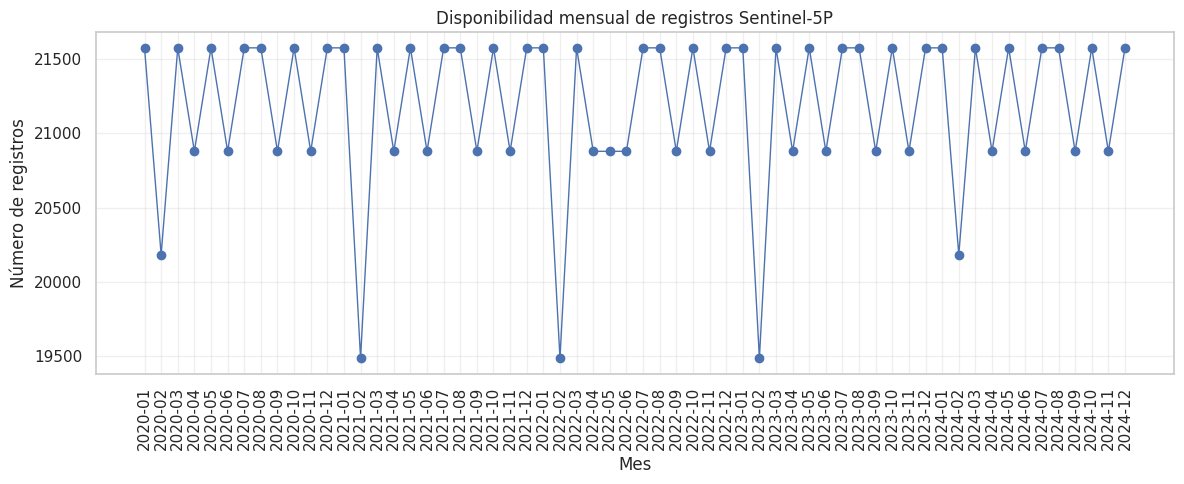

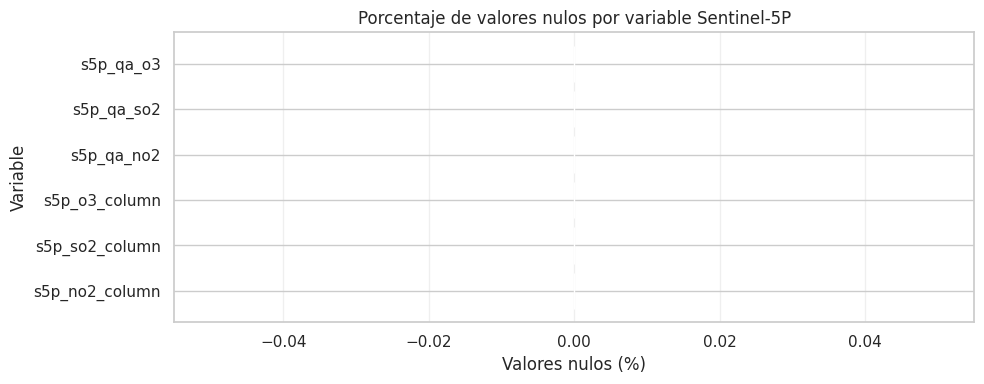

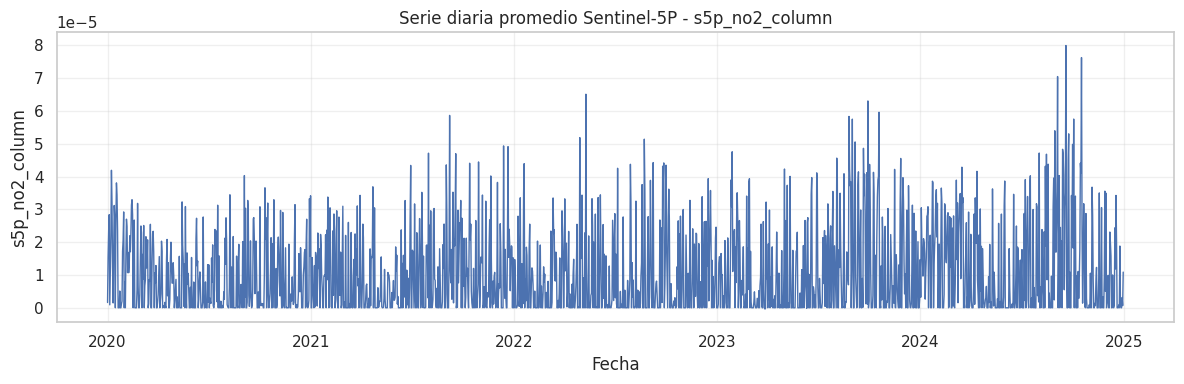

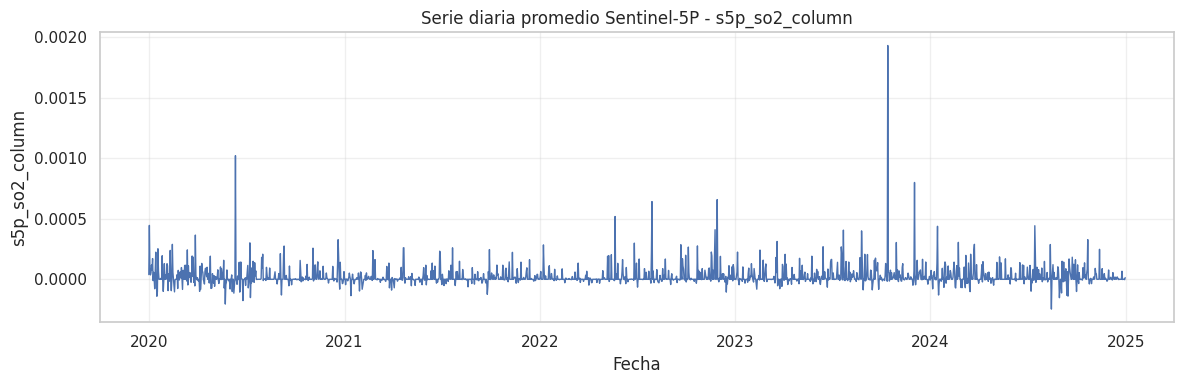

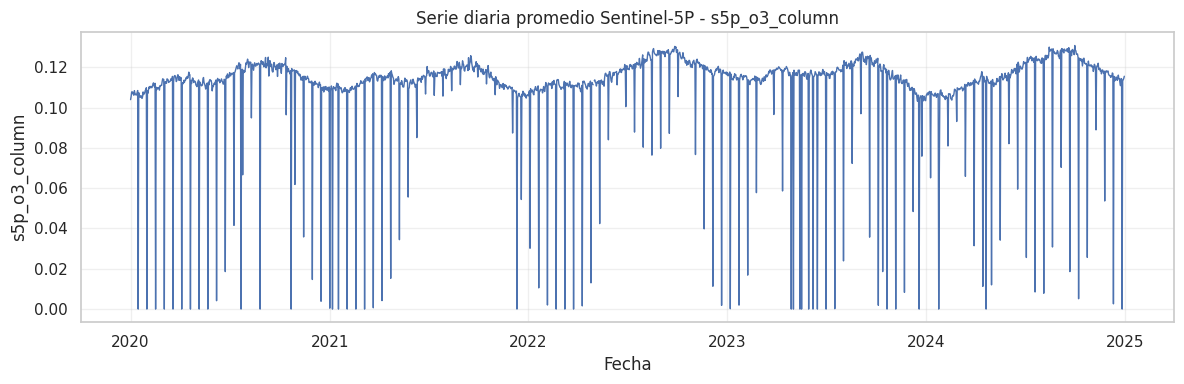

In [23]:
# ============================================================
# CELDA 08.2 — Visualizaciones Sentinel-5P
# ============================================================

FIG_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Disponibilidad mensual Sentinel-5P
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    s5p_disponibilidad_mensual["mes"],
    s5p_disponibilidad_mensual["n_registros"],
    marker="o",
    linewidth=1
)

ax.set_title("Disponibilidad mensual de registros Sentinel-5P")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "08_sentinel5p_disponibilidad_mensual.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 2. Porcentaje de nulos por variable Sentinel-5P
# ------------------------------------------------------------

if len(df_calidad_s5p) > 0:
    plot_df = df_calidad_s5p.sort_values("porcentaje_nulos", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))

    ax.barh(plot_df["variable"], plot_df["porcentaje_nulos"])

    ax.set_title("Porcentaje de valores nulos por variable Sentinel-5P")
    ax.set_xlabel("Valores nulos (%)")
    ax.set_ylabel("Variable")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "08_sentinel5p_nulos_por_variable.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


# ------------------------------------------------------------
# 3. Series temporales de variables contaminantes detectadas
# ------------------------------------------------------------

if len(cols_contaminantes_s5p) > 0:
    df_s5p_daily = (
        df_s5p
        .set_index(col_fecha_s5p)[cols_contaminantes_s5p]
        .resample("D")
        .mean()
        .reset_index()
    )

    for variable in cols_contaminantes_s5p:
        fig, ax = plt.subplots(figsize=(12, 4))

        ax.plot(
            df_s5p_daily[col_fecha_s5p],
            df_s5p_daily[variable],
            linewidth=1
        )

        ax.set_title(f"Serie diaria promedio Sentinel-5P - {variable}")
        ax.set_xlabel("Fecha")
        ax.set_ylabel(variable)
        ax.grid(True, alpha=0.3)

        nombre_fig = f"08_sentinel5p_serie_diaria_{variable}.png".replace("/", "_")
        plt.tight_layout()
        plt.savefig(FIG_DIR / nombre_fig, dpi=300, bbox_inches="tight")
        plt.show()

else:
    print("No se detectaron variables contaminantes para graficar series temporales.")

### 08.3 Tabla resumen Sentinel-5P para documentación

Se construye una tabla compacta con las variables contaminantes detectadas en Sentinel-5P. Esta tabla permite documentar la disponibilidad, porcentaje de nulos y estadísticos básicos de las variables satelitales utilizadas como apoyo en la caracterización ambiental.

In [24]:
# ============================================================
# CELDA 08.3 — Tabla compacta Sentinel-5P para informe
# ============================================================

if len(cols_contaminantes_s5p) > 0:
    tabla_s5p_informe = (
        df_calidad_s5p
        .loc[df_calidad_s5p["variable"].isin(cols_contaminantes_s5p)]
        .copy()
    )
else:
    tabla_s5p_informe = df_calidad_s5p.head(8).copy()

tabla_s5p_informe = tabla_s5p_informe[
    [
        "variable",
        "n_validos",
        "porcentaje_nulos",
        "media",
        "desviacion",
        "min",
        "mediana",
        "max"
    ]
]

for col in ["media", "desviacion", "min", "mediana", "max"]:
    tabla_s5p_informe[col] = tabla_s5p_informe[col].round(6)

display(tabla_s5p_informe)

tabla_s5p_informe.to_csv(
    TAB_DIR / "08_tabla_sentinel5p_informe.csv",
    index=False
)

,variable,n_validos,porcentaje_nulos,media,desviacion,min,mediana,max
0,s5p_no2_column,1270896,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0002
1,s5p_so2_column,1270896,0.0000,0.0000,0.0002,-0.0010,0.0000,0.0111
2,s5p_o3_column,1270896,0.0000,0.1108,0.0248,0.0000,0.1154,0.1473


### 08.4 Auditoría del archivo de cobertura Sentinel-5P

Además del panel principal Sentinel-5P, se revisa el archivo de cobertura asociado. Este archivo permite documentar la disponibilidad de observaciones satelitales por fecha o producto, y ayuda a justificar posibles vacíos en el panel consolidado.

Ruta cobertura Sentinel-5P: /workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/csv/sentinel5p_daily_coverage.csv
Existe: True
Es archivo: True
Extensión: .csv
Tamaño MB: 0.0983
Primeros bytes: b'\xef\xbb\xbfdate,s5p_n_ti'
Formato detectado: csv
Shape cobertura Sentinel-5P: (1826, 8)


,date,s5p_n_tiles_available_day,s5p_no2_mean,s5p_so2_mean,s5p_o3_mean,s5p_no2_available_pct,s5p_so2_available_pct,s5p_o3_available_pct
0,2020-01-01,1,0.0000,0.0000,0.1039,1.0000,1.0000,1.0000
1,2020-01-02,1,0.0000,0.0004,0.1055,1.0000,1.0000,1.0000
2,2020-01-03,1,0.0000,0.0001,0.1077,1.0000,1.0000,1.0000
3,2020-01-04,1,0.0000,0.0000,0.1078,1.0000,1.0000,1.0000
4,2020-01-05,1,0.0000,0.0001,0.1068,1.0000,1.0000,1.0000


Columnas cobertura Sentinel-5P:
['date', 's5p_n_tiles_available_day', 's5p_no2_mean', 's5p_so2_mean', 's5p_o3_mean', 's5p_no2_available_pct', 's5p_so2_available_pct', 's5p_o3_available_pct']


,metrica,valor
0,formato_detectado,csv
1,filas_totales,1826
2,columnas_totales,10
3,variables_numericas,8
4,columna_temporal_detectada,date
5,fecha_min,2020-01-01 00:00:00
6,fecha_max,2024-12-31 00:00:00
7,anios_disponibles,"2020, 2021, 2022, 2023, 2024"


,variable,n_registros,n_validos,porcentaje_nulos,media,min,mediana,max
0,s5p_n_tiles_available_day,1826,1826,0.0000,1.0000,1.0000,1.0000,1.0000
1,s5p_no2_mean,1826,1826,0.0000,0.0000,-0.0000,0.0000,0.0001
2,s5p_so2_mean,1826,1826,0.0000,0.0000,-0.0002,0.0000,0.0019
3,s5p_o3_mean,1826,1826,0.0000,0.1108,0.0000,0.1153,0.1308
4,s5p_no2_available_pct,1826,1826,0.0000,1.0000,1.0000,1.0000,1.0000
5,s5p_so2_available_pct,1826,1826,0.0000,1.0000,1.0000,1.0000,1.0000
6,s5p_o3_available_pct,1826,1826,0.0000,1.0000,1.0000,1.0000,1.0000
7,anio,1826,1826,0.0000,"2,022.0000","2,020.0000","2,022.0000","2,024.0000"


,mes,n_registros
0,2020-01,31
1,2020-02,29
2,2020-03,31
3,2020-04,30
4,2020-05,31


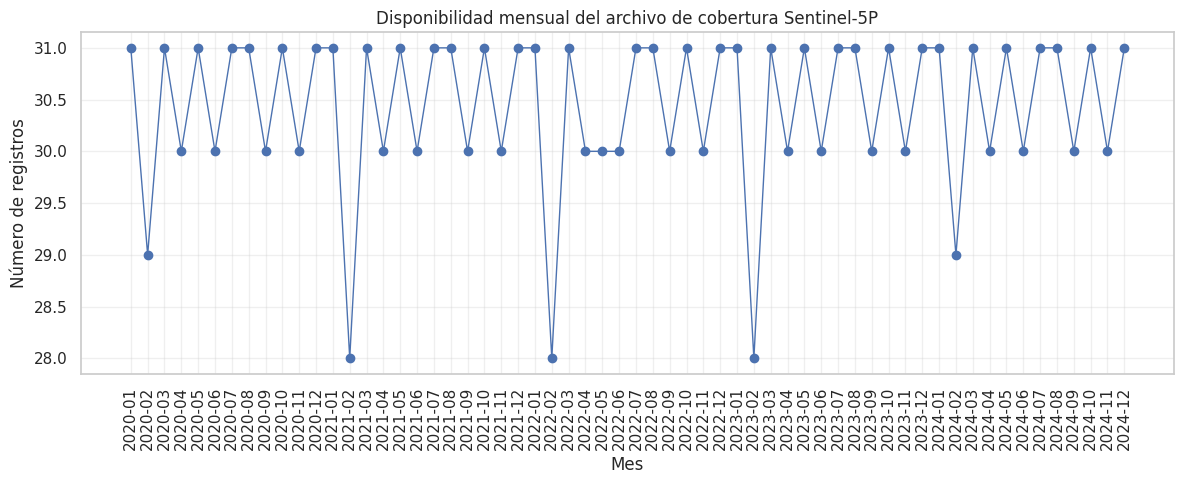

In [25]:
# ============================================================
# CELDA 08.4 — Auditoría robusta del archivo de cobertura Sentinel-5P
# Corrección:
# - Detecta si el archivo es parquet, csv, json o texto.
# - Evita romper si la extensión no corresponde al formato real.
# - Si no puede leerlo como tabla, genera diagnóstico del archivo.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

path_s5p_cov = Path(RUTAS["sentinel5p_coverage"])

print("Ruta cobertura Sentinel-5P:", path_s5p_cov)
print("Existe:", path_s5p_cov.exists())
print("Es archivo:", path_s5p_cov.is_file() if path_s5p_cov.exists() else False)
print("Extensión:", path_s5p_cov.suffix if path_s5p_cov.exists() else None)

# ------------------------------------------------------------
# 1. Diagnóstico básico del archivo
# ------------------------------------------------------------

if path_s5p_cov.exists() and path_s5p_cov.is_file():
    print("Tamaño MB:", round(path_s5p_cov.stat().st_size / (1024**2), 4))

    with open(path_s5p_cov, "rb") as f:
        primeros_bytes = f.read(16)

    print("Primeros bytes:", primeros_bytes)

else:
    print("El archivo de cobertura no existe o no es un archivo válido.")


# ------------------------------------------------------------
# 2. Función robusta de lectura
# ------------------------------------------------------------

def leer_tabla_robusta(path):
    """
    Intenta leer un archivo tabular aunque la extensión sea incorrecta.
    Prueba Parquet, CSV, JSON y JSON lines.
    """
    path = Path(path)

    errores = {}

    # Intento 1: Parquet
    try:
        df = pd.read_parquet(path)
        return df, "parquet"
    except Exception as e:
        errores["parquet"] = str(e)

    # Intento 2: CSV con separador automático básico
    try:
        df = pd.read_csv(path)
        return df, "csv"
    except Exception as e:
        errores["csv"] = str(e)

    # Intento 3: CSV con separador punto y coma
    try:
        df = pd.read_csv(path, sep=";")
        return df, "csv_sep_punto_y_coma"
    except Exception as e:
        errores["csv_sep_punto_y_coma"] = str(e)

    # Intento 4: JSON normal
    try:
        df = pd.read_json(path)
        return df, "json"
    except Exception as e:
        errores["json"] = str(e)

    # Intento 5: JSON lines
    try:
        df = pd.read_json(path, lines=True)
        return df, "json_lines"
    except Exception as e:
        errores["json_lines"] = str(e)

    return None, errores


# ------------------------------------------------------------
# 3. Leer archivo de cobertura
# ------------------------------------------------------------

df_s5p_cov = None
formato_s5p_cov = None

if path_s5p_cov.exists() and path_s5p_cov.is_file():
    df_s5p_cov, formato_s5p_cov = leer_tabla_robusta(path_s5p_cov)

print("Formato detectado:", formato_s5p_cov)


# ------------------------------------------------------------
# 4. Si no se puede leer, guardar diagnóstico y salir sin romper
# ------------------------------------------------------------

if df_s5p_cov is None:
    print("No se pudo leer el archivo de cobertura Sentinel-5P como tabla.")
    print("Diagnóstico de errores:")
    print(formato_s5p_cov)

    diagnostico_s5p_cov = pd.DataFrame({
        "metrica": [
            "ruta",
            "existe",
            "es_archivo",
            "extension",
            "tamano_mb",
            "primeros_bytes",
            "observacion"
        ],
        "valor": [
            str(path_s5p_cov),
            path_s5p_cov.exists(),
            path_s5p_cov.is_file() if path_s5p_cov.exists() else False,
            path_s5p_cov.suffix if path_s5p_cov.exists() else None,
            round(path_s5p_cov.stat().st_size / (1024**2), 4) if path_s5p_cov.exists() and path_s5p_cov.is_file() else np.nan,
            str(primeros_bytes) if path_s5p_cov.exists() and path_s5p_cov.is_file() else None,
            "El archivo existe, pero no se pudo leer como Parquet/CSV/JSON. Revisar formato real o regenerar cobertura."
        ]
    })

    display(diagnostico_s5p_cov)

    diagnostico_s5p_cov.to_csv(
        TAB_DIR / "08_sentinel5p_coverage_diagnostico_error.csv",
        index=False
    )

else:
    # ------------------------------------------------------------
    # 5. Auditoría normal si sí se pudo leer
    # ------------------------------------------------------------

    df_s5p_cov.columns = [c.strip().lower() for c in df_s5p_cov.columns]

    print("Shape cobertura Sentinel-5P:", df_s5p_cov.shape)
    display(df_s5p_cov.head())
    print("Columnas cobertura Sentinel-5P:")
    print(df_s5p_cov.columns.tolist())

    def buscar_columna(cols, candidatos):
        for cand in candidatos:
            for c in cols:
                if cand in c.lower():
                    return c
        return None

    col_fecha_s5p_cov = buscar_columna(
        df_s5p_cov.columns,
        ["datetime", "fecha", "date", "timestamp", "time", "period", "dia", "day"]
    )

    if col_fecha_s5p_cov is not None:
        df_s5p_cov[col_fecha_s5p_cov] = pd.to_datetime(
            df_s5p_cov[col_fecha_s5p_cov],
            errors="coerce"
        )
        df_s5p_cov["anio"] = df_s5p_cov[col_fecha_s5p_cov].dt.year
        df_s5p_cov["mes"] = df_s5p_cov[col_fecha_s5p_cov].dt.to_period("M").astype(str)

    cols_numericas_s5p_cov = [
        c for c in df_s5p_cov.columns
        if pd.api.types.is_numeric_dtype(df_s5p_cov[c])
    ]

    resumen_s5p_cov = pd.DataFrame({
        "metrica": [
            "formato_detectado",
            "filas_totales",
            "columnas_totales",
            "variables_numericas",
            "columna_temporal_detectada",
            "fecha_min",
            "fecha_max",
            "anios_disponibles"
        ],
        "valor": [
            formato_s5p_cov,
            len(df_s5p_cov),
            df_s5p_cov.shape[1],
            len(cols_numericas_s5p_cov),
            col_fecha_s5p_cov,
            df_s5p_cov[col_fecha_s5p_cov].min() if col_fecha_s5p_cov is not None else np.nan,
            df_s5p_cov[col_fecha_s5p_cov].max() if col_fecha_s5p_cov is not None else np.nan,
            ", ".join(map(str, sorted(df_s5p_cov["anio"].dropna().unique().astype(int)))) if col_fecha_s5p_cov is not None else np.nan
        ]
    })

    display(resumen_s5p_cov)

    resumen_s5p_cov.to_csv(
        TAB_DIR / "08_sentinel5p_coverage_resumen.csv",
        index=False
    )

    # ------------------------------------------------------------
    # 6. Calidad de variables numéricas
    # ------------------------------------------------------------

    calidad_s5p_cov = []

    for col in cols_numericas_s5p_cov:
        serie = pd.to_numeric(df_s5p_cov[col], errors="coerce").astype("float64")

        calidad_s5p_cov.append({
            "variable": col,
            "n_registros": len(serie),
            "n_validos": int(serie.notna().sum()),
            "porcentaje_nulos": round(float(serie.isna().mean() * 100), 4),
            "media": serie.mean(),
            "min": serie.min(),
            "mediana": serie.median(),
            "max": serie.max()
        })

    df_calidad_s5p_cov = pd.DataFrame(calidad_s5p_cov)
    display(df_calidad_s5p_cov)

    df_calidad_s5p_cov.to_csv(
        TAB_DIR / "08_sentinel5p_coverage_calidad.csv",
        index=False
    )

    # ------------------------------------------------------------
    # 7. Disponibilidad mensual si hay fecha
    # ------------------------------------------------------------

    if col_fecha_s5p_cov is not None:
        s5p_cov_mensual = (
            df_s5p_cov
            .groupby("mes")
            .agg(n_registros=(col_fecha_s5p_cov, "size"))
            .reset_index()
        )

        display(s5p_cov_mensual.head())

        s5p_cov_mensual.to_csv(
            TAB_DIR / "08_sentinel5p_coverage_mensual.csv",
            index=False
        )

        FIG_DIR.mkdir(parents=True, exist_ok=True)

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(
            s5p_cov_mensual["mes"],
            s5p_cov_mensual["n_registros"],
            marker="o",
            linewidth=1
        )

        ax.set_title("Disponibilidad mensual del archivo de cobertura Sentinel-5P")
        ax.set_xlabel("Mes")
        ax.set_ylabel("Número de registros")
        ax.tick_params(axis="x", rotation=90)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            FIG_DIR / "08_sentinel5p_coverage_mensual.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()
    else:
        print("No se detectó columna temporal en el archivo de cobertura.")

### 08.5 Verificación de archivos Sentinel-5P originales

Además del panel tabular procesado, se verifica si existen archivos originales o rasters Sentinel-5P utilizados para construir el panel. Esta auditoría permite distinguir entre la grilla procesada y las imágenes/archivos satelitales fuente.

In [26]:
# ============================================================
# CELDA 08.6 — Inventario REAL de archivos Sentinel-5P procesados (.npy)
# Usando carpetas específicas NO2, SO2 y O3
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 1. Carpetas reales Sentinel-5P
# ------------------------------------------------------------

dirs_s5p_raw = {
    "NO2": Path("/workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/sentinel5p-raw/NO2"),
    "SO2": Path("/workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/sentinel5p-raw/SO2"),
    "O3":  Path("/workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/sentinel5p-raw/O3"),
}

print("Carpetas Sentinel-5P raw/procesadas:")
for producto, carpeta in dirs_s5p_raw.items():
    print(f"- {producto}: {carpeta} | existe: {carpeta.exists()}")

# ------------------------------------------------------------
# 2. Buscar archivos, incluyendo .npy
# ------------------------------------------------------------

extensiones_s5p = [
    "*.npy", "*.NPY",
    "*.npz", "*.NPZ",
    "*.nc", "*.NC", "*.nc4", "*.NC4",
    "*.he5", "*.HE5",
    "*.h5", "*.H5",
    "*.tif", "*.tiff", "*.TIF", "*.TIFF"
]

archivos_s5p = []

for producto, carpeta in dirs_s5p_raw.items():
    if carpeta.exists() and carpeta.is_dir():
        for patron in extensiones_s5p:
            for p in carpeta.rglob(patron):
                archivos_s5p.append({
                    "producto": producto,
                    "path": p
                })

print("\nArchivos Sentinel-5P encontrados:", len(archivos_s5p))

# ------------------------------------------------------------
# 3. Función para inferir fecha desde nombre
# ------------------------------------------------------------

def inferir_fecha_s5p(nombre):
    """
    Intenta inferir fecha desde patrones comunes:
    - YYYY-MM-DD.npy
    - YYYY_MM_DD.npy
    - YYYYMMDD.npy
    - YYYYMMDDT... típico Sentinel/TROPOMI
    """
    nombre = str(nombre)

    # YYYYMMDDT...
    m = re.search(r"(20\d{2})(\d{2})(\d{2})T", nombre)
    if m:
        return pd.to_datetime(f"{m.group(1)}-{m.group(2)}-{m.group(3)}", errors="coerce")

    # YYYY-MM-DD o YYYY_MM_DD
    m = re.search(r"(20\d{2})[-_](\d{2})[-_](\d{2})", nombre)
    if m:
        return pd.to_datetime(f"{m.group(1)}-{m.group(2)}-{m.group(3)}", errors="coerce")

    # YYYYMMDD
    m = re.search(r"(20\d{2})(\d{2})(\d{2})", nombre)
    if m:
        return pd.to_datetime(f"{m.group(1)}-{m.group(2)}-{m.group(3)}", errors="coerce")

    return pd.NaT

# ------------------------------------------------------------
# 4. Inventario
# ------------------------------------------------------------

inventario_s5p = []

for item in archivos_s5p:
    producto = item["producto"]
    p = item["path"]

    try:
        stat = p.stat()

        inventario_s5p.append({
            "producto": producto,
            "archivo": p.name,
            "ruta": str(p),
            "extension": p.suffix.lower(),
            "size_mb": round(stat.st_size / (1024**2), 4),
            "fecha_inferida": inferir_fecha_s5p(p.name),
            "carpeta_padre": str(p.parent),
            "modificado": pd.to_datetime(stat.st_mtime, unit="s")
        })

    except Exception as e:
        inventario_s5p.append({
            "producto": producto,
            "archivo": p.name,
            "ruta": str(p),
            "extension": p.suffix.lower(),
            "size_mb": np.nan,
            "fecha_inferida": pd.NaT,
            "carpeta_padre": str(p.parent),
            "modificado": pd.NaT,
            "error": str(e)
        })

df_inventario_s5p_raw = pd.DataFrame(inventario_s5p)

if len(df_inventario_s5p_raw) > 0:
    df_inventario_s5p_raw["fecha_inferida"] = pd.to_datetime(
        df_inventario_s5p_raw["fecha_inferida"],
        errors="coerce"
    )
    df_inventario_s5p_raw["anio"] = df_inventario_s5p_raw["fecha_inferida"].dt.year
    df_inventario_s5p_raw["mes"] = df_inventario_s5p_raw["fecha_inferida"].dt.to_period("M").astype(str)

display(df_inventario_s5p_raw.head(30))

# ------------------------------------------------------------
# 5. Resumen general
# ------------------------------------------------------------

if len(df_inventario_s5p_raw) > 0:
    resumen_s5p_raw = pd.DataFrame({
        "metrica": [
            "n_archivos_sentinel5p_procesados",
            "productos_detectados",
            "formatos_detectados",
            "tamano_total_mb",
            "fecha_min_inferida",
            "fecha_max_inferida",
            "archivos_con_fecha_inferida",
            "archivos_sin_fecha_inferida",
            "carpetas_unicas"
        ],
        "valor": [
            len(df_inventario_s5p_raw),
            ", ".join(sorted(df_inventario_s5p_raw["producto"].dropna().unique())),
            ", ".join(sorted(df_inventario_s5p_raw["extension"].dropna().unique())),
            round(df_inventario_s5p_raw["size_mb"].sum(), 4),
            df_inventario_s5p_raw["fecha_inferida"].min(),
            df_inventario_s5p_raw["fecha_inferida"].max(),
            int(df_inventario_s5p_raw["fecha_inferida"].notna().sum()),
            int(df_inventario_s5p_raw["fecha_inferida"].isna().sum()),
            df_inventario_s5p_raw["carpeta_padre"].nunique()
        ]
    })
else:
    resumen_s5p_raw = pd.DataFrame({
        "metrica": [
            "n_archivos_sentinel5p_procesados",
            "observacion"
        ],
        "valor": [
            0,
            "No se encontraron archivos en las carpetas Sentinel-5P especificadas."
        ]
    })

display(resumen_s5p_raw)

# ------------------------------------------------------------
# 6. Resumen por producto
# ------------------------------------------------------------

if len(df_inventario_s5p_raw) > 0:
    resumen_s5p_por_producto = (
        df_inventario_s5p_raw
        .groupby("producto")
        .agg(
            n_archivos=("archivo", "count"),
            tamano_total_mb=("size_mb", "sum"),
            fecha_min=("fecha_inferida", "min"),
            fecha_max=("fecha_inferida", "max"),
            archivos_con_fecha=("fecha_inferida", lambda x: x.notna().sum())
        )
        .reset_index()
    )

    resumen_s5p_por_producto["tamano_total_mb"] = resumen_s5p_por_producto["tamano_total_mb"].round(4)

    display(resumen_s5p_por_producto)

    resumen_s5p_por_producto.to_csv(
        TAB_DIR / "08F_resumen_sentinel5p_procesado_por_producto.csv",
        index=False
    )

# ------------------------------------------------------------
# 7. Guardar salidas
# ------------------------------------------------------------

df_inventario_s5p_raw.to_csv(
    TAB_DIR / "08F_inventario_sentinel5p_procesado.csv",
    index=False
)

resumen_s5p_raw.to_csv(
    TAB_DIR / "08F_resumen_sentinel5p_procesado.csv",
    index=False
)

print("Inventario guardado en:", TAB_DIR / "08F_inventario_sentinel5p_procesado.csv")
print("Resumen guardado en:", TAB_DIR / "08F_resumen_sentinel5p_procesado.csv")

Carpetas Sentinel-5P raw/procesadas:
- NO2: /workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/sentinel5p-raw/NO2 | existe: True
- SO2: /workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/sentinel5p-raw/SO2 | existe: True
- O3: /workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/sentinel5p-raw/O3 | existe: True



Archivos Sentinel-5P encontrados: 5552


,producto,archivo,ruta,extension,size_mb,fecha_inferida,carpeta_padre,modificado,anio,mes
0,NO2,NO2_2024_12.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:20,NaN,NaN
1,NO2,NO2_2024_11.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:20,NaN,NaN
2,NO2,NO2_2024_10.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:19,NaN,NaN
3,NO2,NO2_2024_09.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:18,NaN,NaN
4,NO2,NO2_2024_08.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:17,NaN,NaN
5,NO2,NO2_2024_07.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:17,NaN,NaN
6,NO2,NO2_2024_06.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:16,NaN,NaN
7,NO2,NO2_2024_05.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:15,NaN,NaN
8,NO2,NO2_2024_04.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:15,NaN,NaN
9,NO2,NO2_2024_03.npy,/workspace/geovision-cali-hf/data/sentinel2-se...,.npy,0.0003,NaT,/workspace/geovision-cali-hf/data/sentinel2-se...,2026-05-21 03:26:14,NaN,NaN


,metrica,valor
0,n_archivos_sentinel5p_procesados,5552
1,productos_detectados,"NO2, O3, SO2"
2,formatos_detectados,.npy
3,tamano_total_mb,15.3656
4,fecha_min_inferida,2020-01-01 00:00:00
5,fecha_max_inferida,2024-12-31 00:00:00
6,archivos_con_fecha_inferida,5480
7,archivos_sin_fecha_inferida,72
8,carpetas_unicas,3


,producto,n_archivos,tamano_total_mb,fecha_min,fecha_max,archivos_con_fecha
0,NO2,1850,5.1200,2020-01-01,2024-12-31,1826
1,O3,1851,5.1228,2020-01-01,2024-12-31,1827
2,SO2,1851,5.1228,2020-01-01,2024-12-31,1827


Inventario guardado en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas/08F_inventario_sentinel5p_procesado.csv
Resumen guardado en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas/08F_resumen_sentinel5p_procesado.csv


### 08.7 Previsualización de una grilla Sentinel-5P procesada

Se visualiza un archivo `.npy` Sentinel-5P correspondiente a una fecha y contaminante representativo. Esta previsualización permite verificar que los archivos procesados conservan estructura espacial tipo grilla y contienen valores numéricos utilizables para construir el panel satelital consolidado.

Archivo seleccionado:
/workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/sentinel5p-raw/O3/2022-07-14.npy
Producto: O3
Fecha: 2022-07-14 00:00:00
Shape: (29, 24)
Dtype: float32
Ndim: 2
Min: 0.11786830425262451
Max: 0.12160862982273102
Media: 0.11979340584199319
N válidos: 696


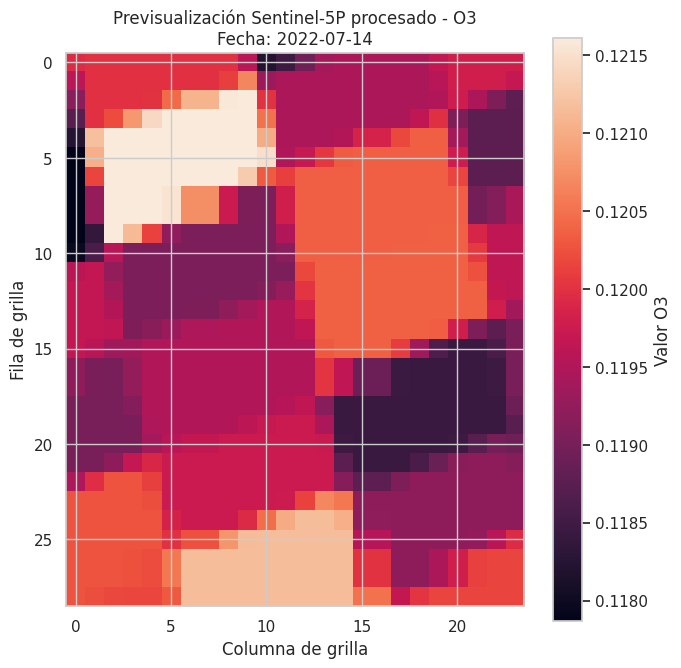

,metrica,valor
0,producto,O3
1,archivo,2022-07-14.npy
2,ruta,/workspace/geovision-cali-hf/data/sentinel2-se...
3,fecha_inferida,2022-07-14 00:00:00
4,shape,"(29, 24)"
5,dtype,float64
6,ndim,2
7,min,0.1179
8,max,0.1216
9,media,0.1198


Figura guardada en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/figuras/08G_preview_sentinel5p_npy_O3.png
Metadatos guardados en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas/08G_preview_sentinel5p_npy_metadata.csv


In [27]:
# ============================================================
# CELDA 08.7 — Previsualización de archivo .npy Sentinel-5P
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR.mkdir(parents=True, exist_ok=True)

if "df_inventario_s5p_raw" not in globals() or len(df_inventario_s5p_raw) == 0:
    raise ValueError("Primero corre la celda 08.6 para crear df_inventario_s5p_raw.")

# ------------------------------------------------------------
# 1. Seleccionar producto y archivo
# ------------------------------------------------------------

# Preferimos O3 porque suele tener valores visualmente más claros.
producto_preferido = "O3"

candidatos = df_inventario_s5p_raw[
    (df_inventario_s5p_raw["producto"] == producto_preferido) &
    (df_inventario_s5p_raw["extension"] == ".npy")
].copy()

if len(candidatos) == 0:
    candidatos = df_inventario_s5p_raw[
        df_inventario_s5p_raw["extension"] == ".npy"
    ].copy()

if len(candidatos) == 0:
    raise ValueError("No hay archivos .npy para previsualizar.")

candidatos = candidatos.sort_values("fecha_inferida")
archivo_preview = candidatos.iloc[len(candidatos) // 2]["ruta"]
producto_preview = candidatos.iloc[len(candidatos) // 2]["producto"]
fecha_preview = candidatos.iloc[len(candidatos) // 2]["fecha_inferida"]

print("Archivo seleccionado:")
print(archivo_preview)
print("Producto:", producto_preview)
print("Fecha:", fecha_preview)

# ------------------------------------------------------------
# 2. Cargar arreglo .npy
# ------------------------------------------------------------

arr = np.load(archivo_preview, allow_pickle=False)

print("Shape:", arr.shape)
print("Dtype:", arr.dtype)
print("Ndim:", arr.ndim)

arr = arr.astype(float)
arr = np.where(np.isfinite(arr), arr, np.nan)

print("Min:", np.nanmin(arr))
print("Max:", np.nanmax(arr))
print("Media:", np.nanmean(arr))
print("N válidos:", np.isfinite(arr).sum())

# ------------------------------------------------------------
# 3. Si el arreglo tiene más de 2 dimensiones, tomar primera capa
# ------------------------------------------------------------

arr_plot = arr.copy()

if arr_plot.ndim == 3:
    # Si está como bandas x alto x ancho
    if arr_plot.shape[0] <= 10:
        arr_plot = arr_plot[0]
    else:
        arr_plot = arr_plot[:, :, 0]

if arr_plot.ndim != 2:
    raise ValueError(f"El arreglo no quedó 2D para graficar. Shape final: {arr_plot.shape}")

# ------------------------------------------------------------
# 4. Visualizar como imagen/grilla
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

im = ax.imshow(arr_plot, origin="upper")

ax.set_title(f"Previsualización Sentinel-5P procesado - {producto_preview}\nFecha: {pd.to_datetime(fecha_preview).date() if pd.notna(fecha_preview) else Path(archivo_preview).name}")
ax.set_xlabel("Columna de grilla")
ax.set_ylabel("Fila de grilla")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"Valor {producto_preview}")

plt.tight_layout()

nombre_fig = f"08G_preview_sentinel5p_npy_{producto_preview}.png"
plt.savefig(
    FIG_DIR / nombre_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5. Guardar metadatos
# ------------------------------------------------------------

metadata_preview_s5p_npy = pd.DataFrame({
    "metrica": [
        "producto",
        "archivo",
        "ruta",
        "fecha_inferida",
        "shape",
        "dtype",
        "ndim",
        "min",
        "max",
        "media",
        "n_validos"
    ],
    "valor": [
        producto_preview,
        Path(archivo_preview).name,
        archivo_preview,
        fecha_preview,
        str(arr.shape),
        str(arr.dtype),
        arr.ndim,
        np.nanmin(arr),
        np.nanmax(arr),
        np.nanmean(arr),
        int(np.isfinite(arr).sum())
    ]
})

display(metadata_preview_s5p_npy)

metadata_preview_s5p_npy.to_csv(
    TAB_DIR / "08G_preview_sentinel5p_npy_metadata.csv",
    index=False
)

print("Figura guardada en:", FIG_DIR / nombre_fig)
print("Metadatos guardados en:", TAB_DIR / "08G_preview_sentinel5p_npy_metadata.csv")

<!-- interpretacion-s1:sentinel5p -->
**Interpretacion.** Sentinel-5P aporta columnas atmosfericas de NO2, SO2 y O3 sobre el area de estudio. Su resolucion es mas gruesa que la escala de una estacion, por eso se usa como fuente satelital complementaria y no como reemplazo de DAGMA/SISAIRE.

## 09. EDA Sentinel-2

### 09.1 Auditoría de cobertura Sentinel-2

En esta sección se analiza la fuente Sentinel-2 utilizada como apoyo óptico y espacial dentro de la consolidación multifuente. 
Sentinel-2 no mide directamente NO₂, SO₂ u O₃, pero puede aportar información relacionada con superficie urbana, vegetación, cobertura del suelo, nubosidad y disponibilidad de observaciones ópticas.

El objetivo de esta auditoría es verificar la existencia del archivo de cobertura Sentinel-2, su rango temporal, variables disponibles, presencia de valores faltantes y calidad general de las observaciones. Esta revisión permite justificar qué tan usable es Sentinel-2 como fuente complementaria dentro de la Situación 1.

In [28]:
# ============================================================
# CELDA 09.1 — Auditoría robusta Sentinel-2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

path_s2_cov = Path(RUTAS["sentinel2_coverage"])

print("Ruta cobertura Sentinel-2:", path_s2_cov)
print("Existe:", path_s2_cov.exists())
print("Es archivo:", path_s2_cov.is_file() if path_s2_cov.exists() else False)
print("Extensión:", path_s2_cov.suffix if path_s2_cov.exists() else None)

if path_s2_cov.exists() and path_s2_cov.is_file():
    print("Tamaño MB:", round(path_s2_cov.stat().st_size / (1024**2), 4))

    with open(path_s2_cov, "rb") as f:
        primeros_bytes_s2 = f.read(16)

    print("Primeros bytes:", primeros_bytes_s2)
else:
    primeros_bytes_s2 = None
    print("El archivo de cobertura Sentinel-2 no existe o no es un archivo válido.")


# ------------------------------------------------------------
# Función robusta de lectura
# ------------------------------------------------------------

def leer_tabla_robusta(path):
    """
    Intenta leer un archivo tabular aunque la extensión sea incorrecta.
    Prueba Parquet, CSV, CSV con punto y coma, JSON y JSON lines.
    """
    path = Path(path)

    errores = {}

    try:
        df = pd.read_parquet(path)
        return df, "parquet"
    except Exception as e:
        errores["parquet"] = str(e)

    try:
        df = pd.read_csv(path)
        return df, "csv"
    except Exception as e:
        errores["csv"] = str(e)

    try:
        df = pd.read_csv(path, sep=";")
        return df, "csv_sep_punto_y_coma"
    except Exception as e:
        errores["csv_sep_punto_y_coma"] = str(e)

    try:
        df = pd.read_json(path)
        return df, "json"
    except Exception as e:
        errores["json"] = str(e)

    try:
        df = pd.read_json(path, lines=True)
        return df, "json_lines"
    except Exception as e:
        errores["json_lines"] = str(e)

    return None, errores


# ------------------------------------------------------------
# Leer cobertura Sentinel-2
# ------------------------------------------------------------

df_s2_cov = None
formato_s2_cov = None

if path_s2_cov.exists() and path_s2_cov.is_file():
    df_s2_cov, formato_s2_cov = leer_tabla_robusta(path_s2_cov)

print("Formato detectado:", formato_s2_cov)


if df_s2_cov is None:
    print("No se pudo leer el archivo de cobertura Sentinel-2 como tabla.")
    print("Diagnóstico de errores:")
    print(formato_s2_cov)

    diagnostico_s2_cov = pd.DataFrame({
        "metrica": [
            "ruta",
            "existe",
            "es_archivo",
            "extension",
            "tamano_mb",
            "primeros_bytes",
            "observacion"
        ],
        "valor": [
            str(path_s2_cov),
            path_s2_cov.exists(),
            path_s2_cov.is_file() if path_s2_cov.exists() else False,
            path_s2_cov.suffix if path_s2_cov.exists() else None,
            round(path_s2_cov.stat().st_size / (1024**2), 4) if path_s2_cov.exists() and path_s2_cov.is_file() else np.nan,
            str(primeros_bytes_s2),
            "No se pudo leer como Parquet/CSV/JSON. Revisar formato real o regenerar cobertura."
        ]
    })

    display(diagnostico_s2_cov)

    diagnostico_s2_cov.to_csv(
        TAB_DIR / "09_sentinel2_coverage_diagnostico_error.csv",
        index=False
    )

else:
    df_s2_cov.columns = [c.strip().lower() for c in df_s2_cov.columns]

    print("Shape cobertura Sentinel-2:", df_s2_cov.shape)
    display(df_s2_cov.head())
    print("Columnas Sentinel-2:")
    print(df_s2_cov.columns.tolist())

    # --------------------------------------------------------
    # Detectar columna temporal
    # --------------------------------------------------------

    def buscar_columna(cols, candidatos):
        for cand in candidatos:
            for c in cols:
                if cand in c.lower():
                    return c
        return None

    col_fecha_s2 = buscar_columna(
        df_s2_cov.columns,
        ["datetime", "fecha", "date", "timestamp", "time", "period", "dia", "day"]
    )

    if col_fecha_s2 is not None:
        df_s2_cov[col_fecha_s2] = pd.to_datetime(df_s2_cov[col_fecha_s2], errors="coerce")
        df_s2_cov["anio"] = df_s2_cov[col_fecha_s2].dt.year
        df_s2_cov["mes"] = df_s2_cov[col_fecha_s2].dt.to_period("M").astype(str)

    # --------------------------------------------------------
    # Detectar columnas numéricas y columnas de cobertura/calidad
    # --------------------------------------------------------

    cols_numericas_s2 = [
        c for c in df_s2_cov.columns
        if pd.api.types.is_numeric_dtype(df_s2_cov[c])
    ]

    keywords_calidad_s2 = [
        "cloud", "nube", "cloudy", "valid", "pixel", "coverage",
        "available", "nodata", "qa", "mask"
    ]

    cols_calidad_s2 = [
        c for c in df_s2_cov.columns
        if any(k in c.lower() for k in keywords_calidad_s2)
    ]

    print("Columna temporal Sentinel-2:", col_fecha_s2)
    print("Variables numéricas Sentinel-2:", cols_numericas_s2)
    print("Variables de calidad/cobertura Sentinel-2:", cols_calidad_s2)

    # --------------------------------------------------------
    # Resumen general
    # --------------------------------------------------------

    resumen_s2_cov = pd.DataFrame({
        "metrica": [
            "formato_detectado",
            "filas_totales",
            "columnas_totales",
            "variables_numericas",
            "variables_calidad_cobertura",
            "columna_temporal_detectada",
            "fecha_min",
            "fecha_max",
            "anios_disponibles"
        ],
        "valor": [
            formato_s2_cov,
            len(df_s2_cov),
            df_s2_cov.shape[1],
            len(cols_numericas_s2),
            ", ".join(cols_calidad_s2),
            col_fecha_s2,
            df_s2_cov[col_fecha_s2].min() if col_fecha_s2 is not None else np.nan,
            df_s2_cov[col_fecha_s2].max() if col_fecha_s2 is not None else np.nan,
            ", ".join(map(str, sorted(df_s2_cov["anio"].dropna().unique().astype(int)))) if col_fecha_s2 is not None else np.nan
        ]
    })

    display(resumen_s2_cov)

    resumen_s2_cov.to_csv(
        TAB_DIR / "09_sentinel2_coverage_resumen.csv",
        index=False
    )

    # --------------------------------------------------------
    # Calidad por variable numérica
    # --------------------------------------------------------

    calidad_s2_cov = []

    for col in cols_numericas_s2:
        serie = pd.to_numeric(df_s2_cov[col], errors="coerce").astype("float64")

        calidad_s2_cov.append({
            "variable": col,
            "n_registros": len(serie),
            "n_validos": int(serie.notna().sum()),
            "porcentaje_nulos": round(float(serie.isna().mean() * 100), 4),
            "media": serie.mean(),
            "min": serie.min(),
            "mediana": serie.median(),
            "max": serie.max()
        })

    df_calidad_s2_cov = pd.DataFrame(calidad_s2_cov)
    display(df_calidad_s2_cov)

    df_calidad_s2_cov.to_csv(
        TAB_DIR / "09_sentinel2_coverage_calidad.csv",
        index=False
    )

    # --------------------------------------------------------
    # Cobertura mensual
    # --------------------------------------------------------

    if col_fecha_s2 is not None:
        s2_cov_mensual = (
            df_s2_cov
            .groupby("mes")
            .agg(n_registros=(col_fecha_s2, "size"))
            .reset_index()
        )

        display(s2_cov_mensual.head())

        s2_cov_mensual.to_csv(
            TAB_DIR / "09_sentinel2_coverage_mensual.csv",
            index=False
        )

    # --------------------------------------------------------
    # Guardar columnas detectadas
    # --------------------------------------------------------

    cols_s2_detectadas = {
        "formato": formato_s2_cov,
        "col_fecha": col_fecha_s2,
        "cols_numericas": cols_numericas_s2,
        "cols_calidad_cobertura": cols_calidad_s2,
        "columnas": df_s2_cov.columns.tolist()
    }

    with open(TAB_DIR / "09_sentinel2_columnas_detectadas.json", "w", encoding="utf-8") as f:
        json.dump(cols_s2_detectadas, f, indent=4, ensure_ascii=False)

    print("\nResumen interpretativo Sentinel-2:")
    print(f"- Registros: {len(df_s2_cov):,}")
    print(f"- Periodo: {df_s2_cov[col_fecha_s2].min() if col_fecha_s2 is not None else 'No detectado'} a {df_s2_cov[col_fecha_s2].max() if col_fecha_s2 is not None else 'No detectado'}")
    print(f"- Años disponibles: {', '.join(map(str, sorted(df_s2_cov['anio'].dropna().unique().astype(int)))) if col_fecha_s2 is not None else 'No detectado'}")
    print(f"- Variables de calidad/cobertura detectadas: {cols_calidad_s2}")

Ruta cobertura Sentinel-2: /workspace/geovision-cali-hf/data/sentinel2-sentinel-5p/csv/sentinel2_daily_coverage_corregido.csv
Existe: True
Es archivo: True
Extensión: .csv
Tamaño MB: 0.0105
Primeros bytes: b'\xef\xbb\xbfdate,s2_n_gri'
Formato detectado: csv
Shape cobertura Sentinel-2: (129, 8)


,date,s2_n_grids_available_day,s2_cloud_pct_mean,s2_valid_pixel_pct_mean,s2_ndvi_mean,s2_bsi_mean,s2_ndbi_mean,s2_urban_index_mean
0,2020-01-02,1978,44.1100,92.9719,0.2377,-0.0580,-0.0867,-0.0724
1,2020-01-07,1953,35.8267,94.4340,0.2910,-0.0629,-0.0977,-0.0803
2,2020-01-12,1959,46.8914,92.7768,0.2517,-0.0564,-0.0847,-0.0706
3,2020-01-17,2000,10.6365,99.2461,0.3310,-0.0448,-0.0780,-0.0614
4,2020-01-27,1877,55.1600,89.9558,0.2204,-0.0647,-0.0901,-0.0774


Columnas Sentinel-2:
['date', 's2_n_grids_available_day', 's2_cloud_pct_mean', 's2_valid_pixel_pct_mean', 's2_ndvi_mean', 's2_bsi_mean', 's2_ndbi_mean', 's2_urban_index_mean']
Columna temporal Sentinel-2: date
Variables numéricas Sentinel-2: ['s2_n_grids_available_day', 's2_cloud_pct_mean', 's2_valid_pixel_pct_mean', 's2_ndvi_mean', 's2_bsi_mean', 's2_ndbi_mean', 's2_urban_index_mean', 'anio']
Variables de calidad/cobertura Sentinel-2: ['s2_n_grids_available_day', 's2_cloud_pct_mean', 's2_valid_pixel_pct_mean']


,metrica,valor
0,formato_detectado,csv
1,filas_totales,129
2,columnas_totales,10
3,variables_numericas,8
4,variables_calidad_cobertura,"s2_n_grids_available_day, s2_cloud_pct_mean, s..."
5,columna_temporal_detectada,date
6,fecha_min,2020-01-02 00:00:00
7,fecha_max,2024-12-16 00:00:00
8,anios_disponibles,"2020, 2021, 2022, 2023, 2024"


,variable,n_registros,n_validos,porcentaje_nulos,media,min,mediana,max
0,s2_n_grids_available_day,129,129,0.0000,"1,754.6667",2.0000,"1,982.0000","2,000.0000"
1,s2_cloud_pct_mean,129,129,0.0000,40.1052,4.3875,44.1100,59.7800
2,s2_valid_pixel_pct_mean,129,129,0.0000,92.9762,12.2685,94.8996,99.9995
3,s2_ndvi_mean,129,129,0.0000,0.2529,0.0886,0.2548,0.4502
4,s2_bsi_mean,129,129,0.0000,-0.0572,-0.1742,-0.0564,-0.0075
5,s2_ndbi_mean,129,129,0.0000,-0.0875,-0.3023,-0.0850,-0.0503
6,s2_urban_index_mean,129,129,0.0000,-0.0723,-0.2382,-0.0706,-0.0304
7,anio,129,129,0.0000,"2,022.2093","2,020.0000","2,022.0000","2,024.0000"


,mes,n_registros
0,2020-01,5
1,2020-02,4
2,2020-03,2
3,2020-04,1
4,2020-05,1



Resumen interpretativo Sentinel-2:
- Registros: 129
- Periodo: 2020-01-02 00:00:00 a 2024-12-16 00:00:00
- Años disponibles: 2020, 2021, 2022, 2023, 2024
- Variables de calidad/cobertura detectadas: ['s2_n_grids_available_day', 's2_cloud_pct_mean', 's2_valid_pixel_pct_mean']


### 09.2 Visualizaciones de cobertura Sentinel-2

Las siguientes visualizaciones resumen la disponibilidad temporal y la calidad de la fuente Sentinel-2. 
Estas figuras permiten identificar continuidad temporal, posibles efectos de nubosidad y disponibilidad de píxeles válidos, aspectos relevantes cuando se utilizan productos ópticos.

Filas totales Sentinel-2: 129
Filas con fecha válida: 129
Rango fecha: 2020-01-02 00:00:00 a 2024-12-16 00:00:00


,mes,n_registros
0,2020-01,5
1,2020-02,4
2,2020-03,2
3,2020-04,1
4,2020-05,1


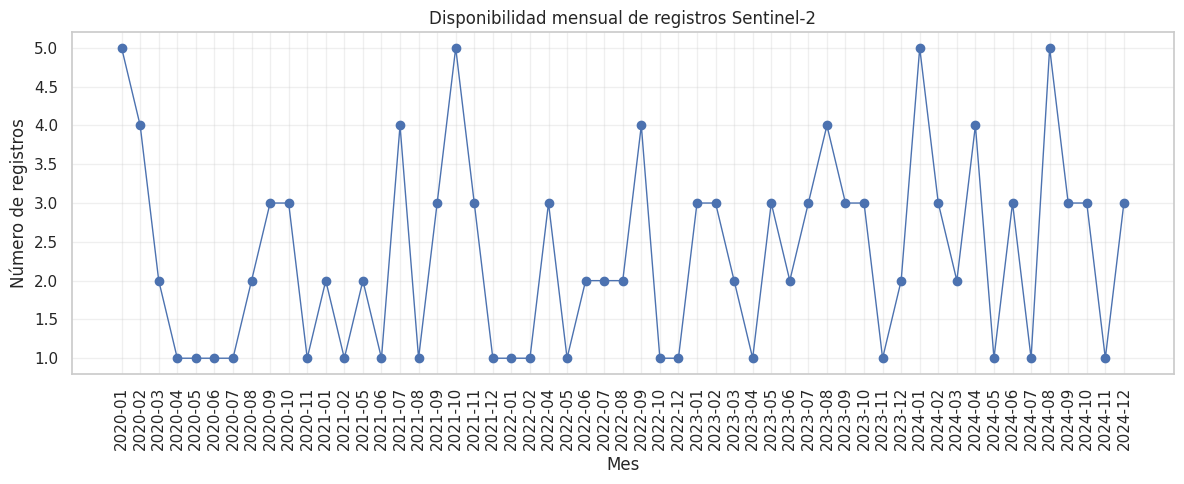

Columnas de calidad/cobertura detectadas:
['s2_n_grids_available_day', 's2_cloud_pct_mean', 's2_valid_pixel_pct_mean']


,variable,dtype_original,n_total,n_validos_numericos,porcentaje_nulos_o_no_numericos,min,mediana,max
0,s2_n_grids_available_day,int64,129,129,0.0000,2.0000,"1,982.0000","2,000.0000"
1,s2_cloud_pct_mean,float64,129,129,0.0000,4.3875,44.1100,59.7800
2,s2_valid_pixel_pct_mean,float64,129,129,0.0000,12.2685,94.8996,99.9995


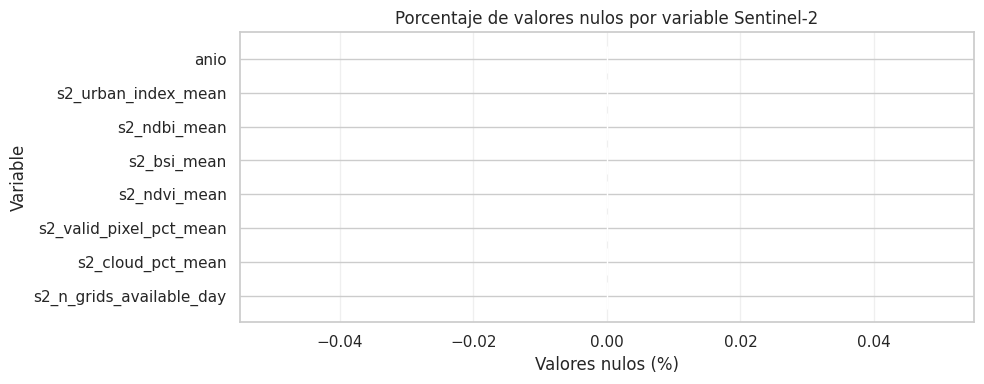

Variables Sentinel-2 con datos numéricos reales para graficar:
['s2_n_grids_available_day', 's2_cloud_pct_mean', 's2_valid_pixel_pct_mean']
s2_n_grids_available_day: puntos diarios válidos = 129


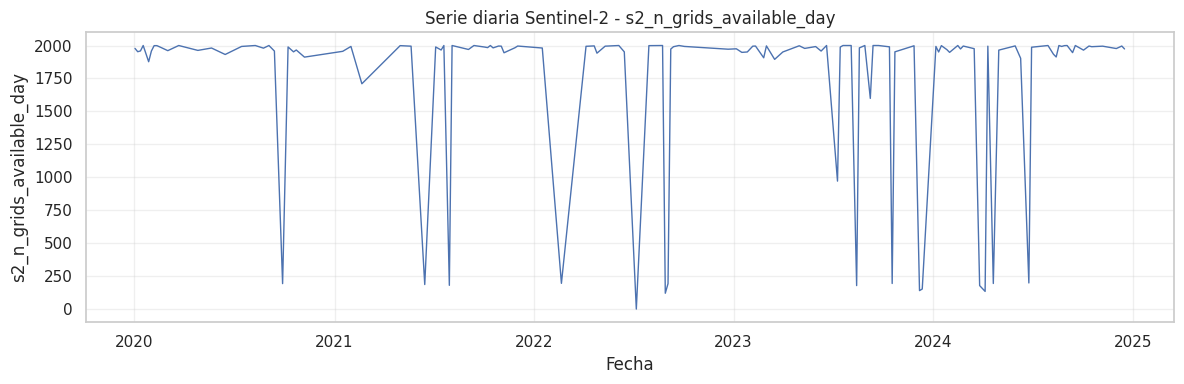

s2_cloud_pct_mean: puntos diarios válidos = 129


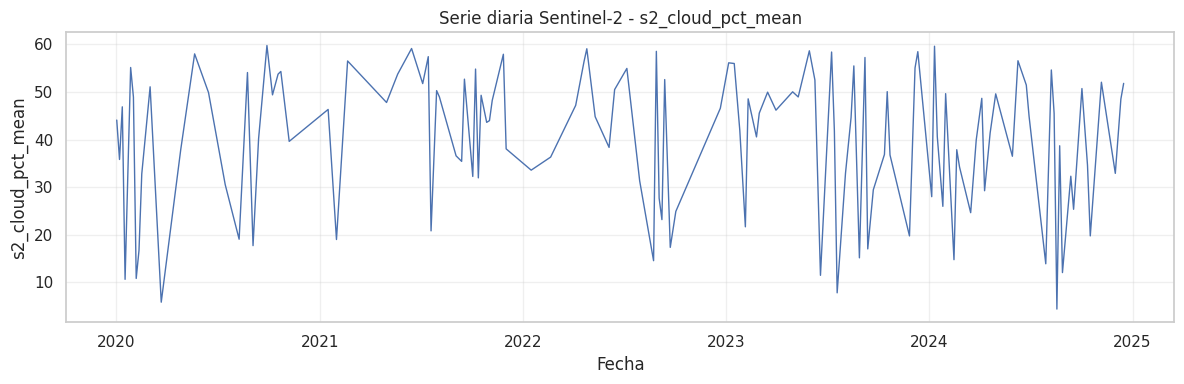

s2_valid_pixel_pct_mean: puntos diarios válidos = 129


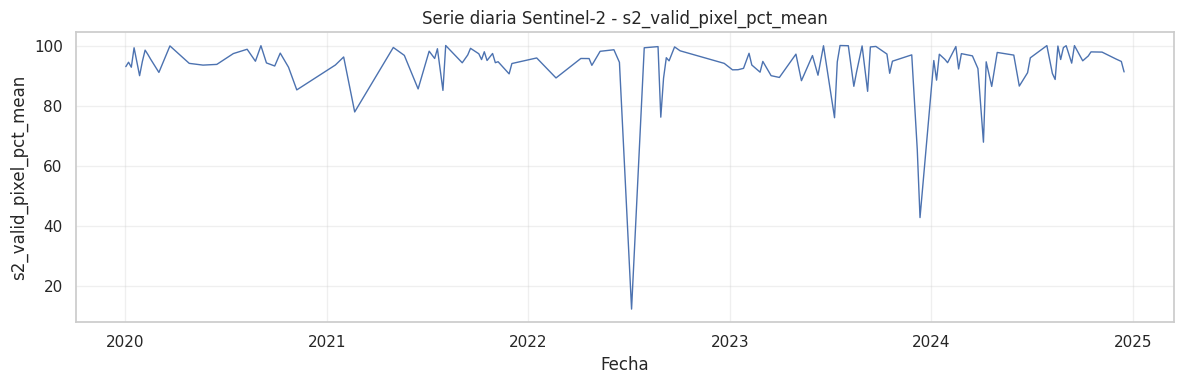

In [29]:
# ============================================================
# CELDA 09.2 — Visualizaciones Sentinel-2 
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

FIG_DIR.mkdir(parents=True, exist_ok=True)

if "df_s2_cov" not in globals() or df_s2_cov is None:
    raise ValueError("No existe df_s2_cov. Primero corre la celda 09.1.")

if "col_fecha_s2" not in globals() or col_fecha_s2 is None:
    raise ValueError("No se detectó columna temporal Sentinel-2. Revisa la celda 09.1.")

# ------------------------------------------------------------
# 1. Asegurar fecha correcta
# ------------------------------------------------------------

df_s2_cov[col_fecha_s2] = pd.to_datetime(df_s2_cov[col_fecha_s2], errors="coerce")

df_s2_plot = df_s2_cov.dropna(subset=[col_fecha_s2]).copy()

print("Filas totales Sentinel-2:", len(df_s2_cov))
print("Filas con fecha válida:", len(df_s2_plot))
print("Rango fecha:", df_s2_plot[col_fecha_s2].min(), "a", df_s2_plot[col_fecha_s2].max())


# ------------------------------------------------------------
# 2. Disponibilidad mensual
# ------------------------------------------------------------

df_s2_plot["mes"] = df_s2_plot[col_fecha_s2].dt.to_period("M").astype(str)

s2_cov_mensual = (
    df_s2_plot
    .groupby("mes")
    .agg(n_registros=(col_fecha_s2, "size"))
    .reset_index()
)

display(s2_cov_mensual.head())

s2_cov_mensual.to_csv(
    TAB_DIR / "09_sentinel2_coverage_mensual.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    s2_cov_mensual["mes"],
    s2_cov_mensual["n_registros"],
    marker="o",
    linewidth=1
)

ax.set_title("Disponibilidad mensual de registros Sentinel-2")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de registros")
ax.tick_params(axis="x", rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "09_sentinel2_disponibilidad_mensual.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 3. Diagnóstico de variables de calidad/cobertura
# ------------------------------------------------------------

if "cols_calidad_s2" not in globals():
    cols_calidad_s2 = []

print("Columnas de calidad/cobertura detectadas:")
print(cols_calidad_s2)

diagnostico_series_s2 = []

for col in cols_calidad_s2:
    if col not in df_s2_plot.columns:
        continue

    serie_num = pd.to_numeric(df_s2_plot[col], errors="coerce")

    diagnostico_series_s2.append({
        "variable": col,
        "dtype_original": str(df_s2_plot[col].dtype),
        "n_total": len(serie_num),
        "n_validos_numericos": int(serie_num.notna().sum()),
        "porcentaje_nulos_o_no_numericos": round(float(serie_num.isna().mean() * 100), 4),
        "min": serie_num.min(),
        "mediana": serie_num.median(),
        "max": serie_num.max()
    })

df_diagnostico_series_s2 = pd.DataFrame(diagnostico_series_s2)

display(df_diagnostico_series_s2)

df_diagnostico_series_s2.to_csv(
    TAB_DIR / "09_sentinel2_diagnostico_series_calidad.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Porcentaje de nulos por variable
# ------------------------------------------------------------

if "df_calidad_s2_cov" in globals() and len(df_calidad_s2_cov) > 0:
    plot_df = df_calidad_s2_cov.sort_values("porcentaje_nulos", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))

    ax.barh(plot_df["variable"], plot_df["porcentaje_nulos"])

    ax.set_title("Porcentaje de valores nulos por variable Sentinel-2")
    ax.set_xlabel("Valores nulos (%)")
    ax.set_ylabel("Variable")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "09_sentinel2_nulos_por_variable.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


# ------------------------------------------------------------
# 5. Series temporales de variables con datos reales
# ------------------------------------------------------------

cols_plot_s2 = []

for col in cols_calidad_s2:
    if col in df_s2_plot.columns:
        serie_num = pd.to_numeric(df_s2_plot[col], errors="coerce")
        if serie_num.notna().sum() > 0:
            cols_plot_s2.append(col)

print("Variables Sentinel-2 con datos numéricos reales para graficar:")
print(cols_plot_s2)

if len(cols_plot_s2) == 0:
    print("No hay variables de calidad/cobertura Sentinel-2 con valores numéricos válidos para graficar.")
else:
    df_s2_numeric = df_s2_plot[[col_fecha_s2] + cols_plot_s2].copy()

    for col in cols_plot_s2:
        df_s2_numeric[col] = pd.to_numeric(df_s2_numeric[col], errors="coerce")

    df_s2_daily = (
        df_s2_numeric
        .set_index(col_fecha_s2)[cols_plot_s2]
        .resample("D")
        .mean()
        .reset_index()
    )

    for variable in cols_plot_s2:
        serie_plot = df_s2_daily[[col_fecha_s2, variable]].dropna()

        print(f"{variable}: puntos diarios válidos =", len(serie_plot))

        if len(serie_plot) == 0:
            print(f"No se grafica {variable} porque no tiene puntos diarios válidos.")
            continue

        fig, ax = plt.subplots(figsize=(12, 4))

        ax.plot(
            serie_plot[col_fecha_s2],
            serie_plot[variable],
            linewidth=1
        )

        ax.set_title(f"Serie diaria Sentinel-2 - {variable}")
        ax.set_xlabel("Fecha")
        ax.set_ylabel(variable)
        ax.grid(True, alpha=0.3)

        nombre_fig = f"09_sentinel2_serie_diaria_{variable}.png".replace("/", "_")
        plt.tight_layout()
        plt.savefig(FIG_DIR / nombre_fig, dpi=300, bbox_inches="tight")
        plt.show()

### 09.3 Tabla resumen Sentinel-2 para documentación

Se construye una tabla compacta con las variables de cobertura y calidad Sentinel-2. Esta tabla permite reportar de forma resumida el estado de la fuente óptica dentro de la consolidación multifuente.

In [30]:
# ============================================================
# CELDA 09.3 — Tabla compacta Sentinel-2 para informe
# ============================================================

if "df_calidad_s2_cov" in globals() and len(df_calidad_s2_cov) > 0:
    if "cols_calidad_s2" in globals() and len(cols_calidad_s2) > 0:
        tabla_s2_informe = (
            df_calidad_s2_cov
            .loc[df_calidad_s2_cov["variable"].isin(cols_calidad_s2)]
            .copy()
        )
    else:
        tabla_s2_informe = df_calidad_s2_cov.head(10).copy()

    tabla_s2_informe = tabla_s2_informe[
        [
            "variable",
            "n_validos",
            "porcentaje_nulos",
            "media",
            "min",
            "mediana",
            "max"
        ]
    ]

    for col in ["media", "min", "mediana", "max"]:
        tabla_s2_informe[col] = tabla_s2_informe[col].round(4)

    display(tabla_s2_informe)

    tabla_s2_informe.to_csv(
        TAB_DIR / "09_tabla_sentinel2_informe.csv",
        index=False
    )

else:
    print("No existe df_calidad_s2_cov. Primero corre la celda 09.1.")

,variable,n_validos,porcentaje_nulos,media,min,mediana,max
0,s2_n_grids_available_day,129,0.0000,"1,754.6667",2.0000,"1,982.0000","2,000.0000"
1,s2_cloud_pct_mean,129,0.0000,40.1052,4.3875,44.1100,59.7800
2,s2_valid_pixel_pct_mean,129,0.0000,92.9762,12.2685,94.8996,99.9995


### 09.4 Auditoría de manifest raw y manifest Zarr Sentinel-2

Sentinel-2 se documenta a partir de dos manifiestos de reproducibilidad. El primero corresponde al manifest raw, que resume las escenas originales descargadas o disponibles para procesamiento. El segundo corresponde al manifest Zarr, que documenta la conversión o almacenamiento intermedio de escenas en formato Zarr.

Esta separación permite distinguir entre el volumen bruto de imágenes Sentinel-2 y los productos intermedios usados para extraer variables ópticas como NDVI, NDBI, BSI, nubosidad y porcentaje de píxeles válidos.

In [31]:
# ============================================================
# CELDA 09.4 — Auditoría de manifest raw y manifest Zarr Sentinel-2
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

# ------------------------------------------------------------
# 1. Función para leer JSONL
# ------------------------------------------------------------

def leer_jsonl(path: Path) -> pd.DataFrame:
    path = Path(path)
    rows = []
    if path.exists():
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 2. Leer manifest raw
# ------------------------------------------------------------

path_s2_raw_manifest = Path(RUTAS["sentinel2_raw_scene_manifest"])

print("Ruta manifest raw Sentinel-2:", path_s2_raw_manifest)
print("Existe:", path_s2_raw_manifest.exists())

s2_raw_manifest = leer_jsonl(path_s2_raw_manifest)

print("Shape raw manifest:", s2_raw_manifest.shape)
display(s2_raw_manifest.head())
print("Columnas raw manifest:")
print(s2_raw_manifest.columns.tolist())

if "status" in s2_raw_manifest.columns:
    s2_raw_ok = s2_raw_manifest[
        s2_raw_manifest["status"].astype(str).str.lower().eq("ok")
    ].copy()
else:
    s2_raw_ok = s2_raw_manifest.copy()

resumen_s2_raw = {
    "escenas_ok": int(len(s2_raw_ok)),
    "volumen_gb_decimal": round(s2_raw_ok["scene_size_bytes"].sum() / 1e9, 3) if "scene_size_bytes" in s2_raw_ok else np.nan,
    "volumen_gib": round(s2_raw_ok["scene_size_bytes"].sum() / (1024 ** 3), 3) if "scene_size_bytes" in s2_raw_ok else np.nan,
    "fecha_min": s2_raw_ok["datetime_utc"].min() if "datetime_utc" in s2_raw_ok else None,
    "fecha_max": s2_raw_ok["datetime_utc"].max() if "datetime_utc" in s2_raw_ok else None,
    "tiles_mgrs": ", ".join(sorted(s2_raw_ok["mgrs_tile"].dropna().unique())) if "mgrs_tile" in s2_raw_ok else None,
    "anios": ", ".join(map(str, sorted(s2_raw_ok["year"].dropna().astype(int).unique()))) if "year" in s2_raw_ok else None,
}

df_resumen_s2_raw = pd.DataFrame([resumen_s2_raw])

display(df_resumen_s2_raw)

df_resumen_s2_raw.to_csv(
    TAB_DIR / "09_resumen_sentinel2_raw_93gb.csv",
    index=False
)


# ------------------------------------------------------------
# 3. Leer manifest Zarr
# ------------------------------------------------------------

path_s2_zarr_manifest = Path(RUTAS["sentinel2_zarr_manifest"])

print("\nRuta manifest Zarr Sentinel-2:", path_s2_zarr_manifest)
print("Existe:", path_s2_zarr_manifest.exists())

s2_zarr_manifest = leer_jsonl(path_s2_zarr_manifest)

print("Shape Zarr manifest:", s2_zarr_manifest.shape)
display(s2_zarr_manifest.head())
print("Columnas Zarr manifest:")
print(s2_zarr_manifest.columns.tolist())

if "status" in s2_zarr_manifest.columns:
    s2_zarr_ok = s2_zarr_manifest[
        s2_zarr_manifest["status"].astype(str).str.lower().eq("ok")
    ].copy()
else:
    s2_zarr_ok = s2_zarr_manifest.copy()


# ------------------------------------------------------------
# 4. Detectar columnas tipo ruta en manifest Zarr
# ------------------------------------------------------------

cols_path_like_zarr = [
    c for c in s2_zarr_manifest.columns
    if any(k in c.lower() for k in ["path", "ruta", "zarr", "store", "local", "output"])
]

print("Columnas tipo ruta en manifest Zarr:")
print(cols_path_like_zarr)

# Revisar existencia de rutas si hay columnas tipo path
diagnostico_paths_zarr = []

for col in cols_path_like_zarr:
    for value in s2_zarr_manifest[col].dropna().astype(str).unique():
        p = Path(value)
        diagnostico_paths_zarr.append({
            "columna": col,
            "ruta": value,
            "existe": p.exists(),
            "es_dir": p.is_dir() if p.exists() else False,
            "es_file": p.is_file() if p.exists() else False,
            "nombre": p.name,
            "parent": str(p.parent)
        })

df_diagnostico_paths_zarr = pd.DataFrame(diagnostico_paths_zarr)

display(df_diagnostico_paths_zarr.head(30))

# Diagnostico intermedio: se muestra en notebook, pero no se exporta como evidencia final
# porque conserva rutas historicas del manifest original que no son rutas evaluables del zip.


# ------------------------------------------------------------
# 5. Resumen manifest Zarr
# ------------------------------------------------------------

resumen_s2_zarr = {
    "registros_manifest_zarr": int(len(s2_zarr_manifest)),
    "registros_ok": int(len(s2_zarr_ok)),
    "columnas": int(s2_zarr_manifest.shape[1]),
    "columnas_tipo_ruta": ", ".join(cols_path_like_zarr),
}

# Si tiene columnas comunes, agregarlas
for col in ["datetime_utc", "date", "fecha", "year", "mgrs_tile", "tile"]:
    if col in s2_zarr_ok.columns:
        if col in ["datetime_utc", "date", "fecha"]:
            resumen_s2_zarr[f"{col}_min"] = s2_zarr_ok[col].min()
            resumen_s2_zarr[f"{col}_max"] = s2_zarr_ok[col].max()
        elif col == "year":
            resumen_s2_zarr["anios"] = ", ".join(map(str, sorted(s2_zarr_ok[col].dropna().astype(int).unique())))
        elif col in ["mgrs_tile", "tile"]:
            resumen_s2_zarr["tiles"] = ", ".join(sorted(s2_zarr_ok[col].dropna().astype(str).unique()))

df_resumen_s2_zarr = pd.DataFrame([resumen_s2_zarr])

display(df_resumen_s2_zarr)

df_resumen_s2_zarr.to_csv(
    TAB_DIR / "09_resumen_sentinel2_zarr_manifest.csv",
    index=False
)

Ruta manifest raw Sentinel-2: /workspace/geovision-cali-hf/data/sentinel2_pipeline_reproducibilidad/manifests_s2_12band_raw/scene_manifest.jsonl
Existe: True
Shape raw manifest: (198, 14)


,status,scene_id,year,month,mgrs_tile,datetime_utc,cloud_pct,scene_dir,scene_size_bytes,downloaded_delta_bytes,band_count,missing_bands,bands,created_at_utc
0,ok,S2A_MSIL2A_20200102T153611_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-02T15:36:11.024Z,44.1100,/workspace/geovision-cali/downloads_s2_12band_...,434399670,434399670,12,[],"[{'band': 'B01', 'resolution_m': 60, 'path': '...",2026-05-21T00:07:45.880129Z
1,ok,S2B_MSIL2A_20200107T153619_N0500_R068_T18NUK_2...,2020,1,MGRS-18NUK,2020-01-07T15:36:19.024Z,47.4300,/workspace/geovision-cali/downloads_s2_12band_...,587295271,587295271,12,[],"[{'band': 'B01', 'resolution_m': 60, 'path': '...",2026-05-21T00:09:53.383841Z
2,ok,S2B_MSIL2A_20200107T153619_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-07T15:36:19.024Z,35.2400,/workspace/geovision-cali/downloads_s2_12band_...,431725247,431725247,12,[],"[{'band': 'B01', 'resolution_m': 60, 'path': '...",2026-05-21T00:10:59.026196Z
3,ok,S2A_MSIL2A_20200112T153611_N0500_R068_T18NUK_2...,2020,1,MGRS-18NUK,2020-01-12T15:36:11.024Z,38.5400,/workspace/geovision-cali/downloads_s2_12band_...,590873657,590873657,12,[],"[{'band': 'B01', 'resolution_m': 60, 'path': '...",2026-05-21T00:11:39.267039Z
4,ok,S2A_MSIL2A_20200112T153611_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-12T15:36:11.024Z,47.3100,/workspace/geovision-cali/downloads_s2_12band_...,442482960,442482960,12,[],"[{'band': 'B01', 'resolution_m': 60, 'path': '...",2026-05-21T00:13:39.095112Z


Columnas raw manifest:
['status', 'scene_id', 'year', 'month', 'mgrs_tile', 'datetime_utc', 'cloud_pct', 'scene_dir', 'scene_size_bytes', 'downloaded_delta_bytes', 'band_count', 'missing_bands', 'bands', 'created_at_utc']


,escenas_ok,volumen_gb_decimal,volumen_gib,fecha_min,fecha_max,tiles_mgrs,anios
0,198,93.1000,86.7060,2020-01-02T15:36:11.024Z,2024-12-16T15:36:51.025000Z,"MGRS-18NUJ, MGRS-18NUK","2020, 2021, 2022, 2023, 2024"



Ruta manifest Zarr Sentinel-2: /workspace/geovision-cali-hf/data/sentinel2_pipeline_reproducibilidad/manifests_s2_12band_zarr/scene_zarr_manifest.jsonl
Existe: True
Shape Zarr manifest: (171, 10)


,status,scene_id,year,month,mgrs_tile,date,zarr_path,shape,zarr_size_bytes,bands
0,ok,S2A_MSIL2A_20200102T153611_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-02,/workspace/geovision-cali/zarr_s2_12band_scene...,"[461, 371, 12]",4106388,"[B01, B02, B03, B04, B05, B06, B07, B08, B8A, ..."
1,ok,S2A_MSIL2A_20200112T153611_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-12,/workspace/geovision-cali/zarr_s2_12band_scene...,"[461, 371, 12]",4106388,"[B01, B02, B03, B04, B05, B06, B07, B08, B8A, ..."
2,ok,S2B_MSIL2A_20200107T153619_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-07,/workspace/geovision-cali/zarr_s2_12band_scene...,"[461, 371, 12]",4106388,"[B01, B02, B03, B04, B05, B06, B07, B08, B8A, ..."
3,ok,S2B_MSIL2A_20200117T153619_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-17,/workspace/geovision-cali/zarr_s2_12band_scene...,"[461, 371, 12]",4106388,"[B01, B02, B03, B04, B05, B06, B07, B08, B8A, ..."
4,ok,S2B_MSIL2A_20200127T153609_N0500_R068_T18NUJ_2...,2020,1,MGRS-18NUJ,2020-01-27,/workspace/geovision-cali/zarr_s2_12band_scene...,"[461, 371, 12]",4106388,"[B01, B02, B03, B04, B05, B06, B07, B08, B8A, ..."


Columnas Zarr manifest:
['status', 'scene_id', 'year', 'month', 'mgrs_tile', 'date', 'zarr_path', 'shape', 'zarr_size_bytes', 'bands']
Columnas tipo ruta en manifest Zarr:
['zarr_path', 'zarr_size_bytes']


,columna,ruta,existe,es_dir,es_file,nombre,parent
0,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2A_MSIL2A_20200102T153611_N0500_R068_T18NUJ_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
1,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2A_MSIL2A_20200112T153611_N0500_R068_T18NUJ_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
2,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2B_MSIL2A_20200107T153619_N0500_R068_T18NUJ_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
3,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2B_MSIL2A_20200117T153619_N0500_R068_T18NUJ_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
4,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2B_MSIL2A_20200127T153609_N0500_R068_T18NUJ_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
5,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2A_MSIL2A_20200112T153611_N0500_R068_T18NUK_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
6,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2B_MSIL2A_20200107T153619_N0500_R068_T18NUK_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
7,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2B_MSIL2A_20200117T153619_N0500_R068_T18NUK_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
8,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2A_MSIL2A_20200201T153611_N0500_R068_T18NUJ_2...,/workspace/geovision-cali/zarr_s2_12band_scene...
9,zarr_path,/workspace/geovision-cali/zarr_s2_12band_scene...,False,False,False,S2A_MSIL2A_20200211T153611_N0500_R068_T18NUJ_2...,/workspace/geovision-cali/zarr_s2_12band_scene...


,registros_manifest_zarr,registros_ok,columnas,columnas_tipo_ruta,date_min,date_max,anios,tiles
0,171,171,10,"zarr_path, zarr_size_bytes",2020-01-02,2024-08-08,"2020, 2021, 2022, 2023, 2024","MGRS-18NUJ, MGRS-18NUK"


<!-- interpretacion-s1:sentinel2 -->
**Interpretacion.** Sentinel-2 describe la superficie urbana con bandas opticas e indices como NDVI, NDBI y BSI. Estas variables ayudan a diferenciar vegetacion, suelo expuesto y zonas urbanizadas, que son parte del contexto espacial usado despues por el modelo.

## 10. Panel Final Integrado

### 10.1 Auditoría estructural del panel final integrado

En esta sección se audita el panel final integrado de la Situación 1. 
Este panel consolida información terrestre, meteorológica, satelital y espacial en una estructura común para análisis posteriores.

El objetivo es verificar:

1. Dimensiones del panel final.
2. Rango temporal disponible.
3. Estaciones incluidas.
4. Variables disponibles.
5. Coordenadas o metadatos espaciales.
6. Estructura general del dataset consolidado.

Esta auditoría permite cerrar la fase de consolidación multifuente y demostrar que el proyecto cuenta con una base analítica trazable.

In [32]:
# ============================================================
# CELDA 10.1 — Auditoría estructural del panel final integrado
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

path_panel = Path(RUTAS["panel_final_model_safe"])

print("Ruta panel final:", path_panel)
print("Existe:", path_panel.exists())

df_panel = pd.read_parquet(path_panel)
df_panel.columns = [c.strip().lower() for c in df_panel.columns]

print("Shape panel final:", df_panel.shape)
display(df_panel.head())
print("Columnas panel final:")
print(df_panel.columns.tolist())


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def buscar_columna(cols, candidatos):
    for cand in candidatos:
        for c in cols:
            if cand in c.lower():
                return c
    return None


def buscar_columna_geo_smart(cols, tipo="lat"):
    cols_norm = [c.lower().strip() for c in cols]

    if tipo == "lat":
        candidatos_exactos = [
            "lat", "latitude", "latitud", "station_lat", "estacion_lat",
            "s5p_lat_center", "modis_lat", "s2_lat"
        ]
        tokens = ["lat", "latitude", "latitud"]
    else:
        candidatos_exactos = [
            "lon", "lng", "longitude", "longitud", "station_lon", "estacion_lon",
            "s5p_lon_center", "modis_lon", "s2_lon"
        ]
        tokens = ["lon", "lng", "longitude", "longitud"]

    for original, norm in zip(cols, cols_norm):
        if norm in candidatos_exactos:
            return original

    for original, norm in zip(cols, cols_norm):
        partes = norm.replace("-", "_").split("_")
        if any(tok in partes for tok in tokens):
            return original

    return None


# ------------------------------------------------------------
# Detectar columnas principales
# ------------------------------------------------------------

col_fecha_panel = buscar_columna(
    df_panel.columns,
    ["datetime", "fecha_hora", "fecha", "date", "timestamp", "time", "period", "dia", "day"]
)

col_estacion_panel = buscar_columna(
    df_panel.columns,
    ["estacion", "station", "site", "nombre_estacion"]
)

col_lat_panel = buscar_columna_geo_smart(df_panel.columns, tipo="lat")
col_lon_panel = buscar_columna_geo_smart(df_panel.columns, tipo="lon")

print("Columna temporal:", col_fecha_panel)
print("Columna estación:", col_estacion_panel)
print("Columna latitud:", col_lat_panel)
print("Columna longitud:", col_lon_panel)

if col_fecha_panel is not None:
    df_panel[col_fecha_panel] = pd.to_datetime(df_panel[col_fecha_panel], errors="coerce")
    df_panel["anio"] = df_panel[col_fecha_panel].dt.year
    df_panel["mes"] = df_panel[col_fecha_panel].dt.to_period("M").astype(str)


# ------------------------------------------------------------
# Resumen estructural del panel final
# ------------------------------------------------------------

resumen_panel_final = pd.DataFrame({
    "metrica": [
        "filas_totales",
        "columnas_totales",
        "fecha_min",
        "fecha_max",
        "anios_disponibles",
        "estaciones_unicas",
        "lat_min",
        "lat_max",
        "lon_min",
        "lon_max"
    ],
    "valor": [
        len(df_panel),
        df_panel.shape[1],
        df_panel[col_fecha_panel].min() if col_fecha_panel is not None else np.nan,
        df_panel[col_fecha_panel].max() if col_fecha_panel is not None else np.nan,
        ", ".join(map(str, sorted(df_panel["anio"].dropna().unique().astype(int)))) if col_fecha_panel is not None else np.nan,
        df_panel[col_estacion_panel].nunique() if col_estacion_panel is not None else np.nan,
        pd.to_numeric(df_panel[col_lat_panel], errors="coerce").min() if col_lat_panel is not None else np.nan,
        pd.to_numeric(df_panel[col_lat_panel], errors="coerce").max() if col_lat_panel is not None else np.nan,
        pd.to_numeric(df_panel[col_lon_panel], errors="coerce").min() if col_lon_panel is not None else np.nan,
        pd.to_numeric(df_panel[col_lon_panel], errors="coerce").max() if col_lon_panel is not None else np.nan
    ]
})

display(resumen_panel_final)

resumen_panel_final.to_csv(
    TAB_DIR / "10_panel_final_resumen_estructural.csv",
    index=False
)


# ------------------------------------------------------------
# Guardar columnas detectadas
# ------------------------------------------------------------

panel_cols_detectadas = {
    "col_fecha": col_fecha_panel,
    "col_estacion": col_estacion_panel,
    "col_lat": col_lat_panel,
    "col_lon": col_lon_panel,
    "columnas": df_panel.columns.tolist()
}

with open(TAB_DIR / "10_panel_final_columnas_detectadas.json", "w", encoding="utf-8") as f:
    json.dump(panel_cols_detectadas, f, indent=4, ensure_ascii=False)

print("Resumen estructural guardado en:", TAB_DIR / "10_panel_final_resumen_estructural.csv")

Ruta panel final: /workspace/geovision-cali-hf/panel_tabular/panel_geovision_cali_station_hourly_2020_2024_model_safe.parquet


Existe: True


Shape panel final: (278618, 102)


,fecha_hora,date,hour,municipio,estacion,lat,lon,no2_insitu,so2_insitu,o3_insitu,year_x,month_x,day_x,temperature_2m_c,dewpoint_2m_c,relative_humidity_pct,u10_m_s,v10_m_s,wind_speed_10m,wind_direction_10m_deg,surface_pressure_hpa,total_precipitation_mm_raw,total_precipitation_mm_hourly,surface_solar_radiation_downwards_j_m2,aod_047_mean,aod_055_mean,n_observations,aod_disponible,year_modis,month_modis,dayofyear,month_sin,month_cos,doy_sin,doy_cos,aod_047_observado,aod_055_observado,aod_047_interp,aod_055_interp,aod_origen,s5p_cell_key,s5p_tile_distance_km,s5p_tile_id,s5p_lat_center,s5p_lon_center,s5p_bbox,s5p_qa_no2,s5p_qa_so2,s5p_qa_o3,s5p_available_no2,s5p_available_so2,s5p_available_o3,s5p_qa_available,s5p_source,s2_grid_id,s2_grid_distance_km,s2_date,year_y,month_y,day_y,s2_lat_center,s2_lon_center,s2_bbox,s2_source,s2_cloud_pct,s2_valid_pixel_pct,s2_b1_mean,s2_b1_std,s2_b2_mean,s2_b2_std,s2_b3_mean,s2_b3_std,s2_b4_mean,s2_b4_std,s2_b5_mean,s2_b5_std,s2_b6_mean,s2_b6_std,s2_b7_mean,s2_b7_std,s2_b8_mean,s2_b8_std,s2_b8a_mean,s2_b8a_std,s2_b9_mean,s2_b9_std,s2_b11_mean,s2_b11_std,s2_b12_mean,s2_b12_std,s2_ndvi,s2_bsi,s2_ndbi,s2_urban_index,s2_vegetation_fraction,s2_ndvi_std,s2_bsi_std,s2_ndbi_std,s2_observed,s2_days_from_observation,s2_cell_key,s2_temporal_distance_days
0,2020-01-01 01:00:00,2020-01-01,1,Cali,Base Aerea,3.4571,-76.5023,NaN,NaN,3.7275,2020,1,1,18.8326,17.4128,91.4694,-0.0770,-0.2812,0.2916,15.3189,867.6541,0.9428,0.9428,0.0000,0.3949,0.2861,99,1,2020,1,1,0.5000,0.8660,0.0172,0.9999,0.3949,0.2861,0.3949,0.2861,observado_modis,3.459483_-76.504166,0.3335,CALI_29x24,3.4595,-76.5042,"[-76.50833,3.45517,-76.50000,3.46379]",0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p,g_031_019,0.0468,2020-01-02,"2,020.0000",1.0000,2.0000,3.4575,-76.5025,"[-76.505, 3.455, -76.5, 3.46]",Sentinel-2 L2A / Copernicus Data Space Ecosystem,44.1100,100.0000,0.1761,0.0468,0.1721,0.0416,0.1898,0.0422,0.1925,0.0441,0.2354,0.0562,0.2980,0.0750,0.3213,0.0834,0.3125,0.0843,0.3460,0.0957,0.3397,0.1016,0.3450,0.1086,0.2523,0.0688,0.2283,0.0447,0.0397,0.0422,0.0864,0.0777,0.0492,0.0533,None,NaN,3.4575_-76.5025,1.0000
1,2020-01-01 02:00:00,2020-01-01,2,Cali,Base Aerea,3.4571,-76.5023,NaN,NaN,3.3351,2020,1,1,18.5536,17.1890,91.7712,-0.2652,-0.6148,0.6695,23.3353,868.5192,2.1757,1.2328,0.0000,0.3949,0.2861,99,1,2020,1,1,0.5000,0.8660,0.0172,0.9999,0.3949,0.2861,0.3949,0.2861,observado_modis,3.459483_-76.504166,0.3335,CALI_29x24,3.4595,-76.5042,"[-76.50833,3.45517,-76.50000,3.46379]",0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p,g_031_019,0.0468,2020-01-02,"2,020.0000",1.0000,2.0000,3.4575,-76.5025,"[-76.505, 3.455, -76.5, 3.46]",Sentinel-2 L2A / Copernicus Data Space Ecosystem,44.1100,100.0000,0.1761,0.0468,0.1721,0.0416,0.1898,0.0422,0.1925,0.0441,0.2354,0.0562,0.2980,0.0750,0.3213,0.0834,0.3125,0.0843,0.3460,0.0957,0.3397,0.1016,0.3450,0.1086,0.2523,0.0688,0.2283,0.0447,0.0397,0.0422,0.0864,0.0777,0.0492,0.0533,None,NaN,3.4575_-76.5025,1.0000
2,2020-01-01 03:00:00,2020-01-01,3,Cali,Base Aerea,3.4571,-76.5023,NaN,NaN,1.9618,2020,1,1,18.4573,17.0234,91.3638,-0.3151,-0.6187,0.6943,26.9856,868.9822,3.5174,1.3417,0.0000,0.3949,0.2861,99,1,2020,1,1,0.5000,0.8660,0.0172,0.9999,0.3949,0.2861,0.3949,0.2861,observado_modis,3.459483_-76.504166,0.3335,CALI_29x24,3.4595,-76.5042,"[-76.50833,3.45517,-76.50000,3.46379]",0.7500,0.7500,0.7500,True,True,True,True,hf_panel_tabular_sentinel5p,g_031_019,0.0468,2020-01-02,"2,020.0000",1.0000,2.0000,3.4575,-76.5025,"[-76.505, 3.455, -76.5, 3.46]",Sentinel-2 L2A / Copernicus Data Space Ecosystem,44.1100,100.0000,0.1761,0.0468,0.1721,0.0416,0.1898,0.0422,0.1925,0.0441,0.2354,0.0562,0.2980,0.0750,0.3213,0.0834,0.3125,0.0843,0.3460,0.0957,0.3397,0.1016,0.3450,0.1086,0.2523,0.0688,0.2283,0.0447,0.0397,0.0422,0.0864,0.0777,0.0492,0.0533,None,NaN,3.4575_-76.5025,1.0000
3,2020-01-01 04:00:00,2020-01-01,4,Cali,Base Aerea,3.4571,-76.5023,NaN,NaN,1.3733,2020,1,1,18.6060,16.9590,90.1491,

Columnas panel final:
['fecha_hora', 'date', 'hour', 'municipio', 'estacion', 'lat', 'lon', 'no2_insitu', 'so2_insitu', 'o3_insitu', 'year_x', 'month_x', 'day_x', 'temperature_2m_c', 'dewpoint_2m_c', 'relative_humidity_pct', 'u10_m_s', 'v10_m_s', 'wind_speed_10m', 'wind_direction_10m_deg', 'surface_pressure_hpa', 'total_precipitation_mm_raw', 'total_precipitation_mm_hourly', 'surface_solar_radiation_downwards_j_m2', 'aod_047_mean', 'aod_055_mean', 'n_observations', 'aod_disponible', 'year_modis', 'month_modis', 'dayofyear', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'aod_047_observado', 'aod_055_observado', 'aod_047_interp', 'aod_055_interp', 'aod_origen', 's5p_cell_key', 's5p_tile_distance_km', 's5p_tile_id', 's5p_lat_center', 's5p_lon_center', 's5p_bbox', 's5p_qa_no2', 's5p_qa_so2', 's5p_qa_o3', 's5p_available_no2', 's5p_available_so2', 's5p_available_o3', 's5p_qa_available', 's5p_source', 's2_grid_id', 's2_grid_distance_km', 's2_date', 'year_y', 'month_y', 'day_y', 's2_lat_cent

,metrica,valor
0,filas_totales,278618
1,columnas_totales,104
2,fecha_min,2020-01-01 00:00:00
3,fecha_max,2024-12-31 23:00:00
4,anios_disponibles,"2020, 2021, 2022, 2023, 2024"
5,estaciones_unicas,9
6,lat_min,3.3045
7,lat_max,3.4882
8,lon_min,-76.5496
9,lon_max,-76.4666


Resumen estructural guardado en: /workspace/geovision-cali-hf/Entrega_Final/Situacion1/tablas/10_panel_final_resumen_estructural.csv


### 10.2 Calidad y completitud del panel final

Se evalúa la completitud del panel final mediante el porcentaje de valores nulos por variable. 
Esta revisión permite identificar qué variables están completamente disponibles y cuáles presentan faltantes relevantes después de la integración multifuente.

In [33]:
# ============================================================
# CELDA 10.2 — Calidad y completitud del panel final
# ============================================================

calidad_panel = []

for col in df_panel.columns:
    serie = df_panel[col]
    
    calidad_panel.append({
        "variable": col,
        "dtype": str(serie.dtype),
        "n_registros": len(serie),
        "n_validos": int(serie.notna().sum()),
        "n_nulos": int(serie.isna().sum()),
        "porcentaje_nulos": round(float(serie.isna().mean() * 100), 4),
        "n_unicos": serie.nunique(dropna=True)
    })

df_calidad_panel = pd.DataFrame(calidad_panel).sort_values(
    "porcentaje_nulos",
    ascending=False
)

display(df_calidad_panel)

df_calidad_panel.to_csv(
    TAB_DIR / "10_panel_final_calidad_variables.csv",
    index=False
)


# ------------------------------------------------------------
# Top variables con más nulos
# ------------------------------------------------------------

tabla_panel_nulos_top = df_calidad_panel.head(20).copy()

display(tabla_panel_nulos_top)

tabla_panel_nulos_top.to_csv(
    TAB_DIR / "10_panel_final_top20_nulos.csv",
    index=False
)


# ------------------------------------------------------------
# Variables completas
# ------------------------------------------------------------

tabla_panel_completas = df_calidad_panel[
    df_calidad_panel["porcentaje_nulos"] == 0
].copy()

display(tabla_panel_completas.head(30))

tabla_panel_completas.to_csv(
    TAB_DIR / "10_panel_final_variables_completas.csv",
    index=False
)

,variable,dtype,n_registros,n_validos,n_nulos,porcentaje_nulos,n_unicos
99,s2_days_from_observation,float64,278618,0,278618,100.0000,0
98,s2_observed,object,278618,0,278618,100.0000,0
7,no2_insitu,float64,278618,26259,252359,90.5753,2509
8,so2_insitu,float64,278618,132415,146203,52.4744,3395
24,aod_047_mean,float64,278618,163461,115157,41.3315,1050
35,aod_047_observado,float64,278618,163461,115157,41.3315,1050
36,aod_055_observado,float64,278618,163461,115157,41.3315,1046
25,aod_055_mean,float64,278618,163461,115157,41.3315,1046
9,o3_insitu,float64,278618,191257,87361,31.3551,10204
57,year_y,float64,278618,269609,9009,3.2335,5


,variable,dtype,n_registros,n_validos,n_nulos,porcentaje_nulos,n_unicos
99,s2_days_from_observation,float64,278618,0,278618,100.0000,0
98,s2_observed,object,278618,0,278618,100.0000,0
7,no2_insitu,float64,278618,26259,252359,90.5753,2509
8,so2_insitu,float64,278618,132415,146203,52.4744,3395
24,aod_047_mean,float64,278618,163461,115157,41.3315,1050
35,aod_047_observado,float64,278618,163461,115157,41.3315,1050
36,aod_055_observado,float64,278618,163461,115157,41.3315,1046
25,aod_055_mean,float64,278618,163461,115157,41.3315,1046
9,o3_insitu,float64,278618,191257,87361,31.3551,10204
57,year_y,float64,278618,269609,9009,3.2335,5


,variable,dtype,n_registros,n_validos,n_nulos,porcentaje_nulos,n_unicos
2,hour,int32,278618,278618,0,0.0000,24
1,date,datetime64[ns],278618,278618,0,0.0000,1827
3,municipio,str,278618,278618,0,0.0000,2
4,estacion,str,278618,278618,0,0.0000,9
5,lat,float64,278618,278618,0,0.0000,9
6,lon,float64,278618,278618,0,0.0000,9
39,aod_origen,str,278618,278618,0,0.0000,2
38,aod_055_interp,float64,278618,278618,0,0.0000,1806
37,aod_047_interp,float64,278618,278618,0,0.0000,1811
34,doy_cos,float64,278618,278618,0,0.0000,338


<!-- interpretacion-s1:calidad-panel -->
**Interpretacion.** Las tablas de calidad muestran que variables estan completas y cuales tienen vacios. Esto permite decidir que columnas son confiables para modelado y cuales deben tratarse con cautela por cobertura limitada o muchos nulos.

### 10.3 Trazabilidad de fuentes integradas

Se clasifica cada columna del panel final según su fuente probable: DAGMA/SISAIRE, ERA5-Land, MODIS/MAIAC, Sentinel-5P, Sentinel-2, variables espaciales o metadatos temporales. 
Esta clasificación permite demostrar que el panel final es efectivamente una consolidación multifuente.

In [34]:
# ============================================================
# CELDA 10.3 — Trazabilidad de fuentes por columnas
# ============================================================

def clasificar_fuente_columna(col):
    c = col.lower()

    # Sentinel-5P primero para no confundir no2/so2/o3 con DAGMA
    if c.startswith("s5p") or "sentinel5p" in c:
        return "Sentinel-5P"

    if any(k in c for k in ["modis", "maiac", "aod", "aerosol"]):
        return "MODIS/MAIAC"

    if any(k in c for k in ["s2", "sentinel2", "ndvi", "ndbi", "cloud", "valid_pixel"]):
        return "Sentinel-2"

    if any(k in c for k in [
        "temperature", "dewpoint", "humidity", "wind", "pressure",
        "precipitation", "solar", "u10", "v10", "era5"
    ]):
        return "ERA5-Land"

    if any(k in c for k in ["contaminante", "pollutant", "medicion", "valor", "no2", "so2", "o3"]):
        return "DAGMA/SISAIRE"

    if any(k in c for k in ["lat", "lon", "bbox", "tile", "station", "estacion", "dist", "geometry"]):
        return "Espacial/metadatos"

    if any(k in c for k in ["date", "fecha", "time", "year", "month", "day", "anio", "mes"]):
        return "Temporal/metadatos"

    return "Otra"


trazabilidad_columnas = pd.DataFrame({
    "variable": df_panel.columns,
    "fuente_probable": [clasificar_fuente_columna(c) for c in df_panel.columns],
    "dtype": [str(df_panel[c].dtype) for c in df_panel.columns],
    "porcentaje_nulos": [
        round(float(df_panel[c].isna().mean() * 100), 4)
        for c in df_panel.columns
    ]
})

display(trazabilidad_columnas)

trazabilidad_columnas.to_csv(
    TAB_DIR / "10_panel_final_trazabilidad_columnas.csv",
    index=False
)


resumen_trazabilidad = (
    trazabilidad_columnas
    .groupby("fuente_probable")
    .agg(
        n_variables=("variable", "count"),
        promedio_nulos=("porcentaje_nulos", "mean")
    )
    .reset_index()
    .sort_values("n_variables", ascending=False)
)

display(resumen_trazabilidad)

resumen_trazabilidad.to_csv(
    TAB_DIR / "10_panel_final_resumen_trazabilidad.csv",
    index=False
)

,variable,fuente_probable,dtype,porcentaje_nulos
0,fecha_hora,Temporal/metadatos,datetime64[ns],0.0000
1,date,Temporal/metadatos,datetime64[ns],0.0000
2,hour,Otra,int32,0.0000
3,municipio,Otra,str,0.0000
4,estacion,Espacial/metadatos,str,0.0000
5,lat,Espacial/metadatos,float64,0.0000
6,lon,Espacial/metadatos,float64,0.0000
7,no2_insitu,DAGMA/SISAIRE,float64,90.5753
8,so2_insitu,DAGMA/SISAIRE,float64,52.4744
9,o3_insitu,DAGMA/SISAIRE,float64,31.3551


,fuente_probable,n_variables,promedio_nulos
5,Sentinel-2,45,7.3905
6,Sentinel-5P,14,0.0511
7,Temporal/metadatos,13,0.7462
1,ERA5-Land,11,0.0002
3,MODIS/MAIAC,10,16.5326
4,Otra,5,0.0000
2,Espacial/metadatos,3,0.0000
0,DAGMA/SISAIRE,3,58.1349


### 10.4 Revisión de variables con posible fuga de información

El panel final se revisa para identificar variables que puedan generar fuga de información en etapas predictivas. 
En particular, se verifica si existen columnas satelitales directas de Sentinel-5P para NO₂, SO₂ u O₃, ya que podrían actuar como predictores demasiado cercanos al contaminante observado en tierra.

In [35]:
# ============================================================
# CELDA 10.4 — Revisión de variables con posible leakage
# ============================================================

patrones_leakage = [
    "s5p_no2_column",
    "s5p_so2_column",
    "s5p_o3_column",
    "sentinel5p_no2",
    "sentinel5p_so2",
    "sentinel5p_o3"
]

columnas_riesgo_leakage = [
    c for c in df_panel.columns
    if any(p in c.lower() for p in patrones_leakage)
]

revision_leakage = pd.DataFrame({
    "criterio": [
        "columnas_sentinel5p_directas_en_panel",
        "n_columnas_riesgo_leakage",
        "estado_model_safe"
    ],
    "resultado": [
        ", ".join(columnas_riesgo_leakage) if columnas_riesgo_leakage else "Ninguna",
        len(columnas_riesgo_leakage),
        "OK - no se detectan columnas satelitales directas de contaminantes"
        if len(columnas_riesgo_leakage) == 0
        else "Revisar - existen columnas con posible fuga de información"
    ]
})

display(revision_leakage)

revision_leakage.to_csv(
    TAB_DIR / "10_panel_final_revision_leakage.csv",
    index=False
)

,criterio,resultado
0,columnas_sentinel5p_directas_en_panel,Ninguna
1,n_columnas_riesgo_leakage,0
2,estado_model_safe,OK - no se detectan columnas satelitales direc...


In [36]:
# ============================================================
# CELDA 10.4B — Variables no informativas del panel final
# ============================================================

columnas_100_nulos = df_calidad_panel[
    df_calidad_panel["porcentaje_nulos"] == 100
]["variable"].tolist()

columnas_constantes = df_calidad_panel[
    df_calidad_panel["n_unicos"] <= 1
]["variable"].tolist()

revision_variables_no_informativas = pd.DataFrame({
    "criterio": [
        "columnas_100_porcentaje_nulos",
        "n_columnas_100_porcentaje_nulos",
        "columnas_constantes_o_unicas",
        "n_columnas_constantes_o_unicas"
    ],
    "resultado": [
        ", ".join(columnas_100_nulos) if columnas_100_nulos else "Ninguna",
        len(columnas_100_nulos),
        ", ".join(columnas_constantes) if columnas_constantes else "Ninguna",
        len(columnas_constantes)
    ]
})

display(revision_variables_no_informativas)

revision_variables_no_informativas.to_csv(
    TAB_DIR / "10_panel_final_variables_no_informativas.csv",
    index=False
)

,criterio,resultado
0,columnas_100_porcentaje_nulos,"s2_days_from_observation, s2_observed"
1,n_columnas_100_porcentaje_nulos,2
2,columnas_constantes_o_unicas,"s2_days_from_observation, s2_observed, s2_sour..."
3,n_columnas_constantes_o_unicas,12


In [37]:
# ============================================================
# CELDA 10.4C — Lista recomendada de columnas a excluir en modelado
# ============================================================

columnas_excluir_modelado = sorted(
    set(columnas_100_nulos + columnas_constantes)
)

df_columnas_excluir_modelado = pd.DataFrame({
    "variable": columnas_excluir_modelado,
    "motivo": [
        "100% nulos" if c in columnas_100_nulos else "constante o único valor"
        for c in columnas_excluir_modelado
    ]
})

display(df_columnas_excluir_modelado)

df_columnas_excluir_modelado.to_csv(
    TAB_DIR / "10_panel_final_columnas_excluir_modelado.csv",
    index=False
)

print("Columnas recomendadas para excluir en modelado:", len(columnas_excluir_modelado))

,variable,motivo
0,s2_days_from_observation,100% nulos
1,s2_observed,100% nulos
2,s2_source,constante o único valor
3,s5p_available_no2,constante o único valor
4,s5p_available_o3,constante o único valor
5,s5p_available_so2,constante o único valor
6,s5p_qa_available,constante o único valor
7,s5p_qa_no2,constante o único valor
8,s5p_qa_o3,constante o único valor
9,s5p_qa_so2,constante o único valor


Columnas recomendadas para excluir en modelado: 12


<!-- interpretacion-s1:leakage -->
**Interpretacion.** Esta revision confirma que el panel `model_safe` no incluye columnas directas de NO2, SO2 u O3 provenientes de Sentinel-5P. Asi se evita que el modelo aprenda la etiqueta desde una variable satelital demasiado cercana al objetivo.

### 10.5 Visualizaciones de calidad del panel final

Se generan visualizaciones compactas para documentar la calidad del panel final: porcentaje de valores nulos por variable, cobertura temporal y distribución de registros por estación.

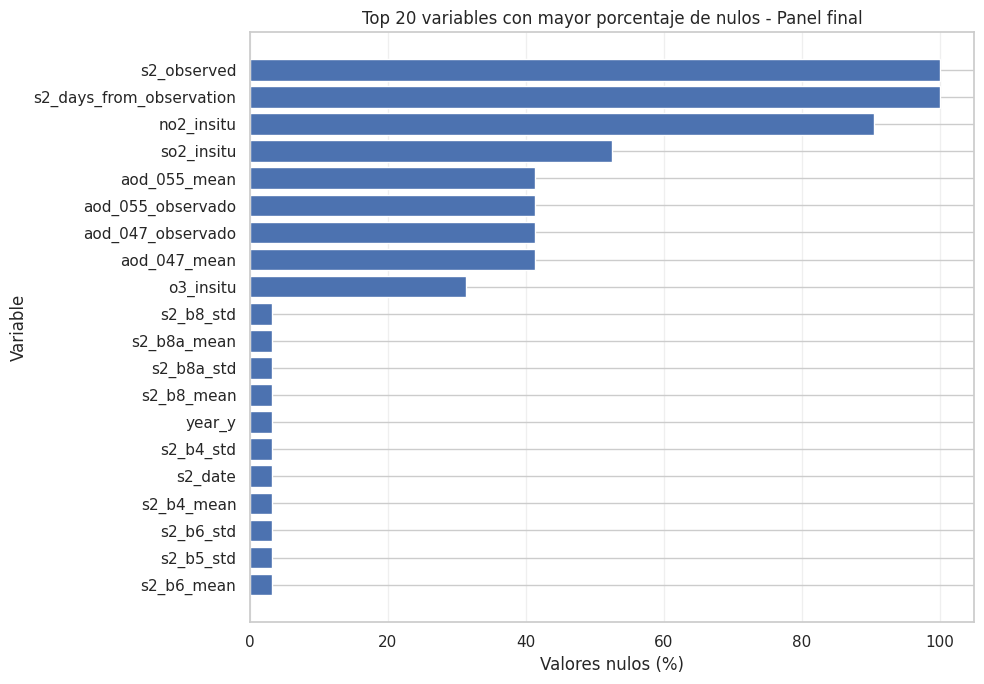

,mes,n_registros
0,2020-01,3309
1,2020-02,2718
2,2020-03,2901
3,2020-04,3454
4,2020-05,3349


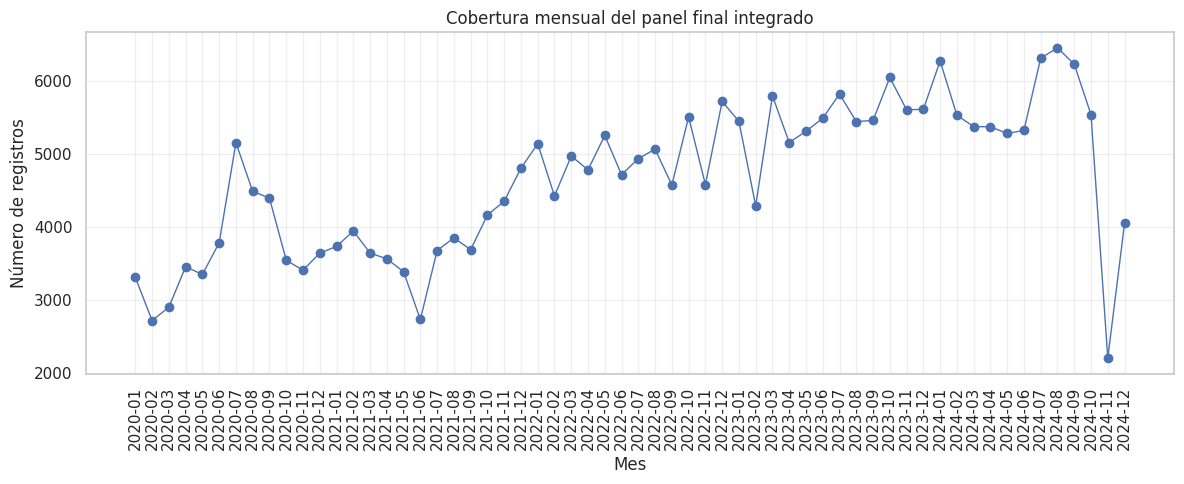

,estacion,n_registros
7,Transitoria - Navarro,17270
3,ERA - Obrero,26535
5,Flora,28541
0,Base Aerea,29936
1,Canaveralejo,32923
2,Compartir,35056
8,Univalle,35097
6,Pance,36340
4,Ermita,36920


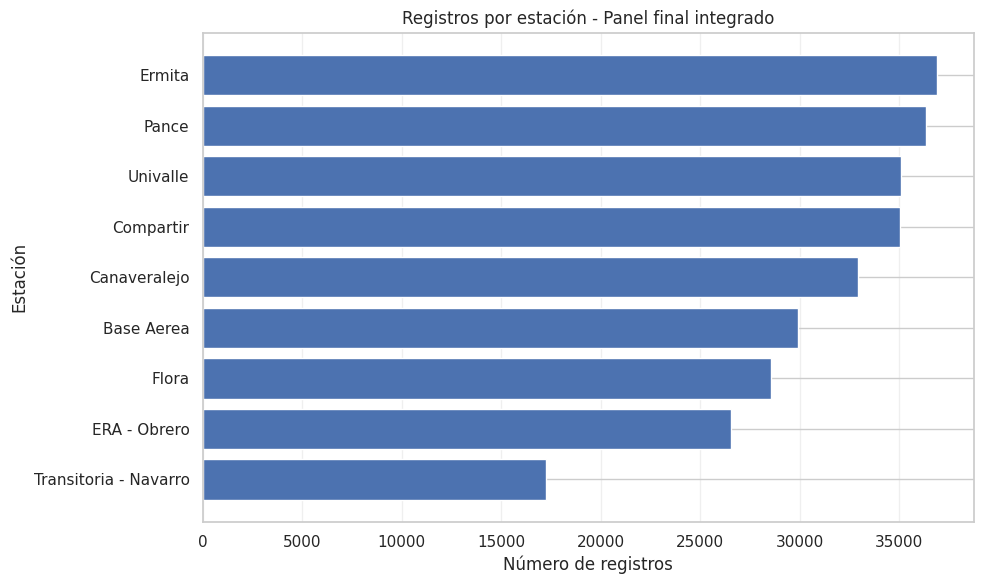

In [38]:
# ============================================================
# CELDA 10.5 — Visualizaciones de calidad del panel final
# ============================================================

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Top 20 variables con más nulos
# ------------------------------------------------------------

plot_df = df_calidad_panel.head(20).sort_values("porcentaje_nulos", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(plot_df["variable"], plot_df["porcentaje_nulos"])

ax.set_title("Top 20 variables con mayor porcentaje de nulos - Panel final")
ax.set_xlabel("Valores nulos (%)")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "10_panel_final_top20_nulos.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 2. Cobertura temporal mensual
# ------------------------------------------------------------

if col_fecha_panel is not None:
    panel_mensual = (
        df_panel
        .groupby("mes")
        .agg(n_registros=(col_fecha_panel, "size"))
        .reset_index()
    )

    display(panel_mensual.head())

    panel_mensual.to_csv(
        TAB_DIR / "10_panel_final_cobertura_mensual.csv",
        index=False
    )

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(
        panel_mensual["mes"],
        panel_mensual["n_registros"],
        marker="o",
        linewidth=1
    )

    ax.set_title("Cobertura mensual del panel final integrado")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Número de registros")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "10_panel_final_cobertura_mensual.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


# ------------------------------------------------------------
# 3. Registros por estación
# ------------------------------------------------------------

if col_estacion_panel is not None:
    panel_por_estacion = (
        df_panel
        .groupby(col_estacion_panel)
        .agg(n_registros=(col_estacion_panel, "size"))
        .reset_index()
        .sort_values("n_registros", ascending=True)
    )

    display(panel_por_estacion)

    panel_por_estacion.to_csv(
        TAB_DIR / "10_panel_final_registros_por_estacion.csv",
        index=False
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(panel_por_estacion[col_estacion_panel], panel_por_estacion["n_registros"])

    ax.set_title("Registros por estación - Panel final integrado")
    ax.set_xlabel("Número de registros")
    ax.set_ylabel("Estación")
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "10_panel_final_registros_por_estacion.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

<!-- interpretacion-s1:panel-final -->
**Interpretacion.** El panel final une las fuentes por estacion y hora. La version `model_safe` conserva covariables utiles, pero elimina columnas directas de contaminantes Sentinel-5P para reducir riesgo de fuga de informacion en los modelos.

<!-- interpretacion-s1:visualizaciones-panel -->
**Interpretacion.** Las graficas muestran cobertura, nulos, patrones horarios y mensuales de los contaminantes. Sirven para revisar si el panel tiene estructura temporal coherente antes de usarlo en las siguientes situaciones.

## 11. Relaciones Exploratorias Multifuente

### 11.1 Relaciones exploratorias entre contaminantes y covariables

Después de auditar las fuentes y construir el panel integrado, se realiza una exploración inicial de relaciones entre los contaminantes medidos en tierra y las principales covariables meteorológicas, satelitales y ópticas.

El objetivo no es establecer causalidad ni entrenar modelos predictivos en esta etapa, sino verificar si el panel consolidado permite analizar asociaciones ambientales relevantes. Para evitar fuga de información, se excluyen columnas satelitales directas de Sentinel-5P para NO₂, SO₂ y O₃, y se utilizan únicamente variables model-safe presentes en el panel final.

In [39]:
# ============================================================
# CELDA 11.1 — Relaciones exploratorias multifuente
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Variables objetivo terrestres
# ------------------------------------------------------------

targets_insitu = [
    "no2_insitu",
    "so2_insitu",
    "o3_insitu"
]

targets_insitu = [c for c in targets_insitu if c in df_panel.columns]

# ------------------------------------------------------------
# 2. Covariables model-safe para exploración
# ------------------------------------------------------------

covariables_exploratorias = [
    # ERA5-Land
    "temperature_2m_c",
    "dewpoint_2m_c",
    "relative_humidity_pct",
    "wind_speed_10m",
    "wind_direction_10m_deg",
    "surface_pressure_hpa",
    "total_precipitation_mm_hourly",
    "surface_solar_radiation_downwards_j_m2",

    # MODIS/MAIAC
    "aod_047_interp",
    "aod_055_interp",
    "aod_047_observado",
    "aod_055_observado",

    # Sentinel-5P model-safe
    "s5p_tile_distance_km",
    "s5p_qa_no2",
    "s5p_qa_so2",
    "s5p_qa_o3",

    # Sentinel-2
    "s2_cloud_pct",
    "s2_valid_pixel_pct",
    "s2_ndvi",
    "s2_bsi",
    "s2_ndbi",
    "s2_urban_index",
    "s2_vegetation_fraction",
]

covariables_exploratorias = [
    c for c in covariables_exploratorias
    if c in df_panel.columns
]

cols_corr = targets_insitu + covariables_exploratorias

print("Targets in situ:", targets_insitu)
print("Covariables exploratorias:", covariables_exploratorias)
print("Total variables para correlación:", len(cols_corr))

# ------------------------------------------------------------
# 3. Matriz de correlación
# ------------------------------------------------------------

df_corr_base = df_panel[cols_corr].copy()

for col in df_corr_base.columns:
    df_corr_base[col] = pd.to_numeric(df_corr_base[col], errors="coerce")

corr_matrix = df_corr_base.corr(method="pearson", min_periods=30)

display(corr_matrix)

corr_matrix.to_csv(
    TAB_DIR / "11_correlacion_multifuente_panel.csv"
)

# ------------------------------------------------------------
# 3B. Excluir variables constantes para evitar correlaciones NaN
# ------------------------------------------------------------

n_unicos_corr = df_corr_base.nunique(dropna=True)

cols_constantes_corr = n_unicos_corr[n_unicos_corr <= 1].index.tolist()

print("Variables constantes excluidas de la correlación:")
print(cols_constantes_corr)

df_vars_constantes_corr = pd.DataFrame({
    "variable": cols_constantes_corr,
    "n_unicos": [n_unicos_corr[c] for c in cols_constantes_corr]
})

display(df_vars_constantes_corr)

df_vars_constantes_corr.to_csv(
    TAB_DIR / "11_variables_constantes_excluidas_correlacion.csv",
    index=False
)

df_corr_base = df_corr_base.drop(columns=cols_constantes_corr)

# Actualizar listas para visualizaciones posteriores
targets_insitu = [c for c in targets_insitu if c in df_corr_base.columns]
covariables_exploratorias = [c for c in covariables_exploratorias if c in df_corr_base.columns]

# ------------------------------------------------------------
# 4. Correlaciones ordenadas target vs covariables
# ------------------------------------------------------------

relaciones_target_covariables = []

for target in targets_insitu:
    for cov in covariables_exploratorias:
        tmp = df_corr_base[[target, cov]].dropna()

        if len(tmp) >= 30:
            corr = tmp[target].corr(tmp[cov])
        else:
            corr = np.nan

        relaciones_target_covariables.append({
            "target": target,
            "covariable": cov,
            "n_pares_validos": len(tmp),
            "correlacion_pearson": corr,
            "abs_correlacion": abs(corr) if pd.notna(corr) else np.nan
        })

df_relaciones_target_covariables = (
    pd.DataFrame(relaciones_target_covariables)
    .sort_values(["target", "abs_correlacion"], ascending=[True, False])
)

display(df_relaciones_target_covariables)

df_relaciones_target_covariables.to_csv(
    TAB_DIR / "11_relaciones_target_covariables.csv",
    index=False
)

# ------------------------------------------------------------
# 5. Tabla compacta: top relaciones por contaminante
# ------------------------------------------------------------

top_relaciones_por_target = (
    df_relaciones_target_covariables
    .dropna(subset=["correlacion_pearson"])
    .groupby("target", group_keys=False)
    .head(8)
    .copy()
)

top_relaciones_por_target["correlacion_pearson"] = top_relaciones_por_target["correlacion_pearson"].round(4)
top_relaciones_por_target["abs_correlacion"] = top_relaciones_por_target["abs_correlacion"].round(4)

display(top_relaciones_por_target)

top_relaciones_por_target.to_csv(
    TAB_DIR / "11_top_relaciones_por_contaminante.csv",
    index=False
)

Targets in situ: ['no2_insitu', 'so2_insitu', 'o3_insitu']
Covariables exploratorias: ['temperature_2m_c', 'dewpoint_2m_c', 'relative_humidity_pct', 'wind_speed_10m', 'wind_direction_10m_deg', 'surface_pressure_hpa', 'total_precipitation_mm_hourly', 'surface_solar_radiation_downwards_j_m2', 'aod_047_interp', 'aod_055_interp', 'aod_047_observado', 'aod_055_observado', 's5p_tile_distance_km', 's5p_qa_no2', 's5p_qa_so2', 's5p_qa_o3', 's2_cloud_pct', 's2_valid_pixel_pct', 's2_ndvi', 's2_bsi', 's2_ndbi', 's2_urban_index', 's2_vegetation_fraction']
Total variables para correlación: 26


,no2_insitu,so2_insitu,o3_insitu,temperature_2m_c,dewpoint_2m_c,relative_humidity_pct,wind_speed_10m,wind_direction_10m_deg,surface_pressure_hpa,total_precipitation_mm_hourly,surface_solar_radiation_downwards_j_m2,aod_047_interp,aod_055_interp,aod_047_observado,aod_055_observado,s5p_tile_distance_km,s5p_qa_no2,s5p_qa_so2,s5p_qa_o3,s2_cloud_pct,s2_valid_pixel_pct,s2_ndvi,s2_bsi,s2_ndbi,s2_urban_index,s2_vegetation_fraction
no2_insitu,1.0000,NaN,-0.2038,0.1439,0.0978,-0.1347,0.1609,-0.1519,-0.3438,0.0198,0.3831,0.0010,0.0007,0.0058,0.0056,NaN,NaN,NaN,NaN,0.0411,0.0098,-0.0285,0.0312,0.0342,0.0333,-0.0425
so2_insitu,NaN,1.0000,0.1112,-0.0632,-0.0984,0.0180,0.0093,0.0571,-0.1025,-0.0046,-0.0490,0.0069,0.0068,-0.0006,-0.0007,0.0114,NaN,NaN,NaN,-0.0103,0.0096,0.0013,0.0269,0.0326,0.0303,0.0091
o3_insitu,-0.2038,0.1112,1.0000,0.1293,-0.0439,-0.2044,0.0111,0.0379,0.1039,-0.0623,-0.1197,-0.0027,-0.0028,-0.0055,-0.0055,0.0646,NaN,NaN,NaN,-0.0219,0.0038,0.0678,-0.0773,-0.0829,-0.0809,0.0592
temperature_2m_c,0.1439,-0.0632,0.1293,1.0000,0.6930,-0.8750,0.4472,-0.3261,-0.1527,-0.1042,0.6366,-0.0327,-0.0328,-0.0249,-0.0250,-0.0239,NaN,NaN,NaN,-0.1005,0.0129,-0.0032,0.0516,0.0407,0.0458,-0.0099
dewpoint_2m_c,0.0978,-0.0984,-0.0439,0.6930,1.0000,-0.2611,0.2548,-0.2628,-0.0365,0.1078,0.5000,0.0995,0.0994,0.1188,0.1187,-0.0477,NaN,NaN,NaN,-0.0572,0.0086,-0.0123,0.0303,0.0303,0.0305,-0.0136
relative_humidity_pct,-0.1347,0.0180,-0.2044,-0.8750,-0.2611,1.0000,-0.4153,0.2546,0.1844,0.2190,-0.5189,0.1063,0.1064,0.1042,0.1043,-0.0005,NaN,NaN,NaN,0.0900,-0.0112,-0.0034,-0.0464,-0.0324,-0.0387,0.0044
wind_speed_10m,0.1609,0.0093,0.0111,0.4472,0.2548,-0.4153,1.0000,-0.1236,-0.2011,-0.0549,0.4168,-0.0748,-0.0749,-0.0804,-0.0804,-0.0087,NaN,NaN,NaN,-0.1018,0.0094,-0.0059,0.0662,0.0500,0.0574,-0.0152
wind_direction_10m_deg,-0.1519,0.0571,0.0379,-0.3261,-0.2628,0.2546,-0.1236,1.0000,0.0853,0.0142,-0.4241,-0.0417,-0.0418,-0.0407,-0.0408,-0.0057,NaN,NaN,NaN,-0.0455,0.0060,-0.0088,0.0287,0.0225,0.0253,-0.0125
surface_pressure_hpa,-0.3438,-0.1025,0.1039,-0.1527,-0.0365,0.1844,-0.2011,0.0853,1.0000,0.0357,-0.3855,-0.0887,-0.0890,-0.0693,-0.0695,-0.0408,NaN,NaN,NaN,-0.0352,-0.0012,-0.0191,0.0643,0.0590,0.0617,-0.0235
total_precipitation_mm_hourly,0.0198,-0.0046,-0.0623,-0.1042,0.1078,0.2190,-0.0549,0.0142,0.0357,1.0000,-0.0445,0.0630,0.0631,0.0589,0.0590,0.0018,NaN,NaN,NaN,0.0661,-0.0014,-0.0121,-0.0244,-0.0141,-0.0187,-0.0053


Variables constantes excluidas de la correlación:
['s5p_qa_no2', 's5p_qa_so2', 's5p_qa_o3']


,variable,n_unicos
0,s5p_qa_no2,1
1,s5p_qa_so2,1
2,s5p_qa_o3,1


,target,covariable,n_pares_validos,correlacion_pearson,abs_correlacion
7,no2_insitu,surface_solar_radiation_downwards_j_m2,26259,0.3831,0.3831
5,no2_insitu,surface_pressure_hpa,26259,-0.3438,0.3438
3,no2_insitu,wind_speed_10m,26259,0.1609,0.1609
4,no2_insitu,wind_direction_10m_deg,26259,-0.1519,0.1519
0,no2_insitu,temperature_2m_c,26259,0.1439,0.1439
2,no2_insitu,relative_humidity_pct,26259,-0.1347,0.1347
1,no2_insitu,dewpoint_2m_c,26259,0.0978,0.0978
19,no2_insitu,s2_vegetation_fraction,25195,-0.0425,0.0425
13,no2_insitu,s2_cloud_pct,25195,0.0411,0.0411
17,no2_insitu,s2_ndbi,25195,0.0342,0.0342


,target,covariable,n_pares_validos,correlacion_pearson,abs_correlacion
7,no2_insitu,surface_solar_radiation_downwards_j_m2,26259,0.3831,0.3831
5,no2_insitu,surface_pressure_hpa,26259,-0.3438,0.3438
3,no2_insitu,wind_speed_10m,26259,0.1609,0.1609
4,no2_insitu,wind_direction_10m_deg,26259,-0.1519,0.1519
0,no2_insitu,temperature_2m_c,26259,0.1439,0.1439
2,no2_insitu,relative_humidity_pct,26259,-0.1347,0.1347
1,no2_insitu,dewpoint_2m_c,26259,0.0978,0.0978
19,no2_insitu,s2_vegetation_fraction,25195,-0.0425,0.0425
42,o3_insitu,relative_humidity_pct,191257,-0.2044,0.2044
40,o3_insitu,temperature_2m_c,191257,0.1293,0.1293


### 11.2 Visualizaciones exploratorias multifuente

Se generan visualizaciones compactas para resumir las relaciones exploratorias entre contaminantes terrestres y covariables ambientales. Estas gráficas funcionan como diagnóstico inicial del panel integrado y no deben interpretarse como evidencia causal.

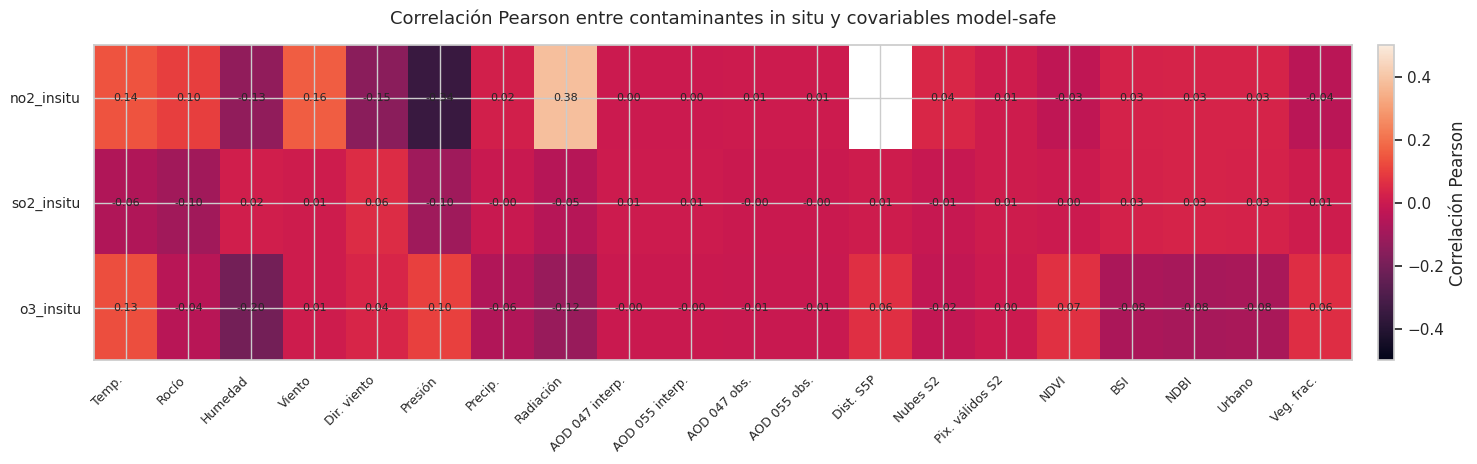

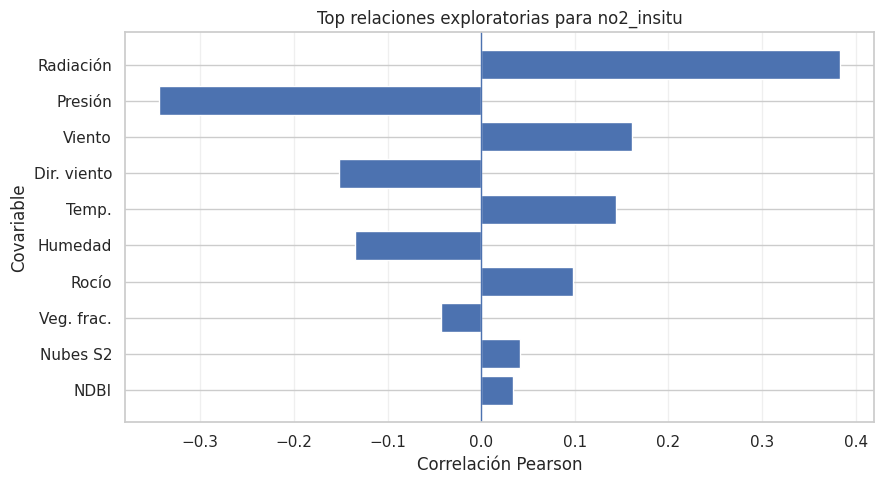

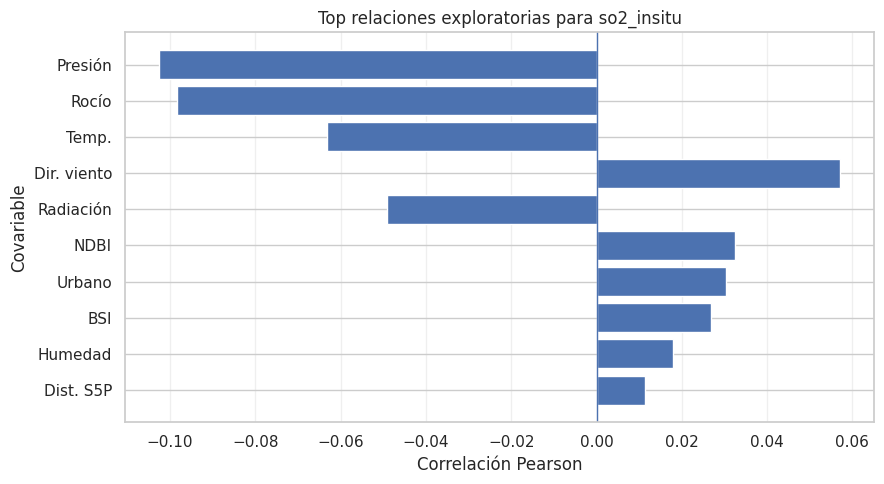

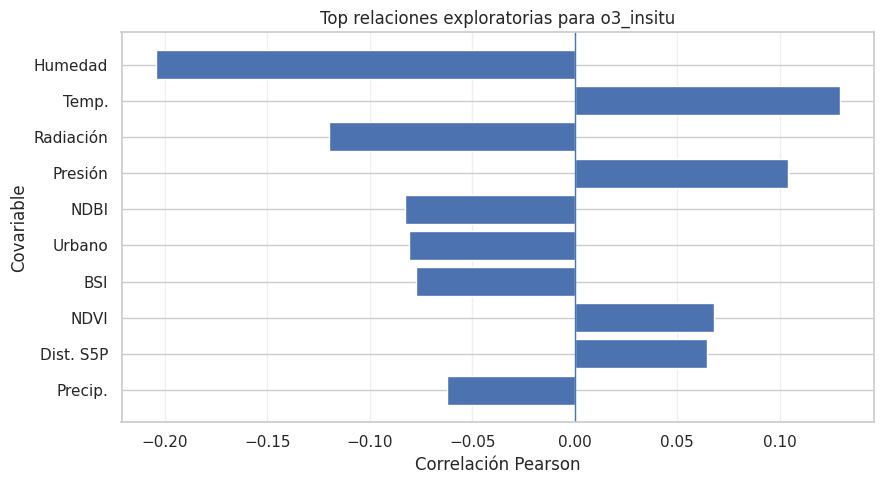

In [40]:
# ============================================================
# CELDA 11.2 — Visualizaciones exploratorias multifuente corregida
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Heatmap legible de correlaciones target vs covariables
# ------------------------------------------------------------

if len(targets_insitu) > 0 and len(covariables_exploratorias) > 0:
    corr_target_cov = corr_matrix.loc[
        targets_insitu,
        covariables_exploratorias
    ].copy()

    # Renombrar columnas largas para que la figura sea legible
    nombres_cortos = {
        "temperature_2m_c": "Temp.",
        "dewpoint_2m_c": "Rocío",
        "relative_humidity_pct": "Humedad",
        "wind_speed_10m": "Viento",
        "wind_direction_10m_deg": "Dir. viento",
        "surface_pressure_hpa": "Presión",
        "total_precipitation_mm_hourly": "Precip.",
        "surface_solar_radiation_downwards_j_m2": "Radiación",
        "aod_047_interp": "AOD 047 interp.",
        "aod_055_interp": "AOD 055 interp.",
        "aod_047_observado": "AOD 047 obs.",
        "aod_055_observado": "AOD 055 obs.",
        "s5p_tile_distance_km": "Dist. S5P",
        "s2_cloud_pct": "Nubes S2",
        "s2_valid_pixel_pct": "Pix. válidos S2",
        "s2_ndvi": "NDVI",
        "s2_bsi": "BSI",
        "s2_ndbi": "NDBI",
        "s2_urban_index": "Urbano",
        "s2_vegetation_fraction": "Veg. frac."
    }

    corr_plot = corr_target_cov.rename(columns=nombres_cortos)

    fig, ax = plt.subplots(
        figsize=(max(12, 0.75 * len(corr_plot.columns)), 4.8)
    )

    im = ax.imshow(
        corr_plot.values,
        aspect="auto",
        vmin=-0.5,
        vmax=0.5
    )

    ax.set_xticks(np.arange(len(corr_plot.columns)))
    ax.set_xticklabels(
        corr_plot.columns,
        rotation=45,
        ha="right",
        fontsize=9
    )

    ax.set_yticks(np.arange(len(corr_plot.index)))
    ax.set_yticklabels(
        corr_plot.index,
        fontsize=10
    )

    ax.set_title(
        "Correlación Pearson entre contaminantes in situ y covariables model-safe",
        fontsize=13,
        pad=15
    )

    # Anotar valores dentro de cada celda
    for i in range(corr_plot.shape[0]):
        for j in range(corr_plot.shape[1]):
            value = corr_plot.iloc[i, j]
            if pd.notna(value):
                ax.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Correlación Pearson")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / "11_heatmap_correlacion_target_covariables_legible.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 2. Barras de top correlaciones absolutas por target
# ------------------------------------------------------------

for target in targets_insitu:
    plot_df = (
        df_relaciones_target_covariables
        .loc[df_relaciones_target_covariables["target"] == target]
        .dropna(subset=["correlacion_pearson"])
        .sort_values("abs_correlacion", ascending=True)
        .tail(10)
    )

    if len(plot_df) == 0:
        continue

    plot_df = plot_df.copy()
    plot_df["covariable_corta"] = plot_df["covariable"].replace(nombres_cortos)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.barh(
        plot_df["covariable_corta"],
        plot_df["correlacion_pearson"]
    )

    ax.set_title(f"Top relaciones exploratorias para {target}")
    ax.set_xlabel("Correlación Pearson")
    ax.set_ylabel("Covariable")
    ax.axvline(0, linewidth=1)
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"11_top_correlaciones_{target}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

<!-- interpretacion-s1:relaciones -->
**Interpretacion.** Las correlaciones muestran asociaciones iniciales entre contaminantes y covariables ambientales. No prueban causalidad, pero ayudan a identificar variables que podrian aportar señal para los modelos posteriores.

## 12. Cumplimiento De Rúbrica

Esta sección consolida la evidencia computacional generada en el EDA y en la carpeta de entrega para verificar los entregables de Situación 1. La tabla no reemplaza el análisis anterior; funciona como índice de trazabilidad entre la rúbrica y los artefactos producidos.

In [41]:
# ============================================================
# 12.1 Tabla de cumplimiento de rubrica Situacion 1
# ============================================================

def existe_rel(path):
    path = Path(path)
    return path.exists(), str(path.relative_to(ROOT)) if path.exists() and path.is_relative_to(ROOT) else str(path)

evidencias_rubrica = []

def add_evidencia(entregable, estado, evidencia, ruta, nota):
    existe, ruta_txt = existe_rel(ruta)
    evidencias_rubrica.append({
        'entregable_rubrica': entregable,
        'estado': estado,
        'evidencia': evidencia,
        'ruta': ruta_txt,
        'archivo_existe': existe,
        'nota': nota,
    })

add_evidencia(
    'Panel analitico en formato optimizado',
    'Cumple',
    'Panel final Parquet model_safe y caches Zarr Sentinel-2',
    RUTAS['panel_final_model_safe'],
    'El panel final es derivado y comprimido; el Zarr conserva el componente satelital optimizado.'
)

add_evidencia(
    'Volumen de datos >= 50 GB',
    'Cumple',
    'Manifest Sentinel-2 raw: 198 escenas, 93.1 GB decimales / 86.7 GiB',
    TAB_DIR / 'resumen_sentinel2_raw_93gb.csv',
    'El umbral se verifica sobre datos raw/cache de ingesta, no sobre el panel final comprimido.'
)

add_evidencia(
    'Manifest JSON con hashes MD5',
    'Cumple',
    'Manifests principales copiados a evidencias/manifests',
    OUT / 'evidencias/manifests/manifest_panel_geovision_cali_2020_2024.json',
    'Incluye manifest del panel y manifests por fuente; revisar cada JSON para hashes y dimensiones.'
)

add_evidencia(
    'Notebook EDA con minimo 8 visualizaciones',
    'Cumple',
    'Figuras generadas por fuente y panel final',
    FIG_DIR,
    'El notebook guarda visualizaciones para DAGMA, ERA5, MODIS, Sentinel-5P, Sentinel-2, panel final y correlaciones.'
)

add_evidencia(
    'Cobertura espacial y temporal',
    'Cumple',
    'Tablas y figuras de cobertura por fuente',
    TAB_DIR / 'resumen_cobertura_espacial_fuentes.csv',
    'Incluye estaciones DAGMA/SISAIRE, Sentinel-5P y fuentes con coordenadas disponibles.'
)

add_evidencia(
    'Calidad, nulos y disponibilidad',
    'Cumple',
    'Tablas de nulos/calidad por fuente',
    OUT / 'evidencias/tablas_fuente',
    'Se complementa con tablas exportadas en la carpeta tablas/.'
)

add_evidencia(
    'Arquitectura cloud',
    'Documentado fuera del EDA',
    'Markdown e imagen de arquitectura RunPod + S3-compatible',
    OUT / 'docs_latex/01_arquitectura_cloud_runpod_s3.md',
    'Se mantiene como soporte para informe LaTeX, no como análisis estadístico del EDA.'
)

add_evidencia(
    'Reporte de costos cloud',
    'Documentado fuera del EDA',
    'Costos RunPod en documento Markdown de arquitectura',
    OUT / 'docs_latex/01_arquitectura_cloud_runpod_s3.md',
    'Incluye volumen persistente 180 GB y costo aproximado del pod GPU.'
)

add_evidencia(
    'ETL distribuido o paralelizado',
    'Documentado con limitacion',
    'Logs de procesamiento por años/meses/tiles y descarga Sentinel-2',
    OUT / 'evidencias/logs/sentinel2_12band_raw_download_full.log',
    'No se conserva evidencia directa de Dask/Spark; se documenta procesamiento por fecha/tile/banda y la limitacion metodologica.'
)

df_cumplimiento_rubrica_s1 = pd.DataFrame(evidencias_rubrica)
df_cumplimiento_rubrica_s1.to_csv(TAB_DIR / '12_cumplimiento_rubrica_situacion1.csv', index=False)
display(df_cumplimiento_rubrica_s1)


,entregable_rubrica,estado,evidencia,ruta,archivo_existe,nota
0,Panel analitico en formato optimizado,Cumple,Panel final Parquet model_safe y caches Zarr S...,panel_tabular/panel_geovision_cali_station_hou...,True,El panel final es derivado y comprimido; el Za...
1,Volumen de datos >= 50 GB,Cumple,"Manifest Sentinel-2 raw: 198 escenas, 93.1 GB ...",Entrega_Final/Situacion1/tablas/resumen_sentin...,True,El umbral se verifica sobre datos raw/cache de...
2,Manifest JSON con hashes MD5,Cumple,Manifests principales copiados a evidencias/ma...,Entrega_Final/Situacion1/evidencias/manifests/...,True,Incluye manifest del panel y manifests por fue...
3,Notebook EDA con minimo 8 visualizaciones,Cumple,Figuras generadas por fuente y panel final,Entrega_Final/Situacion1/figuras,True,"El notebook guarda visualizaciones para DAGMA,..."
4,Cobertura espacial y temporal,Cumple,Tablas y figuras de cobertura por fuente,Entrega_Final/Situacion1/tablas/resumen_cobert...,True,"Incluye estaciones DAGMA/SISAIRE, Sentinel-5P ..."
5,"Calidad, nulos y disponibilidad",Cumple,Tablas de nulos/calidad por fuente,Entrega_Final/Situacion1/evidencias/tablas_fuente,True,Se complementa con tablas exportadas en la car...
6,Arquitectura cloud,Documentado fuera del EDA,Markdown e imagen de arquitectura RunPod + S3-...,/workspace/geovision-cali-hf/Entrega_Final/Sit...,False,"Se mantiene como soporte para informe LaTeX, n..."
7,Reporte de costos cloud,Documentado fuera del EDA,Costos RunPod en documento Markdown de arquite...,/workspace/geovision-cali-hf/Entrega_Final/Sit...,False,Incluye volumen persistente 180 GB y costo apr...
8,ETL distribuido o paralelizado,Documentado con limitacion,Logs de procesamiento por años/meses/tiles y d...,Entrega_Final/Situacion1/evidencias/logs/senti...,True,No se conserva evidencia directa de Dask/Spark...


<!-- interpretacion-s1:rubrica -->
**Interpretacion.** La tabla reune las evidencias principales de Situacion 1: volumen mayor a 50 GB, manifests con trazabilidad, EDA, arquitectura cloud, costos y panel `model_safe`. Tambien deja claro que archivo respalda cada punto de la entrega.